In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 통계분석용
import pymannkendall as mk # 맨-켄달 검정
from scipy import stats # 리니러리그레숑

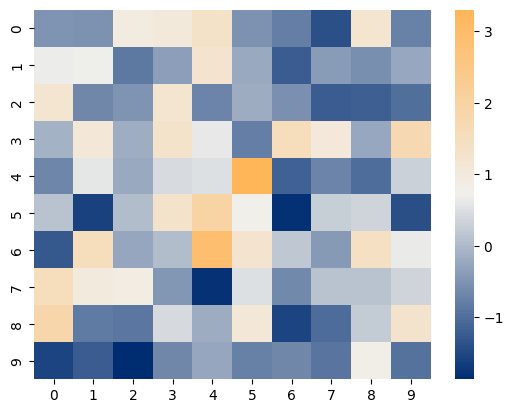

In [2]:
plt.rcParams.update(plt.rcParamsDefault)

# 커스텀 팔레트
custom_cmap = sns.blend_palette(['#002D72', '#f1f0ec','#ffb659'], as_cmap=True) # Light(default)
custom_cmap_dark = sns.blend_palette(['#002D72', '#807266','#ffb659'], as_cmap=True) # dark (구성비용, 가운데만 다름)

# 컬러맵 프리뷰용
data = np.random.randn(10, 10)
sns.heatmap(data, cmap=custom_cmap)
plt.show()

# 그래프 기본 테마 설정
sns.set_theme(style="whitegrid", font_scale=1) # 블루톤

# 그리드 색상 조절
plt.rcParams.update({
    "grid.color": ".8",          # 그리드 색상
    "grid.linestyle": "--",       # 그리드 점선 스타일
    "grid.linewidth": 0.8,        # 그리드 두께
    "axes.grid": True,            # 그리드 항상 켜기
    "axes.edgecolor": ".8",       # 축 테두리 색상
})

# 막대그래프 관련 설정
plt.rcParams.update({
    "lines.linewidth": 2,
    "lines.marker": "D",          # 전역 마커 설정
    "lines.markersize": 7        # 마커 크기
})

# 그래프를 그리기 위한 기본 설정
plt.rcParams['font.family'] = 'Nanumsquare_ac' # 나눔스퀘어
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 16, 9
plt.rcParams['axes.titlesize'] = 20 # 제목 폰트 사이즈
plt.rcParams['axes.labelsize'] = 18 # 라벨 폰트 사이즈
plt.rcParams['font.size'] = 18 # 기본 폰트사이즈
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'cm'

In [3]:
# 알아서 째라...
def get_palette(n):
    return [custom_cmap(i / (n - 1)) for i in range(n)]

# 일단 불러오십쇼.
- 비용칼럼이 두개인데 하나는 단위가 원이고 하나는 만원입니다. 필요에 따라 갖다쓰십셔.
    - 비용: 원
    - 비용(만원): 만원

In [4]:
# 산업 규모별 임금, 근로시간
payment_time_date = pd.read_csv('data/payment_time_date.csv')
payment_time_money = pd.read_csv('data/payment_time_money.csv')
payment_time_total_date = pd.read_csv('data/payment_time_total_date.csv') # 전업종
payment_time_total_money = pd.read_csv('data/payment_time_total_money.csv') # 전업종

# 제조업, 10개년
payment_time_jejo = pd.read_csv('data/payment_time_all_date.csv')
payment_money_jejo = pd.read_csv('data/payment_time_all_money.csv')

In [5]:
payment_date = payment_time_total_date.query('산업분류 != "전체"')
payment_money = payment_time_total_money.query('산업분류 != "전체"')

In [6]:
payment_money['지표'].value_counts()

지표
전체임금총액      85
상용임금총액      85
상용정액급여      85
상용초과급여      85
상용특별급여      85
임시일용임금총액    85
Name: count, dtype: int64

## 전체임금총액

In [7]:
total_payment = payment_money.query('지표 == "전체임금총액"')
total_payment

,산업분류,연도,지표,비용,비용(만원)
1,광업,2020,전체임금총액,4325202.0,432.52
2,제조업,2020,전체임금총액,3990086.0,399.01
3,"전기, 가스, 증기 및 공기 조절 공급업",2020,전체임금총액,6733071.0,673.31
4,"수도, 하수 및 폐기물 처리, 원료 재생업",2020,전체임금총액,3887682.0,388.77
5,건설업,2020,전체임금총액,3032156.0,303.22
...,...,...,...,...,...
445,"사업시설 관리, 사업 지원 및 임대 서비스업",2024,전체임금총액,2786568.0,278.66
446,교육 서비스업,2024,전체임금총액,3602268.0,360.23
447,보건업 및 사회복지 서비스업,2024,전체임금총액,3218171.0,321.82
448,"예술, 스포츠 및 여가관련 서비스업",2024,전체임금총액,3110856.0,311.09


### 최근 5개년 전체 임금총액 추이

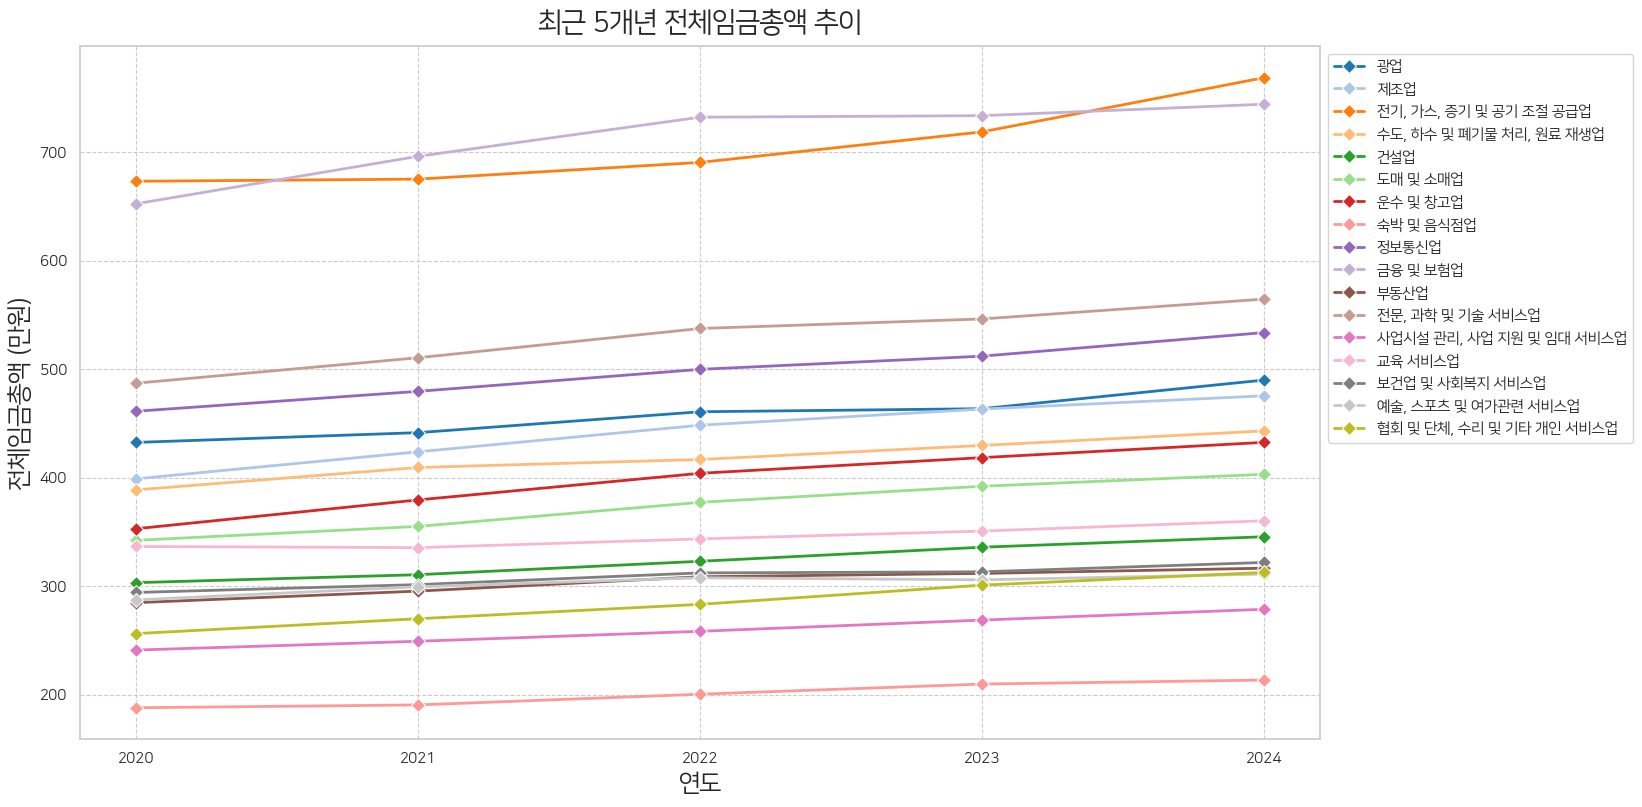

In [8]:
sns.lineplot(total_payment, x = '연도', y = '비용(만원)', hue = '산업분류', palette='tab20')
plt.title('최근 5개년 전체임금총액 추이', y = 1.01)
plt.xlabel('연도')
plt.ylabel('전체임금총액 (만원)')
plt.ticklabel_format(axis='y', style='plain')
plt.legend(bbox_to_anchor=(1, 1))
plt.xticks([2020, 2021, 2022, 2023, 2024]) # 얘는 왜 이걸 해줘야 년도로 나올까...
plt.show()

- 임금총액이 제일 높은 업종이 금융업, 그리고 전기, 가스, 증기 및 공기 조절 공급업입니다. 제조업은 저 밑에 어디 있군요. (가운데쯤 보이는 연파랑선)
- 흠... 제조업은 임금도 높지 않고, 산업재해 재해자나 사망자 수는 많고... 여러가지로 극한직업이네요. 그래서 '누군가는 해야 하는 일이지만 내 자식은 하면 안 되는' 일들 중 하나인걸까요?

In [9]:
# 근데 저게... 전체만 놓고 봐서는 모르잖아요. ...라고 생각하는 사람이 저뿐이 아니군요.
# 이거 쌩으로 그리면 참사터지니까 5개년 평균부터 내겠습니다.
total_payment_all = payment_money.groupby(['산업분류', '지표']).agg({'비용(만원)':'mean'}).unstack()

# 사실 이렇게만 해도 되거든요? 되는데 문제가 하나 있어요. 히트맵이 완전 중구난방이라 뭐가 뭔지 몰라요 우리가.
# total_payment_all.style.format("{:.3f}").background_gradient(cmap='RdYlGn', axis=1)

# 그래서 정규화를 해줄겁니다.
heatmap_norm = (total_payment_all - total_payment_all.min()) / (total_payment_all.max() - total_payment_all.min())
heatmap_norm.style.format("{:.3f}").background_gradient(cmap='RdYlGn', axis=1)

아니... 이게 다 뭐임??? 저도 모르겠으니까 지금부터 알아봅시다.
1. 상용임금총액: 고용계약 기간이 1년 이상이거나 고용 제한이 없는 상용근로자에게 지급되는 세금 공제 전 임금 (세전 얼마)
2. 상용정액급여: 고용 계약 1년 이상 또는 상용 근로자에게 고정적·규칙적으로 지급되는 기본급, 가족수당, 직책수당, 식대 등 (월급명세서에 매달 찍혀나오는 그거)
3. 상용초과급여: 1년 이상 계약한 상용근로자에게 소정근로시간을 초과하여 근무한 시간(연장, 야간, 휴일근로)에 대해 지급하는 수당
4. 상용특별급여: 상용근로자(정규직 등)에게 정기/비정기적으로 지급되는 성과급, 상여금, 임금인상 소급분 등 통상적인 정액 급여 외의 특별 보수 (명절 떡값도 여기 포함됩니다)
5. 임시일용임금총액: 1개월 미만의 기간 동안 고용되는 일용근로자 또는 1개월 이상 1년 미만의 기간 동안 고용되는 임시근로자가 해당 기간 동안 실제 근무를 통해 지급받은 임금의 총합 (쿠땡 물류센터가서 알바하고 받는 돈)
6. 전체임금총액: 사용자가 근로의 대가로 근로자에게 지급하는 일체의 금품으로, 근로기준법상 퇴직금 및 휴업수당 산정의 기초가 되는 평균임금 계산 시 사유 발생 이전 3개월간 지급된 모든 임금의 합계 ~~아 총합이 아니셔?~~

그럼 이제 저 히트맵을 좀 봅시다. 제조업이 그래도 중간에는 있는 느낌인데, 상용 정액급여도 그렇게 많지는 않아보입니다. 하지만 초과근무 수당은 전 업종을 통틀어서 1위군요. 아, 극한이다 극한.


### 최근 5개년 평균

In [10]:
total_payment_mean = total_payment.groupby(['산업분류', '지표']).agg({'비용(만원)':'mean'}).reset_index()
total_payment_mean = total_payment_mean.sort_values('비용(만원)', ascending=False)
total_payment_mean

,산업분류,지표,비용(만원)
3,금융 및 보험업,전체임금총액,711.894
12,"전기, 가스, 증기 및 공기 조절 공급업",전체임금총액,705.376
13,"전문, 과학 및 기술 서비스업",전체임금총액,529.262
14,정보통신업,전체임금총액,497.314
1,광업,전체임금총액,457.686
15,제조업,전체임금총액,442.002
8,"수도, 하수 및 폐기물 처리, 원료 재생업",전체임금총액,417.552
11,운수 및 창고업,전체임금총액,397.514
4,도매 및 소매업,전체임금총액,373.964
2,교육 서비스업,전체임금총액,345.322


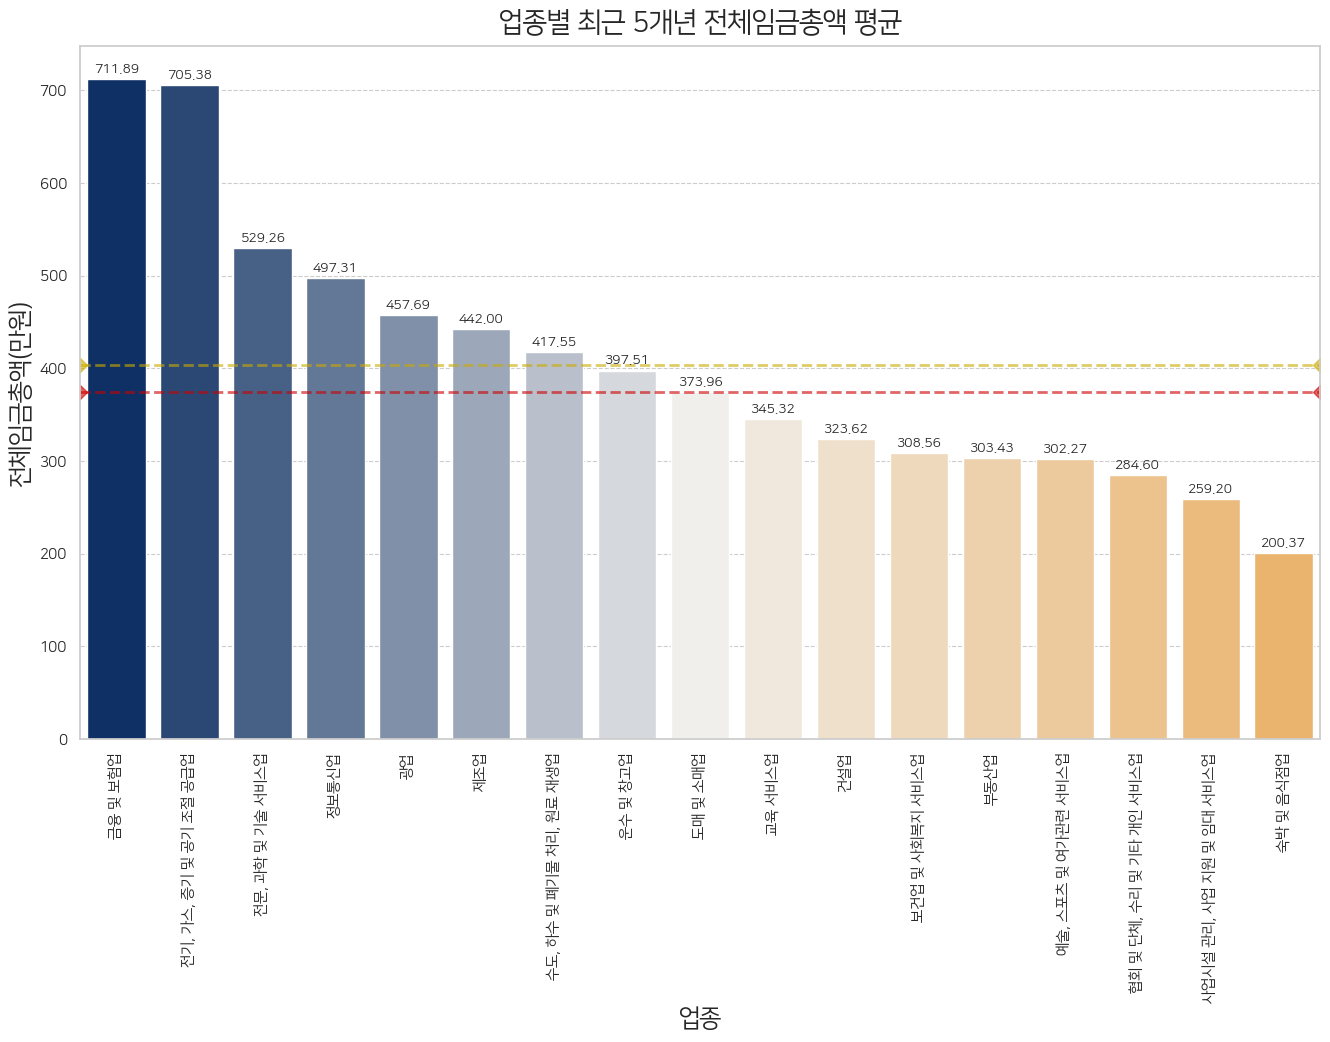

In [11]:
ax = sns.barplot(total_payment_mean, x = '산업분류', y = '비용(만원)', hue = '산업분류', palette=get_palette(total_payment_mean['산업분류'].nunique()))
for container in ax.containers:
    # fmt='%d'는 정수로 표시, label_type='edge'는 막대 끝에 표시
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.title('업종별 최근 5개년 전체임금총액 평균', y = 1.01)
plt.xlabel('업종')
plt.ylabel('전체임금총액(만원)')
plt.axhline(np.median(total_payment_mean['비용(만원)']), linestyle='dashed', color='#cc0000', alpha = 0.6) # 중앙값
plt.axhline(np.mean(total_payment_mean['비용(만원)']), linestyle='dashed', color='#ccaa00', alpha = 0.6) # 평균
plt.ticklabel_format(axis='y', style='plain')
plt.xticks(rotation=90)
plt.show()

- 제조업은 6등입니다. 일단 아까도 보셨지만 전체임금총액은 꽤 높죠?

## 상용임금총액

In [12]:
sangyong_payment = payment_money.query('지표 == "상용임금총액"')
sangyong_payment

,산업분류,연도,지표,비용,비용(만원)
19,광업,2020,상용임금총액,4405344.0,440.53
20,제조업,2020,상용임금총액,4058423.0,405.84
21,"전기, 가스, 증기 및 공기 조절 공급업",2020,상용임금총액,6824385.0,682.44
22,"수도, 하수 및 폐기물 처리, 원료 재생업",2020,상용임금총액,3988824.0,398.88
23,건설업,2020,상용임금총액,3824904.0,382.49
...,...,...,...,...,...
463,"사업시설 관리, 사업 지원 및 임대 서비스업",2024,상용임금총액,2931737.0,293.17
464,교육 서비스업,2024,상용임금총액,3775966.0,377.60
465,보건업 및 사회복지 서비스업,2024,상용임금총액,3357645.0,335.76
466,"예술, 스포츠 및 여가관련 서비스업",2024,상용임금총액,3470364.0,347.04


### 최근 5개년 상용임금총액 추이

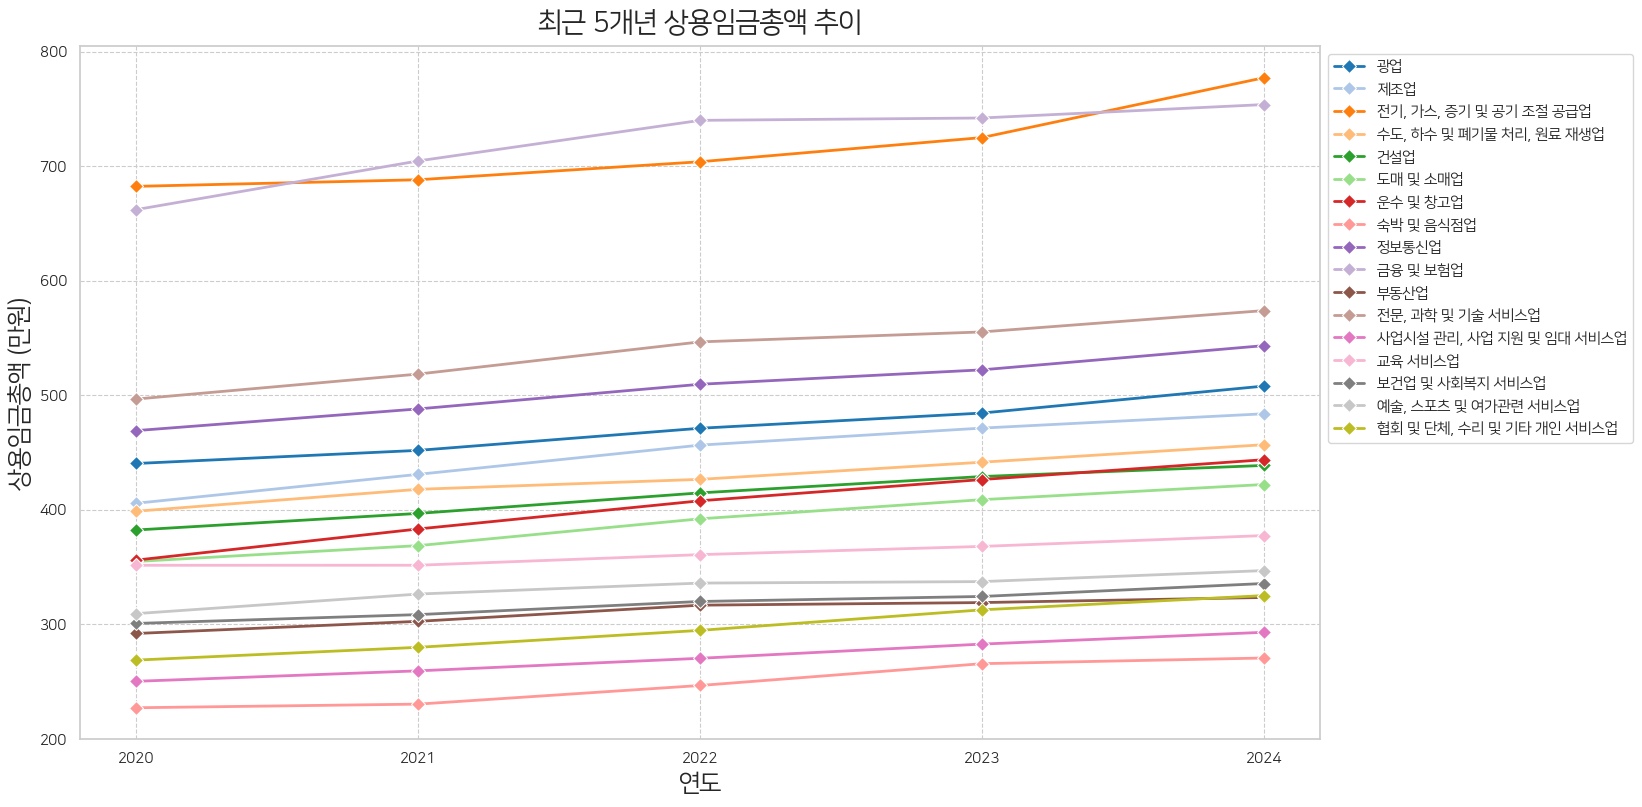

In [13]:
sns.lineplot(sangyong_payment, x = '연도', y = '비용(만원)', hue = '산업분류', palette='tab20')
plt.title('최근 5개년 상용임금총액 추이', y = 1.01)
plt.xlabel('연도')
plt.ylabel('상용임금총액 (만원)')
plt.ticklabel_format(axis='y', style='plain')
plt.legend(bbox_to_anchor=(1, 1))
plt.xticks([2020, 2021, 2022, 2023, 2024]) # 얘는 왜 이걸 해줘야 년도로 나올까...
plt.show()

### 최근 5개년 평균

In [14]:
sangyong_payment_mean = sangyong_payment.groupby(['산업분류', '지표']).agg({'비용(만원)':'mean'}).reset_index()
sangyong_payment_mean = sangyong_payment_mean.sort_values('비용(만원)', ascending=False)
sangyong_payment_mean

,산업분류,지표,비용(만원)
3,금융 및 보험업,상용임금총액,720.566
12,"전기, 가스, 증기 및 공기 조절 공급업",상용임금총액,715.362
13,"전문, 과학 및 기술 서비스업",상용임금총액,538.278
14,정보통신업,상용임금총액,506.552
1,광업,상용임금총액,471.286
15,제조업,상용임금총액,449.762
8,"수도, 하수 및 폐기물 처리, 원료 재생업",상용임금총액,428.420
0,건설업,상용임금총액,412.454
11,운수 및 창고업,상용임금총액,403.578
4,도매 및 소매업,상용임금총액,389.446


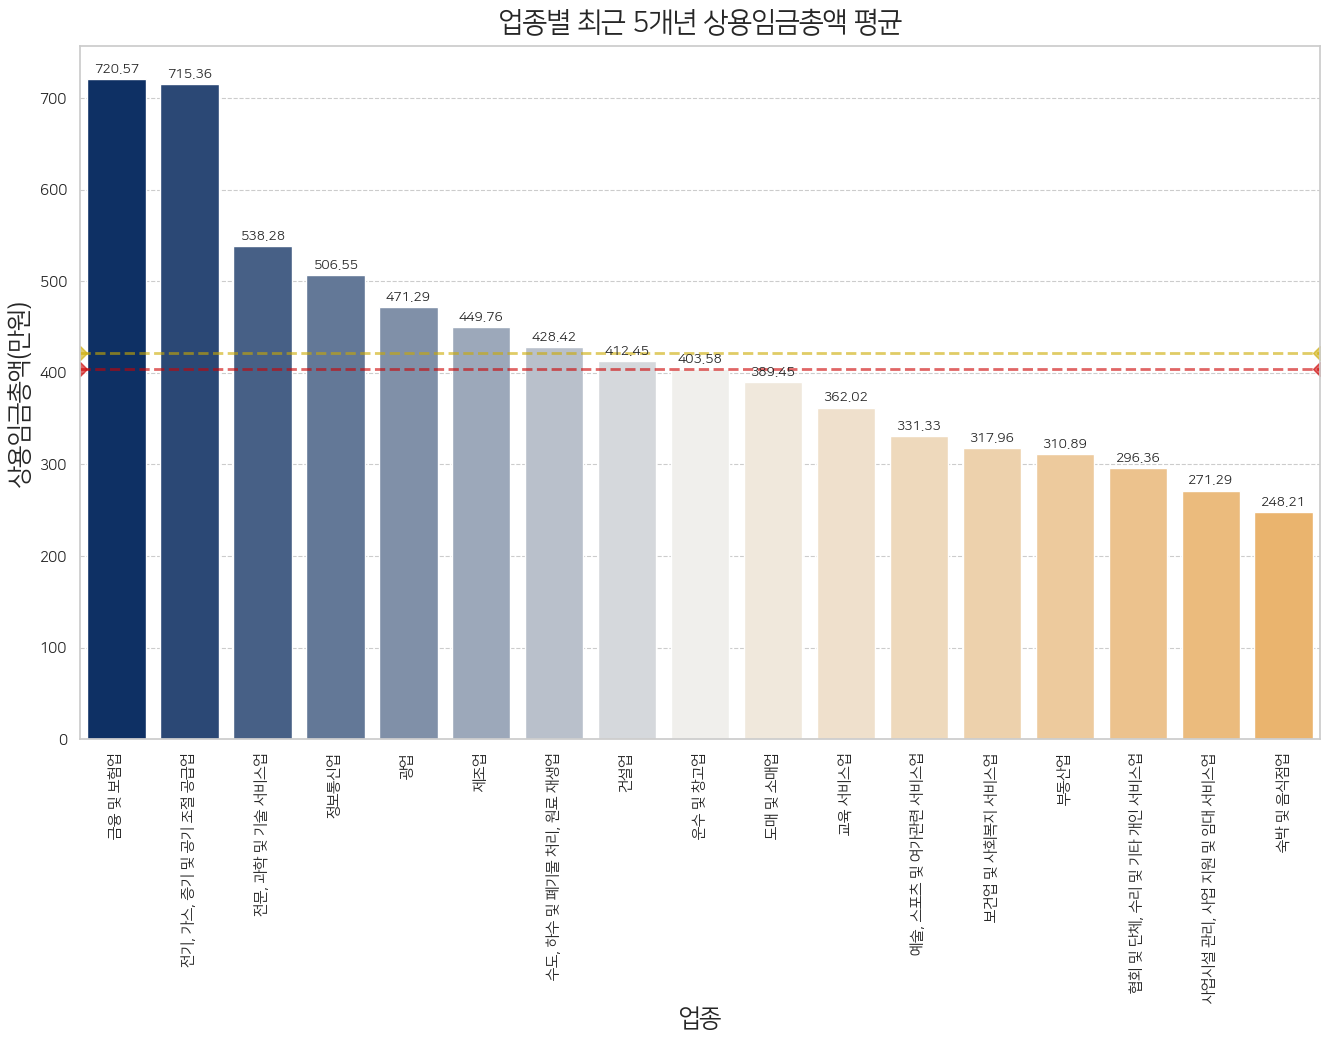

In [15]:
ax = sns.barplot(sangyong_payment_mean, x = '산업분류', y = '비용(만원)', hue = '산업분류', palette=get_palette(sangyong_payment_mean['산업분류'].nunique()))
for container in ax.containers:
    # fmt='%d'는 정수로 표시, label_type='edge'는 막대 끝에 표시
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.title('업종별 최근 5개년 상용임금총액 평균', y = 1.01)
plt.xlabel('업종')
plt.ylabel('상용임금총액(만원)')
plt.axhline(np.median(sangyong_payment_mean['비용(만원)']), linestyle='dashed', color='#cc0000', alpha = 0.6) # 중앙값
plt.axhline(np.mean(sangyong_payment_mean['비용(만원)']), linestyle='dashed', color='#ccaa00', alpha = 0.6) # 평균
plt.ticklabel_format(axis='y', style='plain')
plt.xticks(rotation=90)
plt.show()

- 상용 임금 총액도 제조업이 6위네요. 역시나 1, 2위는 바뀌지 않습니다.

## 상용정액급여

In [16]:
constant_payment = payment_money.query('지표 == "상용정액급여"')
constant_payment

,산업분류,연도,지표,비용,비용(만원)
37,광업,2020,상용정액급여,3507078.0,350.71
38,제조업,2020,상용정액급여,3090580.0,309.06
39,"전기, 가스, 증기 및 공기 조절 공급업",2020,상용정액급여,4764187.0,476.42
40,"수도, 하수 및 폐기물 처리, 원료 재생업",2020,상용정액급여,3270097.0,327.01
41,건설업,2020,상용정액급여,3408376.0,340.84
...,...,...,...,...,...
481,"사업시설 관리, 사업 지원 및 임대 서비스업",2024,상용정액급여,2602031.0,260.20
482,교육 서비스업,2024,상용정액급여,3402688.0,340.27
483,보건업 및 사회복지 서비스업,2024,상용정액급여,2934184.0,293.42
484,"예술, 스포츠 및 여가관련 서비스업",2024,상용정액급여,3027917.0,302.79


### 최근 5개년 상용정액급여 추이

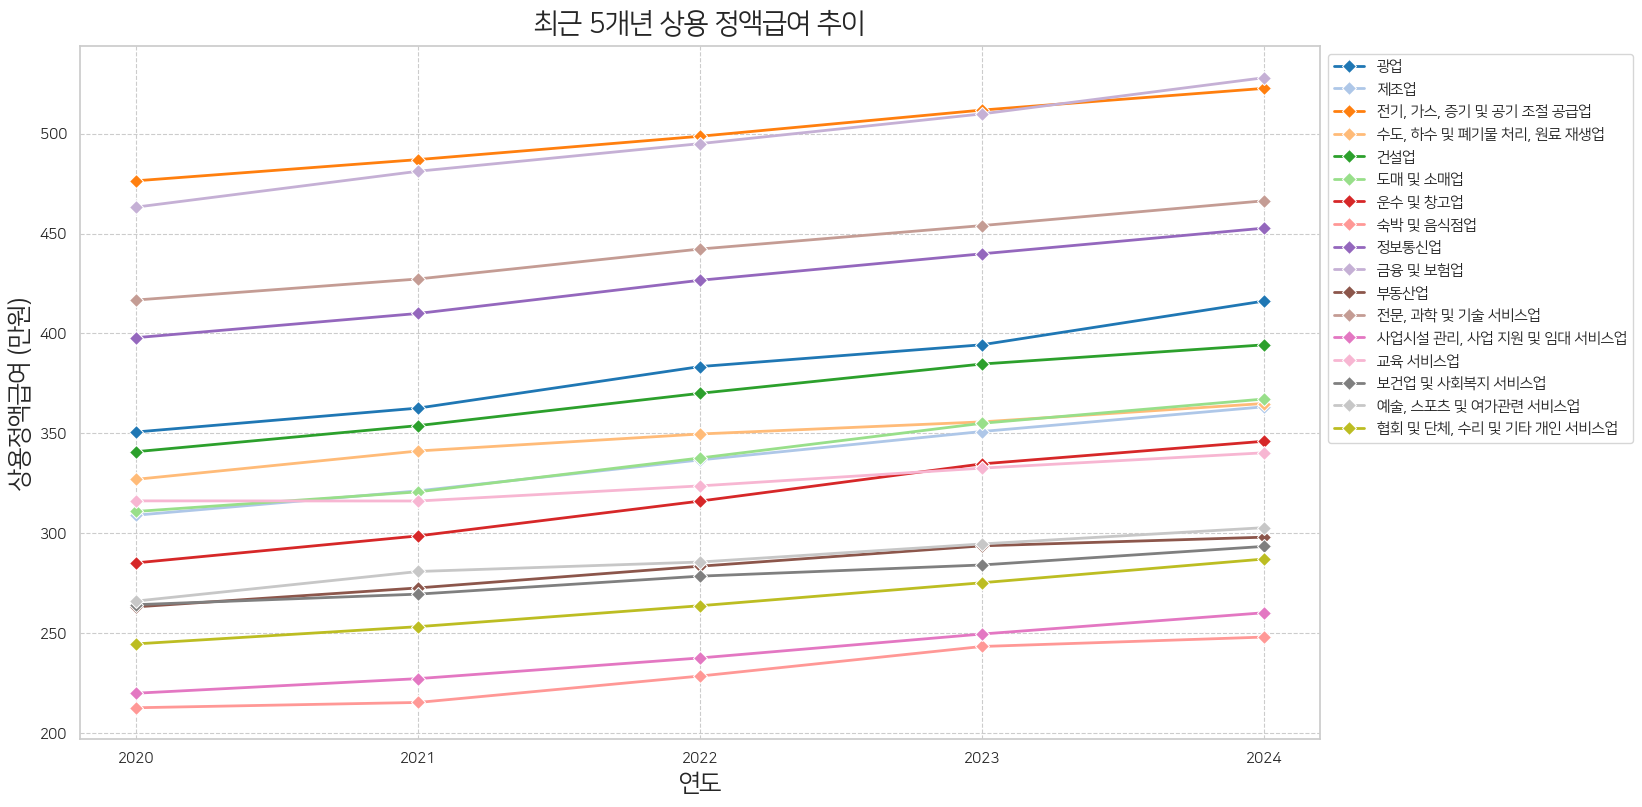

In [17]:
sns.lineplot(constant_payment, x = '연도', y = '비용(만원)', hue = '산업분류', palette='tab20')
plt.title('최근 5개년 상용 정액급여 추이', y = 1.01)
plt.xlabel('연도')
plt.ylabel('상용정액급여 (만원)')
plt.ticklabel_format(axis='y', style='plain')
plt.legend(bbox_to_anchor=(1, 1))
plt.xticks([2020, 2021, 2022, 2023, 2024]) # 얘는 왜 이걸 해줘야 년도로 나올까...
plt.show()

### 최근 5개년간 상용정액급여 평균

In [18]:
constant_payment_mean = constant_payment.groupby(['산업분류', '지표']).agg({'비용(만원)':'mean'}).reset_index()
constant_payment_mean = constant_payment_mean.sort_values('비용(만원)', ascending=False)
constant_payment_mean

,산업분류,지표,비용(만원)
12,"전기, 가스, 증기 및 공기 조절 공급업",상용정액급여,499.320
3,금융 및 보험업,상용정액급여,495.466
13,"전문, 과학 및 기술 서비스업",상용정액급여,441.332
14,정보통신업,상용정액급여,425.426
1,광업,상용정액급여,381.466
0,건설업,상용정액급여,368.754
8,"수도, 하수 및 폐기물 처리, 원료 재생업",상용정액급여,347.716
4,도매 및 소매업,상용정액급여,338.310
15,제조업,상용정액급여,336.246
2,교육 서비스업,상용정액급여,325.788


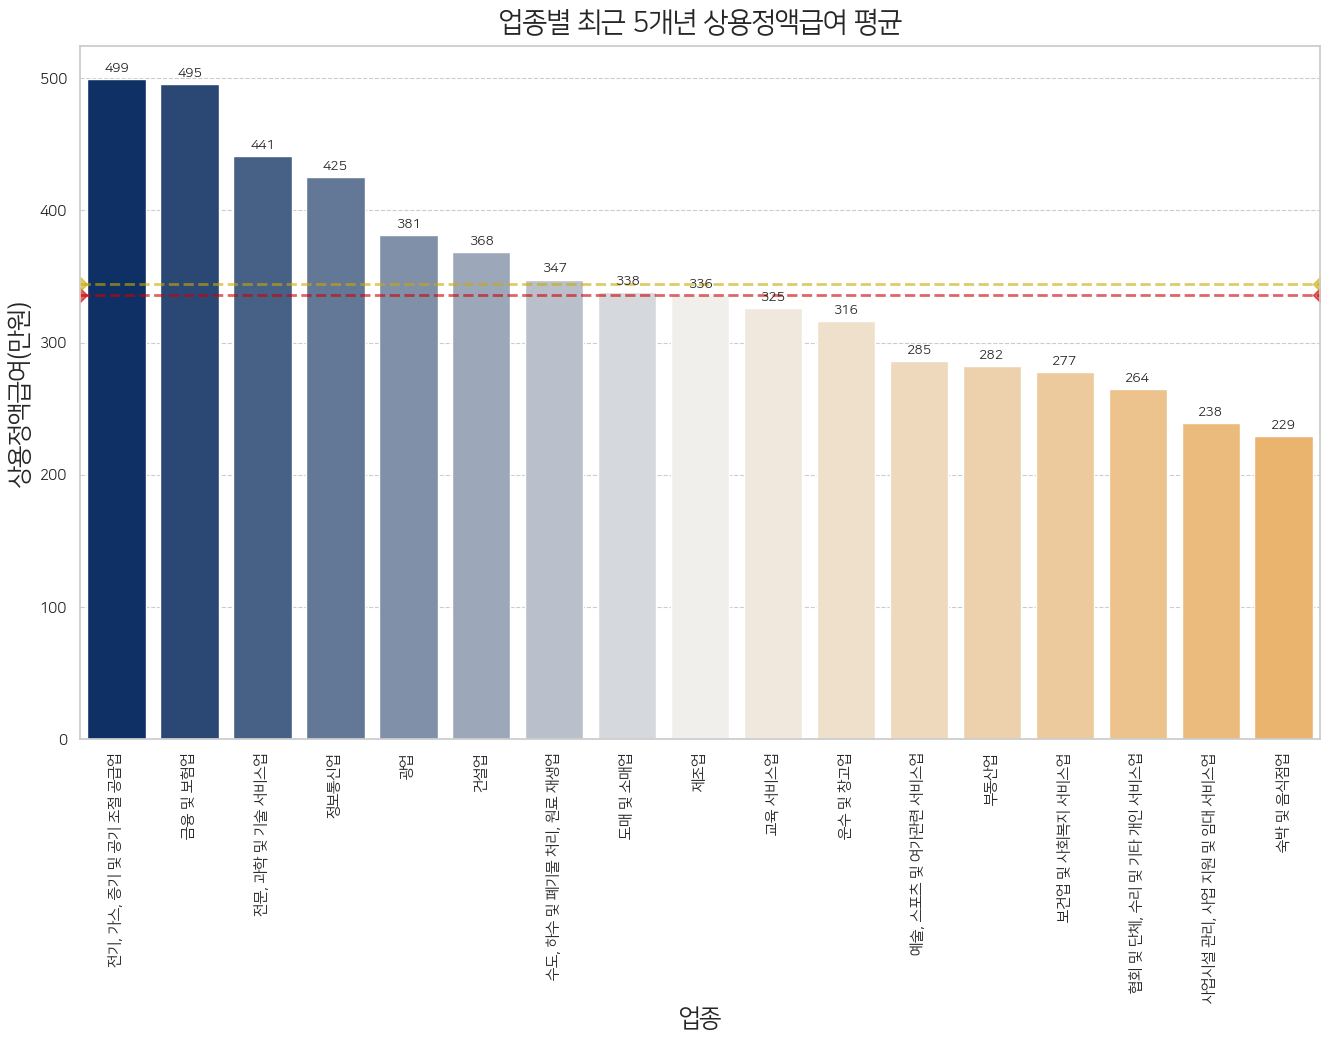

In [19]:
ax = sns.barplot(constant_payment_mean, x = '산업분류', y = '비용(만원)', hue = '산업분류', palette=get_palette(constant_payment_mean['산업분류'].nunique()))
for container in ax.containers:
    # fmt='%d'는 정수로 표시, label_type='edge'는 막대 끝에 표시
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.title('업종별 최근 5개년 상용정액급여 평균', y = 1.01)
plt.xlabel('업종')
plt.ylabel('상용정액급여(만원)')
plt.axhline(np.median(constant_payment_mean['비용(만원)']), linestyle='dashed', color='#cc0000', alpha = 0.6) # 중앙값
plt.axhline(np.mean(constant_payment_mean['비용(만원)']), linestyle='dashed', color='#ccaa00', alpha = 0.6) # 평균
plt.ticklabel_format(axis='y', style='plain')
plt.xticks(rotation=90)
plt.show()

- 상용정액급여는 위에도 썼지만 월급명세서에 맨날 찍히는 돈입니다. 왜 그 월급명세서 받으면 월급 얼마 사대보험(으아악) 얼마 이렇게 나오잖아요? 그겁니다.
- 근데 전체 임금총액은 높은데, 상용임금총액은 딱 중간이네요?

## 상용초과급여

In [20]:
overtime_payment = payment_money.query('지표 == "상용초과급여"')
overtime_payment

,산업분류,연도,지표,비용,비용(만원)
55,광업,2020,상용초과급여,429499.0,42.95
56,제조업,2020,상용초과급여,382741.0,38.27
57,"전기, 가스, 증기 및 공기 조절 공급업",2020,상용초과급여,372488.0,37.25
58,"수도, 하수 및 폐기물 처리, 원료 재생업",2020,상용초과급여,341779.0,34.18
59,건설업,2020,상용초과급여,164798.0,16.48
...,...,...,...,...,...
499,"사업시설 관리, 사업 지원 및 임대 서비스업",2024,상용초과급여,169661.0,16.97
500,교육 서비스업,2024,상용초과급여,59051.0,5.91
501,보건업 및 사회복지 서비스업,2024,상용초과급여,185353.0,18.54
502,"예술, 스포츠 및 여가관련 서비스업",2024,상용초과급여,164896.0,16.49


### 최근 5개년 상용초과급여 추이

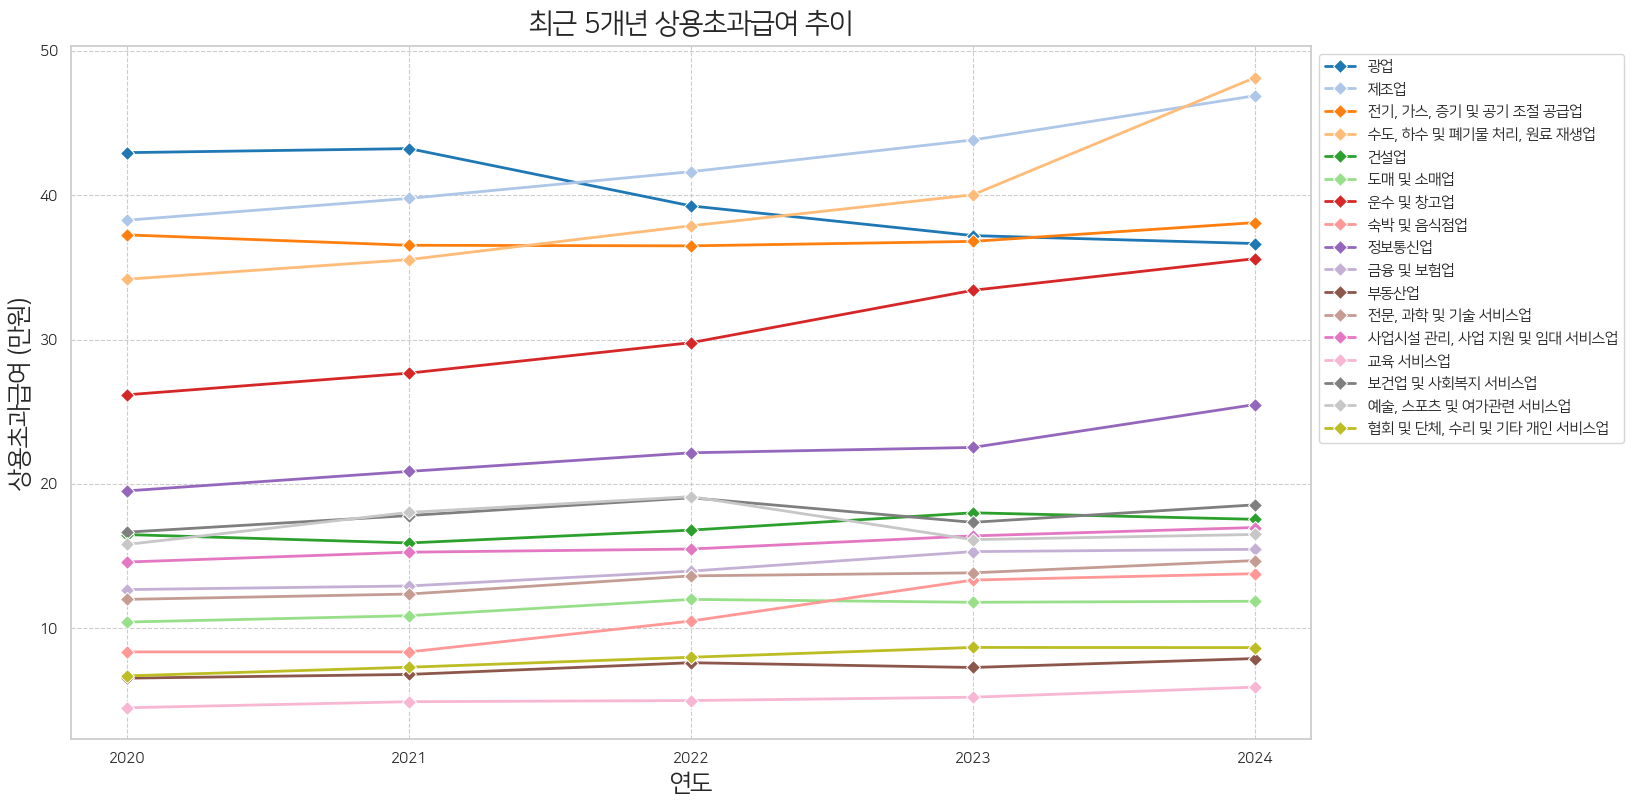

In [21]:
sns.lineplot(overtime_payment, x = '연도', y = '비용(만원)', hue = '산업분류', palette='tab20')
plt.title('최근 5개년 상용초과급여 추이', y = 1.01)
plt.xlabel('연도')
plt.ylabel('상용초과급여 (만원)')
plt.ticklabel_format(axis='y', style='plain')
plt.legend(bbox_to_anchor=(1, 1))
plt.xticks([2020, 2021, 2022, 2023, 2024]) # 얘는 왜 이걸 해줘야 년도로 나올까...
plt.show()

### 최근 5개년 상용초과급여 평균

In [22]:
overtime_payment_mean = overtime_payment.groupby(['산업분류', '지표']).agg({'비용(만원)':'mean'}).reset_index()
overtime_payment_mean = overtime_payment_mean.sort_values('비용(만원)', ascending=False)
overtime_payment_mean

,산업분류,지표,비용(만원)
15,제조업,상용초과급여,42.080
1,광업,상용초과급여,39.858
8,"수도, 하수 및 폐기물 처리, 원료 재생업",상용초과급여,39.154
12,"전기, 가스, 증기 및 공기 조절 공급업",상용초과급여,37.034
11,운수 및 창고업,상용초과급여,30.526
14,정보통신업,상용초과급여,22.106
5,보건업 및 사회복지 서비스업,상용초과급여,17.870
10,"예술, 스포츠 및 여가관련 서비스업",상용초과급여,17.110
0,건설업,상용초과급여,16.940
7,"사업시설 관리, 사업 지원 및 임대 서비스업",상용초과급여,15.736


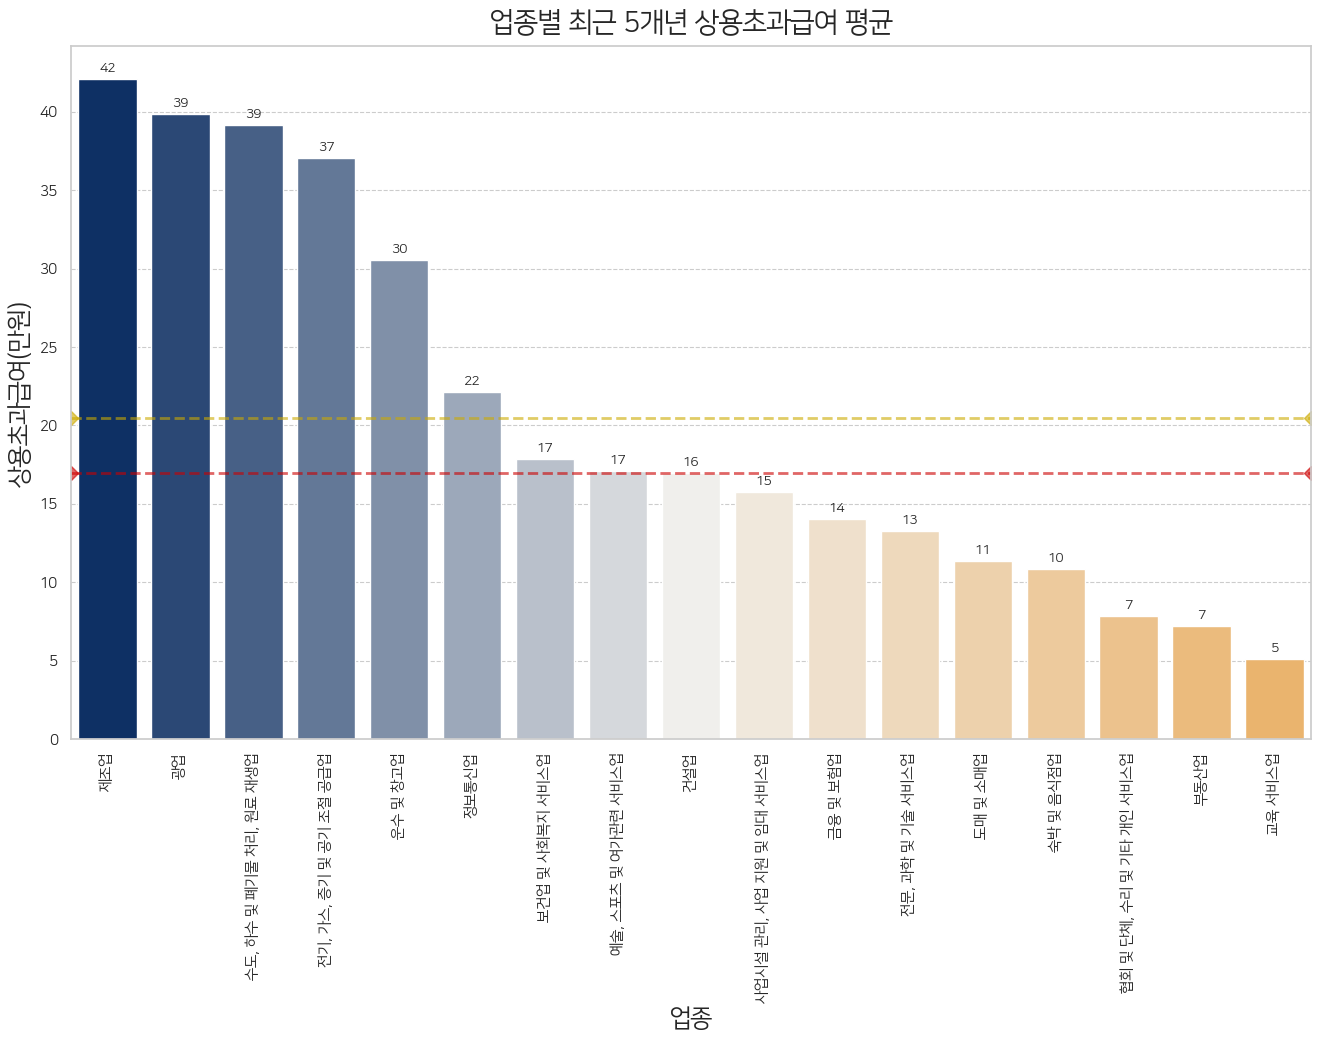

In [23]:
ax = sns.barplot(overtime_payment_mean, x = '산업분류', y = '비용(만원)', hue = '산업분류', palette=get_palette(overtime_payment_mean['산업분류'].nunique()))
for container in ax.containers:
    # fmt='%d'는 정수로 표시, label_type='edge'는 막대 끝에 표시
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.title('업종별 최근 5개년 상용초과급여 평균', y = 1.01)
plt.xlabel('업종')
plt.ylabel('상용초과급여(만원)')
plt.axhline(np.median(overtime_payment_mean['비용(만원)']), linestyle='dashed', color='#cc0000', alpha = 0.6) # 중앙값
plt.axhline(np.mean(overtime_payment_mean['비용(만원)']), linestyle='dashed', color='#ccaa00', alpha = 0.6) # 평균
plt.ticklabel_format(axis='y', style='plain')
plt.xticks(rotation=90)
plt.show()

## 상용특별급여

In [24]:
bonus_payment = payment_money.query('지표 == "상용특별급여"')
bonus_payment

,산업분류,연도,지표,비용,비용(만원)
73,광업,2020,상용특별급여,468766.0,46.88
74,제조업,2020,상용특별급여,585102.0,58.51
75,"전기, 가스, 증기 및 공기 조절 공급업",2020,상용특별급여,1687710.0,168.77
76,"수도, 하수 및 폐기물 처리, 원료 재생업",2020,상용특별급여,376948.0,37.69
77,건설업,2020,상용특별급여,251730.0,25.17
...,...,...,...,...,...
517,"사업시설 관리, 사업 지원 및 임대 서비스업",2024,상용특별급여,160045.0,16.00
518,교육 서비스업,2024,상용특별급여,314227.0,31.42
519,보건업 및 사회복지 서비스업,2024,상용특별급여,238108.0,23.81
520,"예술, 스포츠 및 여가관련 서비스업",2024,상용특별급여,277550.0,27.76


### 최근 5개년 상용특별급여 추이

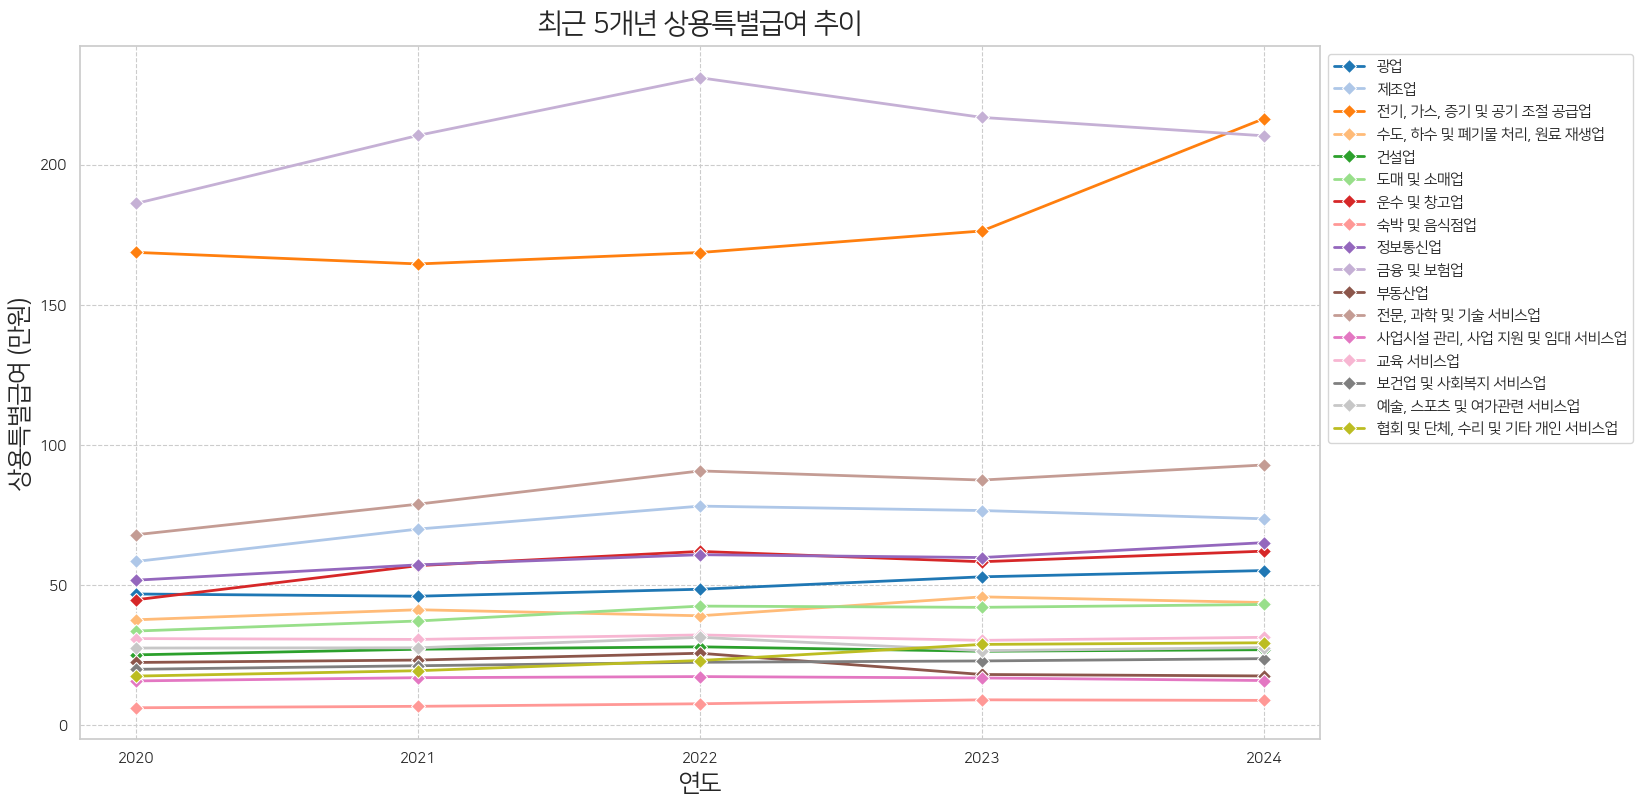

In [25]:
sns.lineplot(bonus_payment, x = '연도', y = '비용(만원)', hue = '산업분류', palette='tab20')
plt.title('최근 5개년 상용특별급여 추이', y = 1.01)
plt.xlabel('연도')
plt.ylabel('상용특별급여 (만원)')
plt.ticklabel_format(axis='y', style='plain')
plt.legend(bbox_to_anchor=(1, 1))
plt.xticks([2020, 2021, 2022, 2023, 2024]) # 얘는 왜 이걸 해줘야 년도로 나올까...
plt.show()

### 최근 5개년 상용특별급여 평균

In [26]:
bonus_payment_mean = bonus_payment.groupby(['산업분류', '지표']).agg({'비용(만원)':'mean'}).reset_index()
bonus_payment_mean = bonus_payment_mean.sort_values('비용(만원)', ascending=False)
bonus_payment_mean

,산업분류,지표,비용(만원)
3,금융 및 보험업,상용특별급여,211.040
12,"전기, 가스, 증기 및 공기 조절 공급업",상용특별급여,179.010
13,"전문, 과학 및 기술 서비스업",상용특별급여,83.652
15,제조업,상용특별급여,71.438
14,정보통신업,상용특별급여,59.018
11,운수 및 창고업,상용특별급여,56.896
1,광업,상용특별급여,49.960
8,"수도, 하수 및 폐기물 처리, 원료 재생업",상용특별급여,41.552
4,도매 및 소매업,상용특별급여,39.748
2,교육 서비스업,상용특별급여,31.134


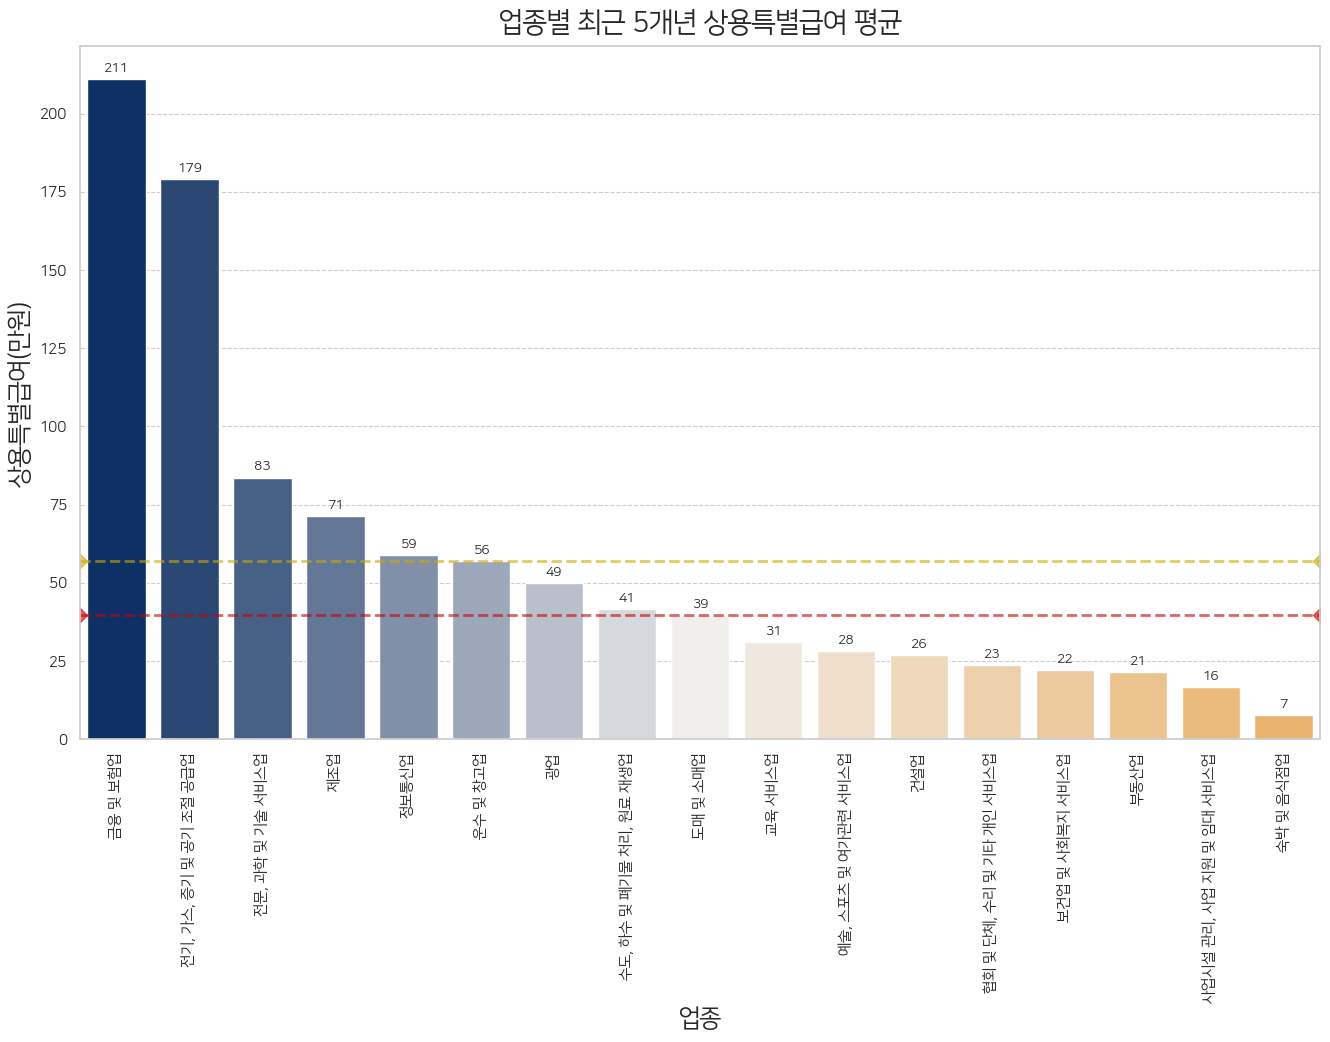

In [27]:
ax = sns.barplot(bonus_payment_mean, x = '산업분류', y = '비용(만원)', hue = '산업분류', palette=get_palette(bonus_payment_mean['산업분류'].nunique()))
for container in ax.containers:
    # fmt='%d'는 정수로 표시, label_type='edge'는 막대 끝에 표시
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.axhline(np.median(bonus_payment_mean['비용(만원)']), linestyle='dashed', color='#cc0000', alpha = 0.6) # 중앙값
plt.axhline(np.mean(bonus_payment_mean['비용(만원)']), linestyle='dashed', color='#ccaa00', alpha = 0.6) # 평균
plt.title('업종별 최근 5개년 상용특별급여 평균', y = 1.01)
plt.xlabel('업종')
plt.ylabel('상용특별급여(만원)')
plt.ticklabel_format(axis='y', style='plain')
plt.xticks(rotation=90)
plt.show()

- 제조업은 많이 주긴 주는데 월급을 많이 주는 게 아니라 초과수당이 엄청 나가는..?

## 급여의 구성비율
>상용임금총액=상용정액급여+상용초과급여+상용특별급여

In [28]:
# 위 등식에 들어가는 요소들만 추출
jipyo_list = ['상용임금총액', '상용정액급여', '상용초과급여', '상용특별급여']
payment_money_ratio = payment_money.query('지표 in @jipyo_list')

In [29]:
# 이거 최근 5개년이라서 묶고 평균좀 낼게용
payment_money_ratio = payment_money_ratio.groupby(['산업분류','지표']).agg({'비용(만원)':'mean'}).reset_index()
payment_money_ratio

,산업분류,지표,비용(만원)
0,건설업,상용임금총액,412.454
1,건설업,상용정액급여,368.754
2,건설업,상용초과급여,16.940
3,건설업,상용특별급여,26.764
4,광업,상용임금총액,471.286
...,...,...,...
63,제조업,상용특별급여,71.438
64,"협회 및 단체, 수리 및 기타 개인 서비스업",상용임금총액,296.364
65,"협회 및 단체, 수리 및 기타 개인 서비스업",상용정액급여,264.790
66,"협회 및 단체, 수리 및 기타 개인 서비스업",상용초과급여,7.854


### 다시 펴봅시다.
- 이거 펴야 구성비 구합니다. 

In [30]:
# 저게 업종별로 비율이 다 다르잖아요? 그래서 우리는 어떻게 할거냐면
# 일단 상용임금총액을 100으로 둬요. 그리고 뒤에 세개를 빼면 구성비가 나오겠죠? 바로 그겁니다.
# 그래서 표를 다시 펴야돼요.

# (가오가이거 파이널퓨전 들으면서 피벗하는중)
payment_money_ratio_wide = pd.pivot_table(payment_money_ratio, index=['산업분류'], columns='지표', values='비용(만원)').reset_index()

payment_money_ratio_wide['상용정액급여비'] = payment_money_ratio_wide['상용정액급여'] / payment_money_ratio_wide['상용임금총액'] * 100
payment_money_ratio_wide['상용초과급여비'] = payment_money_ratio_wide['상용초과급여'] / payment_money_ratio_wide['상용임금총액'] * 100
payment_money_ratio_wide['상용특별급여비'] = payment_money_ratio_wide['상용특별급여'] / payment_money_ratio_wide['상용임금총액'] * 100

# 예 나왔습니다 예
payment_money_ratio_wide

지표,산업분류,상용임금총액,상용정액급여,상용초과급여,상용특별급여,상용정액급여비,상용초과급여비,상용특별급여비
0,건설업,412.454,368.754,16.940,26.764,89.404879,4.107125,6.488966
1,광업,471.286,381.466,39.858,49.960,80.941509,8.457285,10.600782
2,교육 서비스업,362.016,325.788,5.096,31.134,89.992708,1.407673,8.600172
3,금융 및 보험업,720.566,495.466,14.060,211.040,68.760669,1.951244,29.288087
4,도매 및 소매업,389.446,338.310,11.384,39.748,86.869553,2.923127,10.206293
5,보건업 및 사회복지 서비스업,317.964,277.976,17.870,22.122,87.423734,5.620133,6.957391
6,부동산업,310.888,282.214,7.216,21.460,90.776743,2.321093,6.902807
7,"사업시설 관리, 사업 지원 및 임대 서비스업",271.294,238.914,15.736,16.644,88.064609,5.800349,6.135042
8,"수도, 하수 및 폐기물 처리, 원료 재생업",428.420,347.716,39.154,41.552,81.162411,9.139163,9.698894
9,숙박 및 음식점업,248.212,229.582,10.858,7.768,92.494319,4.374486,3.129583


In [31]:
# 근데 이걸 왜 또 녹이는건지는 묻지 맙시다
plot_df = payment_money_ratio_wide.melt(
    id_vars=['산업분류'],
    value_vars=['상용정액급여비', '상용초과급여비', '상용특별급여비'],
    var_name='급여항목',
    value_name='구성비'
)

plot_df

,산업분류,급여항목,구성비
0,건설업,상용정액급여비,89.404879
1,광업,상용정액급여비,80.941509
2,교육 서비스업,상용정액급여비,89.992708
3,금융 및 보험업,상용정액급여비,68.760669
4,도매 및 소매업,상용정액급여비,86.869553
5,보건업 및 사회복지 서비스업,상용정액급여비,87.423734
6,부동산업,상용정액급여비,90.776743
7,"사업시설 관리, 사업 지원 및 임대 서비스업",상용정액급여비,88.064609
8,"수도, 하수 및 폐기물 처리, 원료 재생업",상용정액급여비,81.162411
9,숙박 및 음식점업,상용정액급여비,92.494319


### 시각화 드가자!

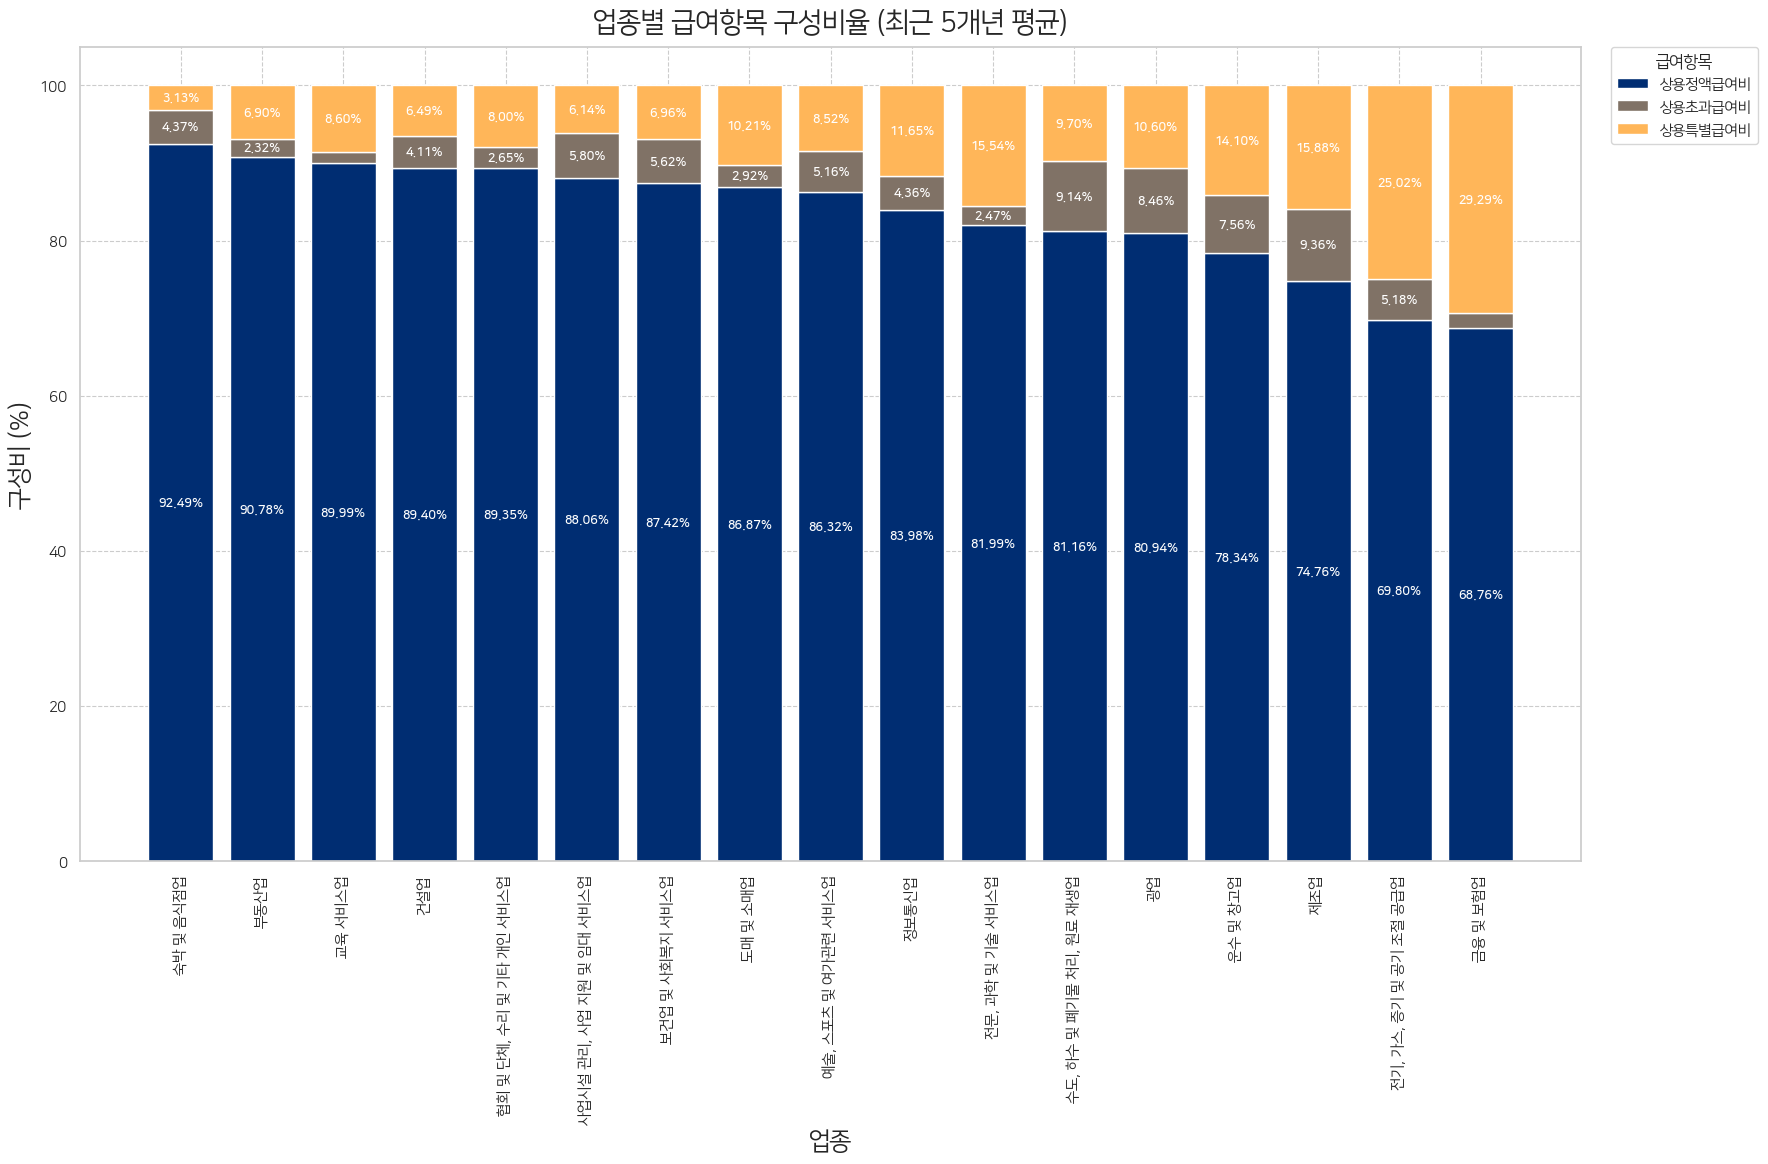

In [32]:
my_order = ['상용정액급여비', '상용초과급여비', '상용특별급여비']
order = (plot_df[plot_df['급여항목'] == '상용정액급여비']
         .sort_values('구성비', ascending=False)['산업분류'].tolist())

industries = order  # 업종 목록

colors = [custom_cmap_dark(0.0), custom_cmap_dark(0.5), custom_cmap_dark(1.0)]  # 기존 팔레트 그대로 사용

fig, ax = plt.subplots(figsize=(18, 12))

x = np.arange(len(industries))
width = 0.8

bottoms = np.zeros(len(industries))

for i, item in enumerate(my_order):
    values = []
    for ind in industries:
        val = plot_df[(plot_df['산업분류'] == ind) & (plot_df['급여항목'] == item)]['구성비'].values
        values.append(val[0] if len(val) > 0 else 0)
    values = np.array(values)

    bars = ax.bar(x, values, width=width, bottom=bottoms, color=colors[i], label=item)

    # 텍스트 레이블
    for j, (bar, v) in enumerate(zip(bars, values)):
        if v > 2.0:
            ax.text(bar.get_x() + bar.get_width()/2, bottoms[j] + v/2,
                    f'{v:.2f}%', ha='center', va='center', color='white', fontsize=9, fontweight='bold')

    bottoms += values

ax.set_xticks(x)
ax.set_xticklabels(industries, rotation=90)
ax.set_title('업종별 급여항목 구성비율 (최근 5개년 평균)', y=1.01)
ax.set_xlabel('업종')
ax.set_ylabel('구성비 (%)')
ax.legend(title='급여항목', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

- 다른건 다 씨본인데 쟤는 왜 matplotlib이냐...
- 씨본에서 그렸는데 범례 순서가 자꾸 뻑나더라고요. 상용정액급여비랑 상용특별급여비를 자꾸 바꾸는데 이게 뭔 짓을 해도 개선이 안됩니다.
- 이렇게 놓고 보니까 제조업은 명세서에 찍혀나오는 돈은 뒤에서 2등, 초과급여는 1등, 떡값(특별급여)은 3등이네요.

# 시간은 금이니까 시간도 봐야징
- 요즘은 주는만큼 한다고들 하죠.

In [33]:
payment_date['지표'].value_counts()

지표
전체근로일수       85
상용근로일수       85
임시일용근로일수     85
전체근로시간       85
상용총근로시간      85
상용소정실근로시간    85
상용초과근로시간     85
임시일용근로시간     85
Name: count, dtype: int64

In [34]:
# 이거 쌩으로 그리면 참사터지니까 5개년 평균부터 내겠습니다.
total_date_all = payment_date.groupby(['산업분류', '지표']).agg({'수치':'mean'}).unstack()

# 사실 이렇게만 해도 되거든요? 되는데 문제가 하나 있어요. 히트맵이 완전 중구난방이라 뭐가 뭔지 몰라요 우리가.
# total_date_all.style.format("{:.3f}").background_gradient(cmap='RdYlGn', axis=1)

# 그래서 정규화를 해줄겁니다.
heatmap_norm = (total_date_all - total_date_all.min()) / (total_date_all.max() - total_date_all.min())
heatmap_norm.style.format("{:.3f}").background_gradient(cmap='RdYlGn', axis=1)

1. 전체근로일수: 근로계약, 취업규칙, 단체협약 등에 따라 근무하기로 정한 날의 총합 (휴일은 빠집니당)
2. 상용근로일수: 1년 이상의 고용계약을 체결하거나, 기간의 정함이 없더라도 채용 절차를 거쳐 퇴직금/상여금 등을 받는 상용근로자가 실제 사업장에 근무한 일수
3. 임시일용근로일수: 일용직 노동자의 근로일수
4. 전체근로시간: 근로자가 사용자의 지휘·감독 아래 근로계약상의 업무를 수행하는 모든 시간 (밥때/출퇴근 빠짐... 회식도 포함인가요?)
5. 상용총근로시간: 근로자가 사용자의 지휘·감독 아래 실제 근로를 제공한 총 시간 (야근 및 초과근무, 휴일근무 포함)
6. 상용소정실근로시간: 근로계약서나 취업규칙을 통해 정해진 근로시간(소정근로시간) 내에서, 상용근로자(기간의 정함이 없는 근로자)가 실제로 근무한 시간 (9 to 6일 경우 밥때빼고 8시간)
7. 상용초과근로시간: 근로기준법상 법정근로시간인 1일 8시간 또는 1주 40시간을 초과하여 근무한 시간
8. 임시일용근로시간: 일용직 노동자의 근로시간

복잡해요...

## 전체 근로일수

In [35]:
total_work_day = payment_date.query('지표 == "전체근로일수"')
total_work_day

,산업분류,연도,지표,수치
1,광업,2020,전체근로일수,21.6
2,제조업,2020,전체근로일수,20.2
3,"전기, 가스, 증기 및 공기 조절 공급업",2020,전체근로일수,19.3
4,"수도, 하수 및 폐기물 처리, 원료 재생업",2020,전체근로일수,21.3
5,건설업,2020,전체근로일수,16.9
...,...,...,...,...
589,"사업시설 관리, 사업 지원 및 임대 서비스업",2024,전체근로일수,19.2
590,교육 서비스업,2024,전체근로일수,18.1
591,보건업 및 사회복지 서비스업,2024,전체근로일수,19.9
592,"예술, 스포츠 및 여가관련 서비스업",2024,전체근로일수,18.8


### 최근 5개년 전체근로일수 추이

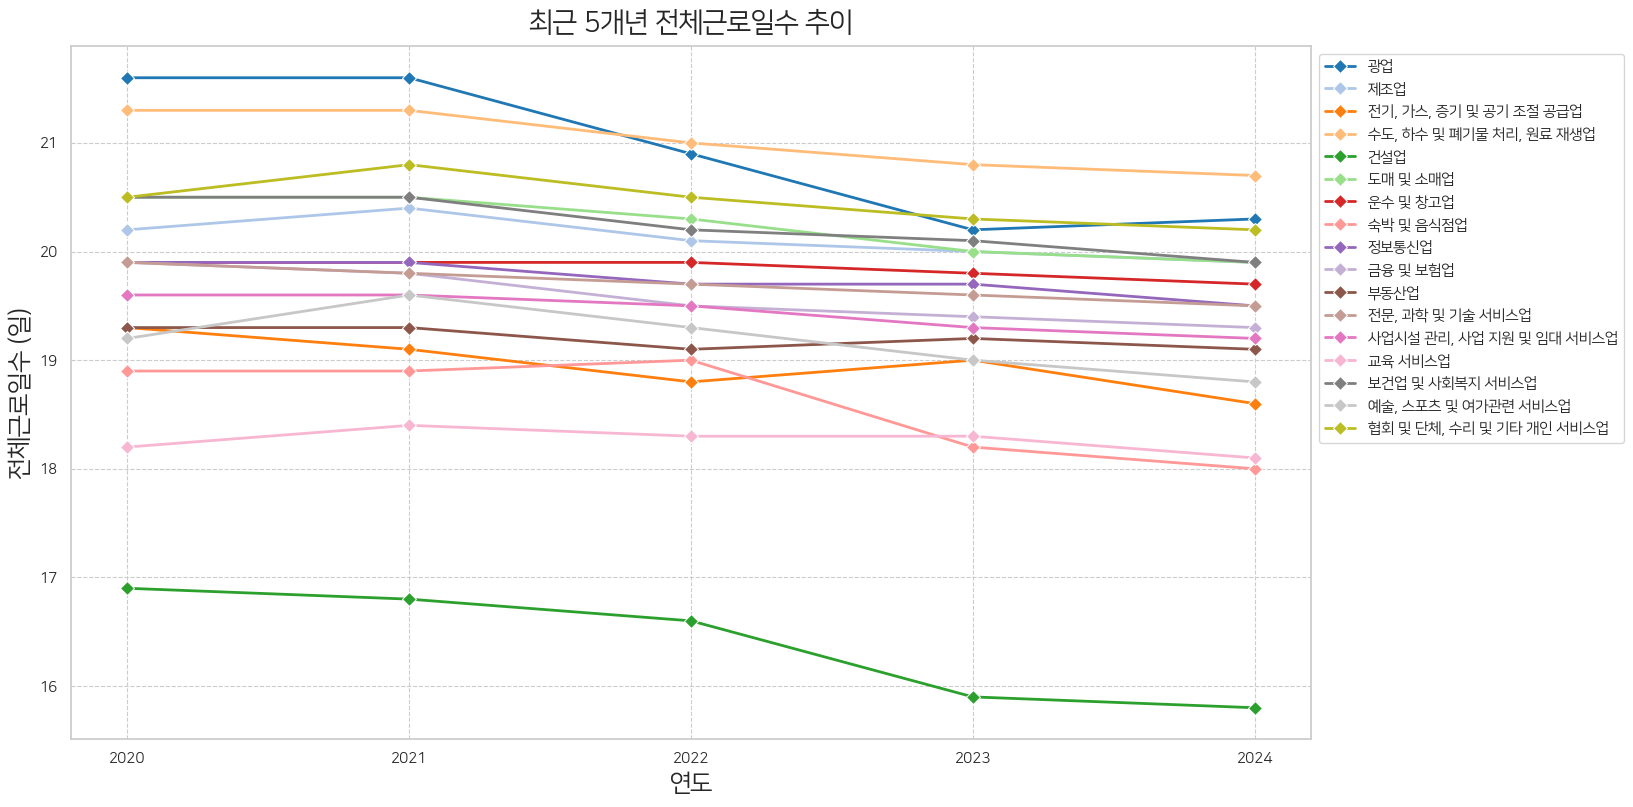

In [36]:
sns.lineplot(total_work_day, x = '연도', y = '수치', hue = '산업분류', palette='tab20')
plt.title('최근 5개년 전체근로일수 추이', y = 1.01)
plt.xlabel('연도')
plt.ylabel('전체근로일수 (일)')
plt.ticklabel_format(axis='y', style='plain')
plt.legend(bbox_to_anchor=(1, 1))
plt.xticks([2020, 2021, 2022, 2023, 2024]) # 얘는 왜 이걸 해줘야 년도로 나올까...
plt.show()

- 높이는 다르지만 대체로 감소세입니다. 제조업은 20일 언저리에 있네요.
- 이게 어느정도인지 감이 안 오시죠? 2월달 설날까지 일하면 딱 20일입니다. 2월은 좀 짧아서 꽉 채워진거고 보통 한달에 평일만 치면 그 정도는 됩니다. 

### 최근 5개년 평균

In [37]:
total_work_mean = total_work_day.groupby(['산업분류', '지표']).agg({'수치':'mean'}).reset_index()
total_work_mean = total_work_mean.sort_values('수치', ascending=False)
total_work_mean

,산업분류,지표,수치
8,"수도, 하수 및 폐기물 처리, 원료 재생업",전체근로일수,21.02
1,광업,전체근로일수,20.92
16,"협회 및 단체, 수리 및 기타 개인 서비스업",전체근로일수,20.46
4,도매 및 소매업,전체근로일수,20.24
5,보건업 및 사회복지 서비스업,전체근로일수,20.24
15,제조업,전체근로일수,20.12
11,운수 및 창고업,전체근로일수,19.84
14,정보통신업,전체근로일수,19.74
13,"전문, 과학 및 기술 서비스업",전체근로일수,19.70
3,금융 및 보험업,전체근로일수,19.58


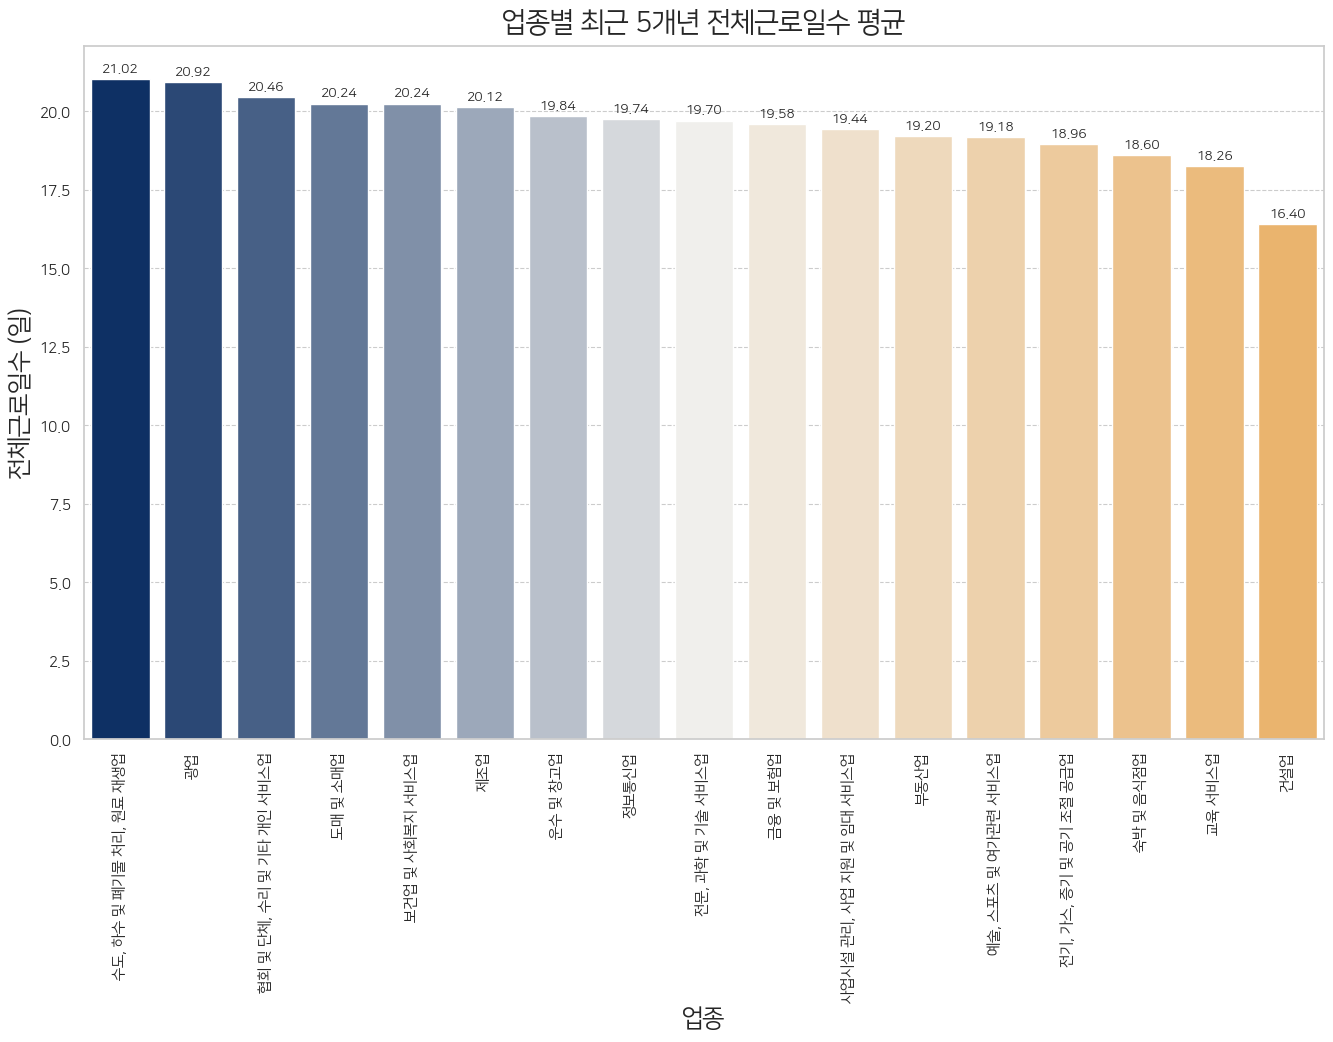

In [38]:
ax = sns.barplot(total_work_mean, x = '산업분류', y = '수치', hue = '산업분류', palette=get_palette(bonus_payment_mean['산업분류'].nunique()))
for container in ax.containers:
    # fmt='%d'는 정수로 표시, label_type='edge'는 막대 끝에 표시
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# plt.axhline(np.median(total_work_mean['수치']), linestyle='dashed', color='#cc0000') # 중앙값
# plt.axhline(np.mean(total_work_mean['수치']), linestyle='dashed', color='#ccaa00') # 평균
plt.title('업종별 최근 5개년 전체근로일수 평균', y = 1.01)
plt.xlabel('업종')
plt.ylabel('전체근로일수 (일)')
plt.ticklabel_format(axis='y', style='plain')
plt.xticks(rotation=90)
plt.show()

## 상용근로일수

In [39]:
sangyong_work_day = payment_date.query('지표 == "상용근로일수"')
sangyong_work_day

,산업분류,연도,지표,수치
19,광업,2020,상용근로일수,21.9
20,제조업,2020,상용근로일수,20.4
21,"전기, 가스, 증기 및 공기 조절 공급업",2020,상용근로일수,19.4
22,"수도, 하수 및 폐기물 처리, 원료 재생업",2020,상용근로일수,21.6
23,건설업,2020,상용근로일수,20.7
...,...,...,...,...
607,"사업시설 관리, 사업 지원 및 임대 서비스업",2024,상용근로일수,20.0
608,교육 서비스업,2024,상용근로일수,18.4
609,보건업 및 사회복지 서비스업,2024,상용근로일수,20.2
610,"예술, 스포츠 및 여가관련 서비스업",2024,상용근로일수,19.8


### 최근 5년간 추이

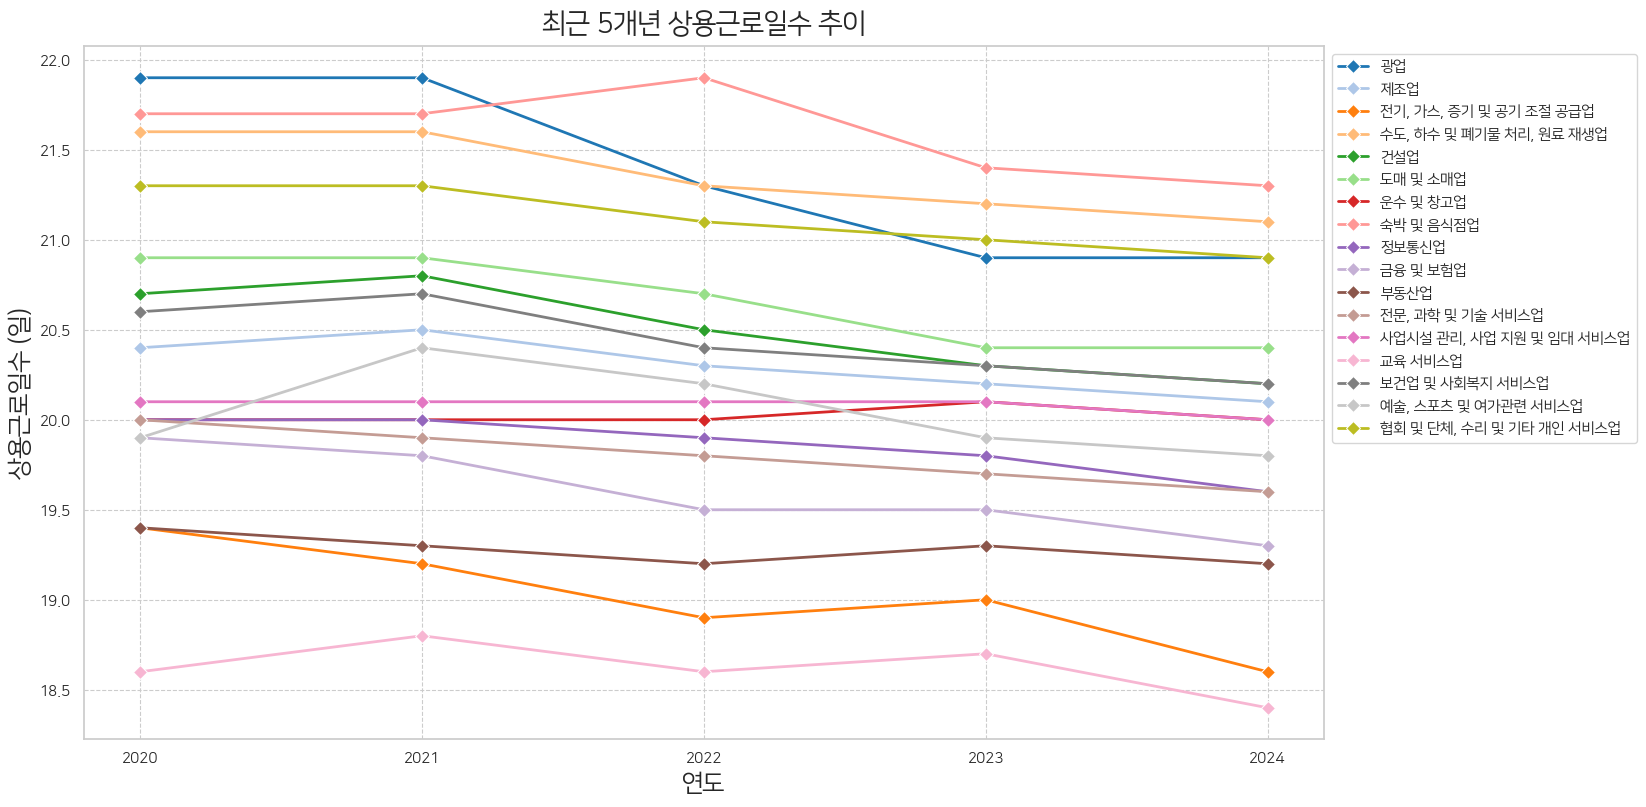

In [40]:
sns.lineplot(sangyong_work_day, x = '연도', y = '수치', hue = '산업분류', palette='tab20')
plt.title('최근 5개년 상용근로일수 추이', y = 1.01)
plt.xlabel('연도')
plt.ylabel('상용근로일수 (일)')
plt.ticklabel_format(axis='y', style='plain')
plt.legend(bbox_to_anchor=(1, 1))
plt.xticks([2020, 2021, 2022, 2023, 2024]) # 얘는 왜 이걸 해줘야 년도로 나올까...
plt.show()

### 최근 5개년 상용근로일수 평균

In [41]:
sangyong_work_mean = sangyong_work_day.groupby(['산업분류', '지표']).agg({'수치':'mean'}).reset_index()
sangyong_work_mean = sangyong_work_mean.sort_values('수치', ascending=False)
sangyong_work_mean

,산업분류,지표,수치
9,숙박 및 음식점업,상용근로일수,21.60
1,광업,상용근로일수,21.38
8,"수도, 하수 및 폐기물 처리, 원료 재생업",상용근로일수,21.36
16,"협회 및 단체, 수리 및 기타 개인 서비스업",상용근로일수,21.12
4,도매 및 소매업,상용근로일수,20.66
0,건설업,상용근로일수,20.50
5,보건업 및 사회복지 서비스업,상용근로일수,20.44
15,제조업,상용근로일수,20.30
7,"사업시설 관리, 사업 지원 및 임대 서비스업",상용근로일수,20.08
10,"예술, 스포츠 및 여가관련 서비스업",상용근로일수,20.04


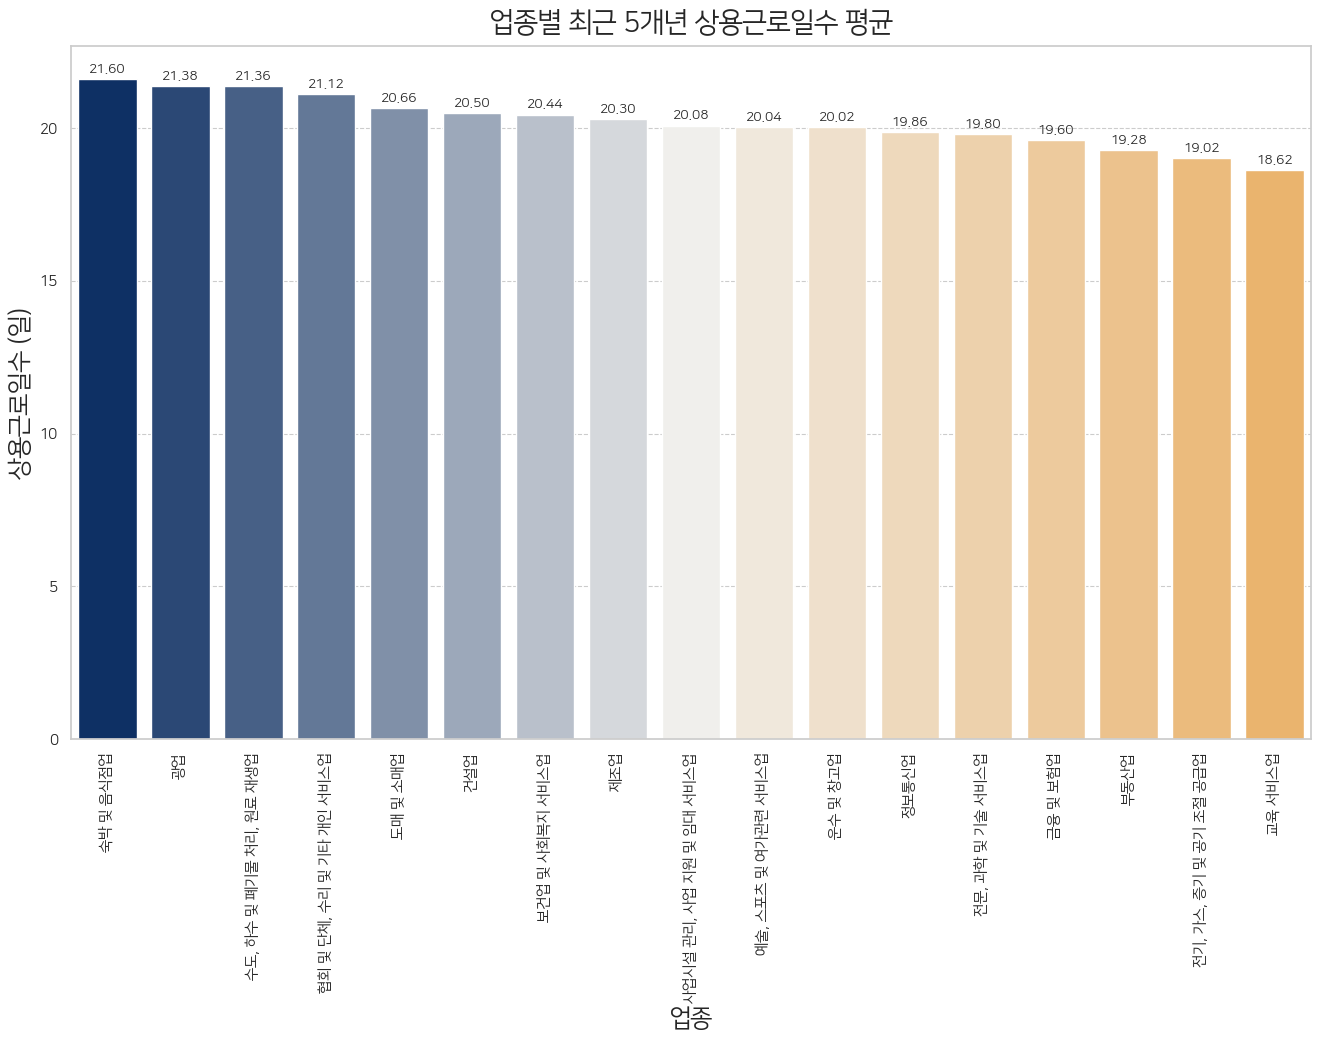

In [42]:
ax = sns.barplot(sangyong_work_mean, x = '산업분류', y = '수치', hue = '산업분류', palette=get_palette(bonus_payment_mean['산업분류'].nunique()))
for container in ax.containers:
    # fmt='%d'는 정수로 표시, label_type='edge'는 막대 끝에 표시
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# plt.axhline(np.median(sangyong_work_mean['수치']), linestyle='dashed', color='#cc0000') # 중앙값
# plt.axhline(np.mean(sangyong_work_mean['수치']), linestyle='dashed', color='#ccaa00') # 평균
plt.title('업종별 최근 5개년 상용근로일수 평균', y = 1.01)
plt.xlabel('업종')
plt.ylabel('상용근로일수 (일)')
plt.ticklabel_format(axis='y', style='plain')
plt.xticks(rotation=90)
plt.show()

## 전체 근로시간

In [43]:
total_work_time = payment_date.query('지표 == "전체근로시간"')
total_work_time

,산업분류,연도,지표,수치
55,광업,2020,전체근로시간,181.2
56,제조업,2020,전체근로시간,172.7
57,"전기, 가스, 증기 및 공기 조절 공급업",2020,전체근로시간,163.7
58,"수도, 하수 및 폐기물 처리, 원료 재생업",2020,전체근로시간,176.5
59,건설업,2020,전체근로시간,136.9
...,...,...,...,...
643,"사업시설 관리, 사업 지원 및 임대 서비스업",2024,전체근로시간,157.5
644,교육 서비스업,2024,전체근로시간,134.1
645,보건업 및 사회복지 서비스업,2024,전체근로시간,148.3
646,"예술, 스포츠 및 여가관련 서비스업",2024,전체근로시간,145.7


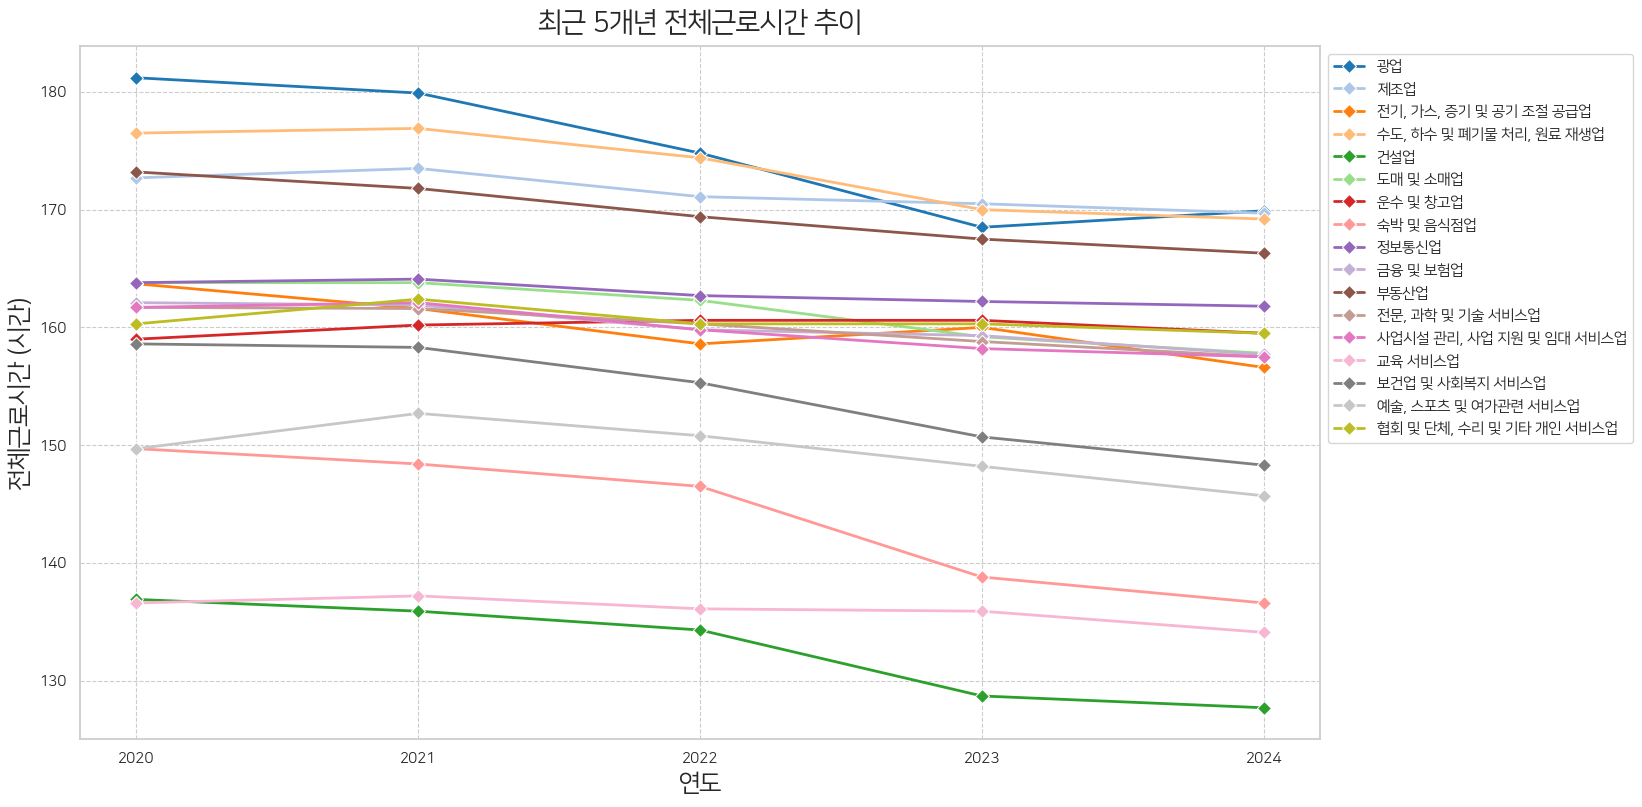

In [44]:
sns.lineplot(total_work_time, x = '연도', y = '수치', hue = '산업분류', palette='tab20')
plt.title('최근 5개년 전체근로시간 추이', y = 1.01)
plt.xlabel('연도')
plt.ylabel('전체근로시간 (시간)')
plt.ticklabel_format(axis='y', style='plain')
plt.legend(bbox_to_anchor=(1, 1))
plt.xticks([2020, 2021, 2022, 2023, 2024]) # 얘는 왜 이걸 해줘야 년도로 나올까...
plt.show()

- 저게 많은거야... 적은거야...?
- 일단 나인 투 식스(9 to 6) 기준으로 평일 5일동안 일하면 주 40시간입니다. 그리고 한달이 20일이라고 가정하면 8 * 20 해서 160시간이 되고요. 2월은 설날 꼈으니까 이번달에 설날 외에 어떠한 연차도 쓰지 않고 평일을 꽉꽉 채운다면 136시간이죠. 2월은 너무 짧지 않냐고요? 보통 한달에 평일이 20일정도 있다 상정하면 한달에 160시간... 최대 23일까지 있으니까 184시간까지도 가능하겠군요.
- 업계에 따라 양상은 다르지만 전체적으로 우하향이긴 합니다.

### 최근 5개년 평균

In [45]:
total_time_mean = total_work_time.groupby(['산업분류', '지표']).agg({'수치':'mean'}).reset_index()
total_time_mean = total_time_mean.sort_values('수치', ascending=False)
total_time_mean

,산업분류,지표,수치
1,광업,전체근로시간,174.86
8,"수도, 하수 및 폐기물 처리, 원료 재생업",전체근로시간,173.40
15,제조업,전체근로시간,171.50
6,부동산업,전체근로시간,169.64
14,정보통신업,전체근로시간,162.92
4,도매 및 소매업,전체근로시간,161.38
16,"협회 및 단체, 수리 및 기타 개인 서비스업",전체근로시간,160.56
3,금융 및 보험업,전체근로시간,160.16
12,"전기, 가스, 증기 및 공기 조절 공급업",전체근로시간,160.10
11,운수 및 창고업,전체근로시간,159.98


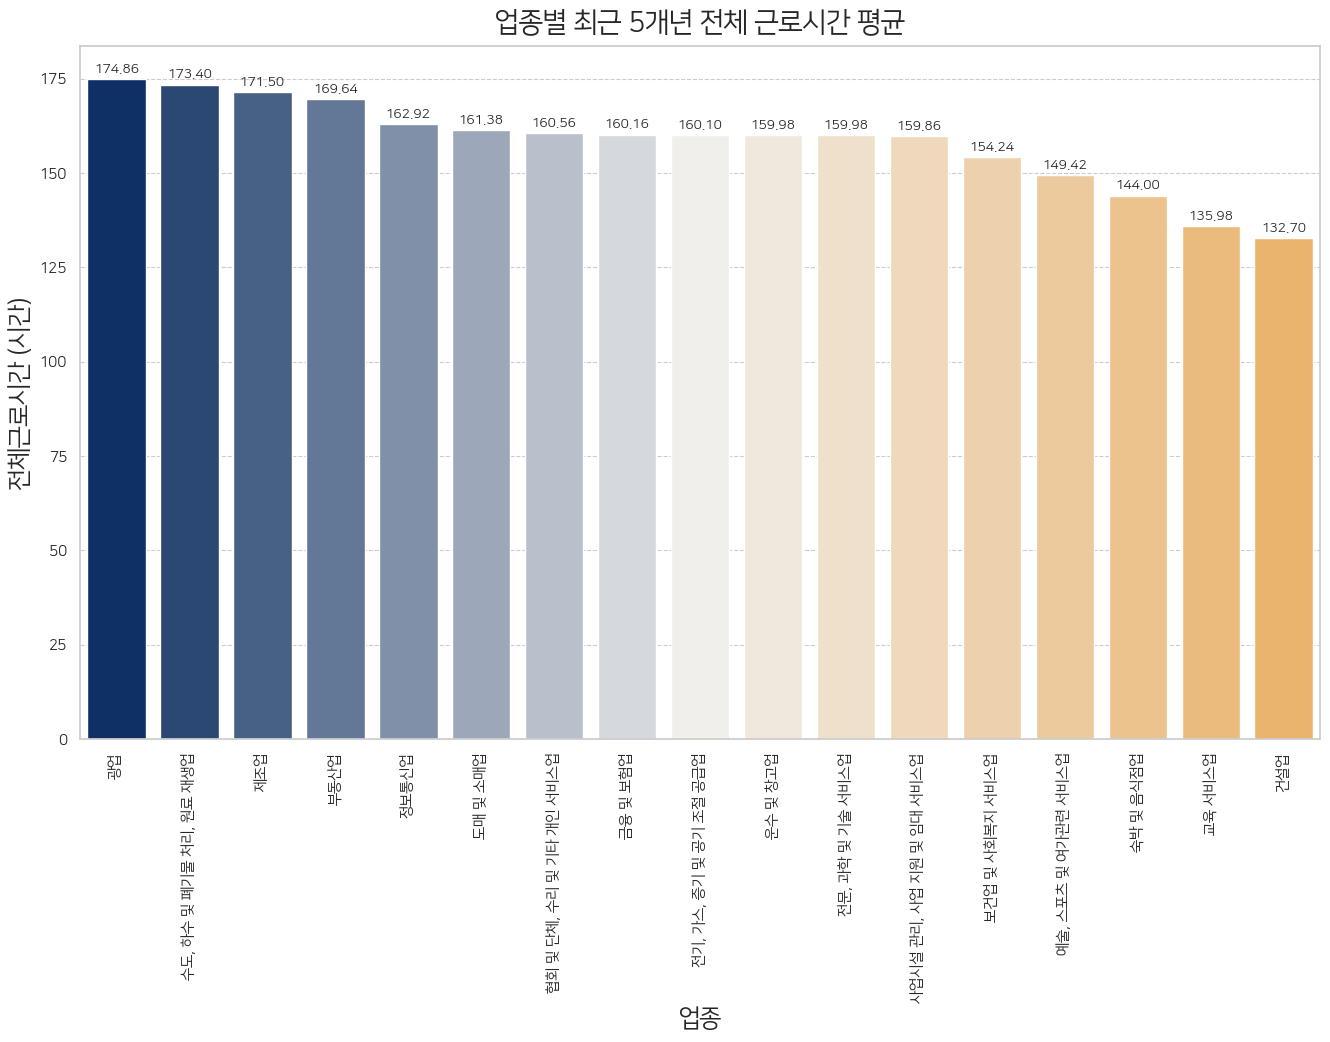

In [46]:
ax = sns.barplot(total_time_mean, x = '산업분류', y = '수치', hue = '산업분류', palette=get_palette(bonus_payment_mean['산업분류'].nunique()))
for container in ax.containers:
    # fmt='%d'는 정수로 표시, label_type='edge'는 막대 끝에 표시
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# plt.axhline(np.median(total_time_mean['수치']), linestyle='dashed', color='#cc0000') # 중앙값
# plt.axhline(np.mean(total_time_mean['수치']), linestyle='dashed', color='#ccaa00') # 평균
plt.title('업종별 최근 5개년 전체 근로시간 평균', y = 1.01)
plt.xlabel('업종')
plt.ylabel('전체근로시간 (시간)')
plt.ticklabel_format(axis='y', style='plain')
plt.xticks(rotation=90)
plt.show()

## 상용총근로시간

In [47]:
sangyong_work_time = payment_date.query('지표 == "상용총근로시간"')
sangyong_work_time

,산업분류,연도,지표,수치
73,광업,2020,상용총근로시간,183.7
74,제조업,2020,상용총근로시간,174.5
75,"전기, 가스, 증기 및 공기 조절 공급업",2020,상용총근로시간,164.0
76,"수도, 하수 및 폐기물 처리, 원료 재생업",2020,상용총근로시간,179.3
77,건설업,2020,상용총근로시간,169.4
...,...,...,...,...
661,"사업시설 관리, 사업 지원 및 임대 서비스업",2024,상용총근로시간,164.1
662,교육 서비스업,2024,상용총근로시간,139.0
663,보건업 및 사회복지 서비스업,2024,상용총근로시간,153.0
664,"예술, 스포츠 및 여가관련 서비스업",2024,상용총근로시간,155.2


### 최근 5개년 추이

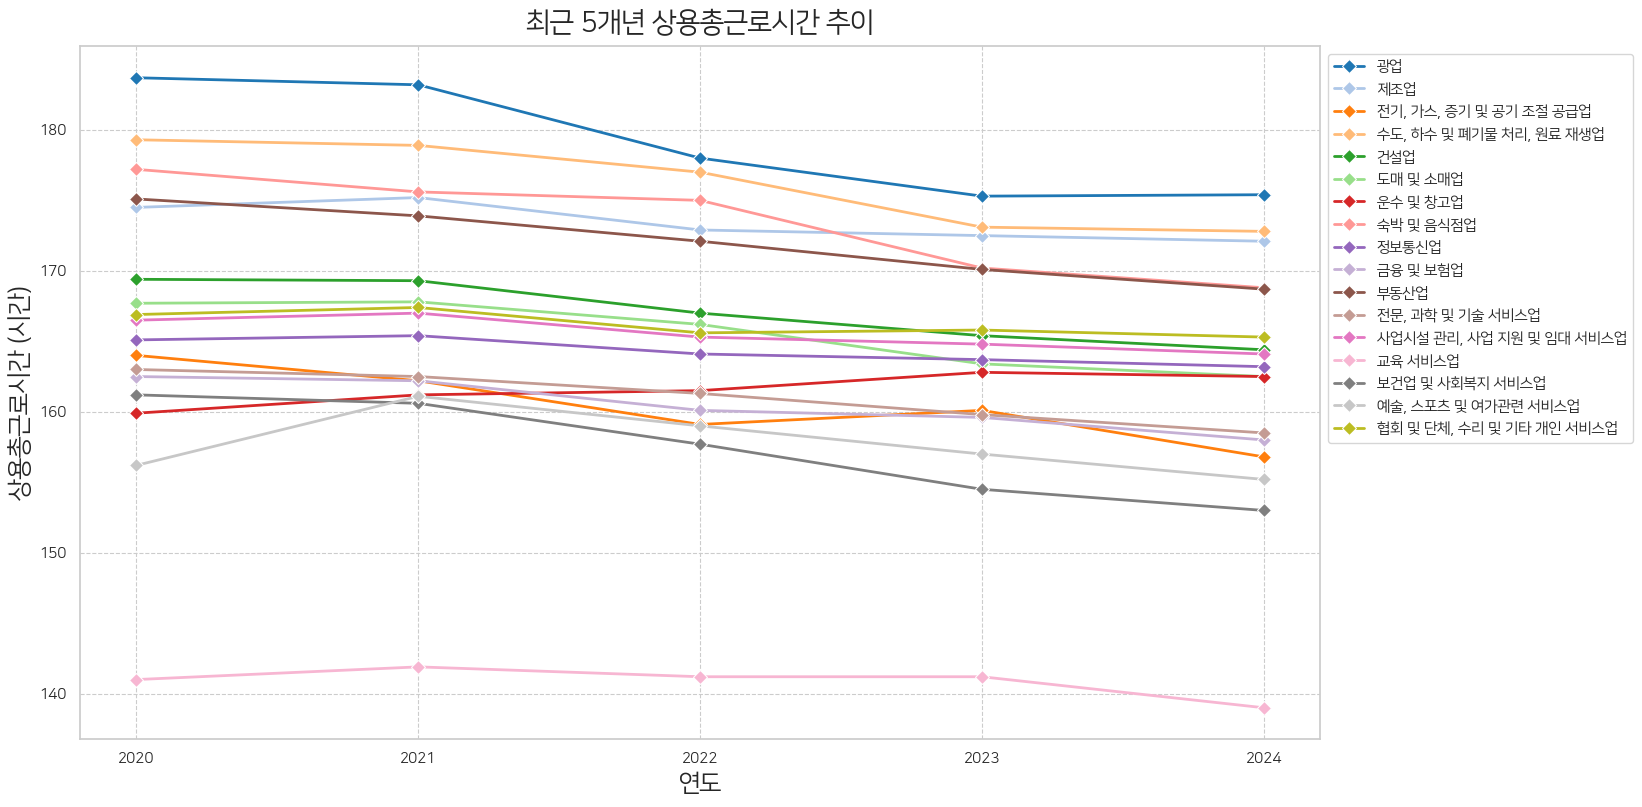

In [48]:
sns.lineplot(sangyong_work_time, x = '연도', y = '수치', hue = '산업분류', palette='tab20')
plt.title('최근 5개년 상용총근로시간 추이', y = 1.01)
plt.xlabel('연도')
plt.ylabel('상용총근로시간 (시간)')
plt.ticklabel_format(axis='y', style='plain')
plt.legend(bbox_to_anchor=(1, 1))
plt.xticks([2020, 2021, 2022, 2023, 2024]) # 얘는 왜 이걸 해줘야 년도로 나올까...
plt.show()

### 최근 5개년 평균

In [49]:
sangyong_time_mean = sangyong_work_time.groupby(['산업분류', '지표']).agg({'수치':'mean'}).reset_index()
sangyong_time_mean = sangyong_time_mean.sort_values('수치', ascending=False)
sangyong_time_mean

,산업분류,지표,수치
1,광업,상용총근로시간,179.12
8,"수도, 하수 및 폐기물 처리, 원료 재생업",상용총근로시간,176.22
15,제조업,상용총근로시간,173.44
9,숙박 및 음식점업,상용총근로시간,173.36
6,부동산업,상용총근로시간,171.98
0,건설업,상용총근로시간,167.10
16,"협회 및 단체, 수리 및 기타 개인 서비스업",상용총근로시간,166.20
7,"사업시설 관리, 사업 지원 및 임대 서비스업",상용총근로시간,165.54
4,도매 및 소매업,상용총근로시간,165.52
14,정보통신업,상용총근로시간,164.30


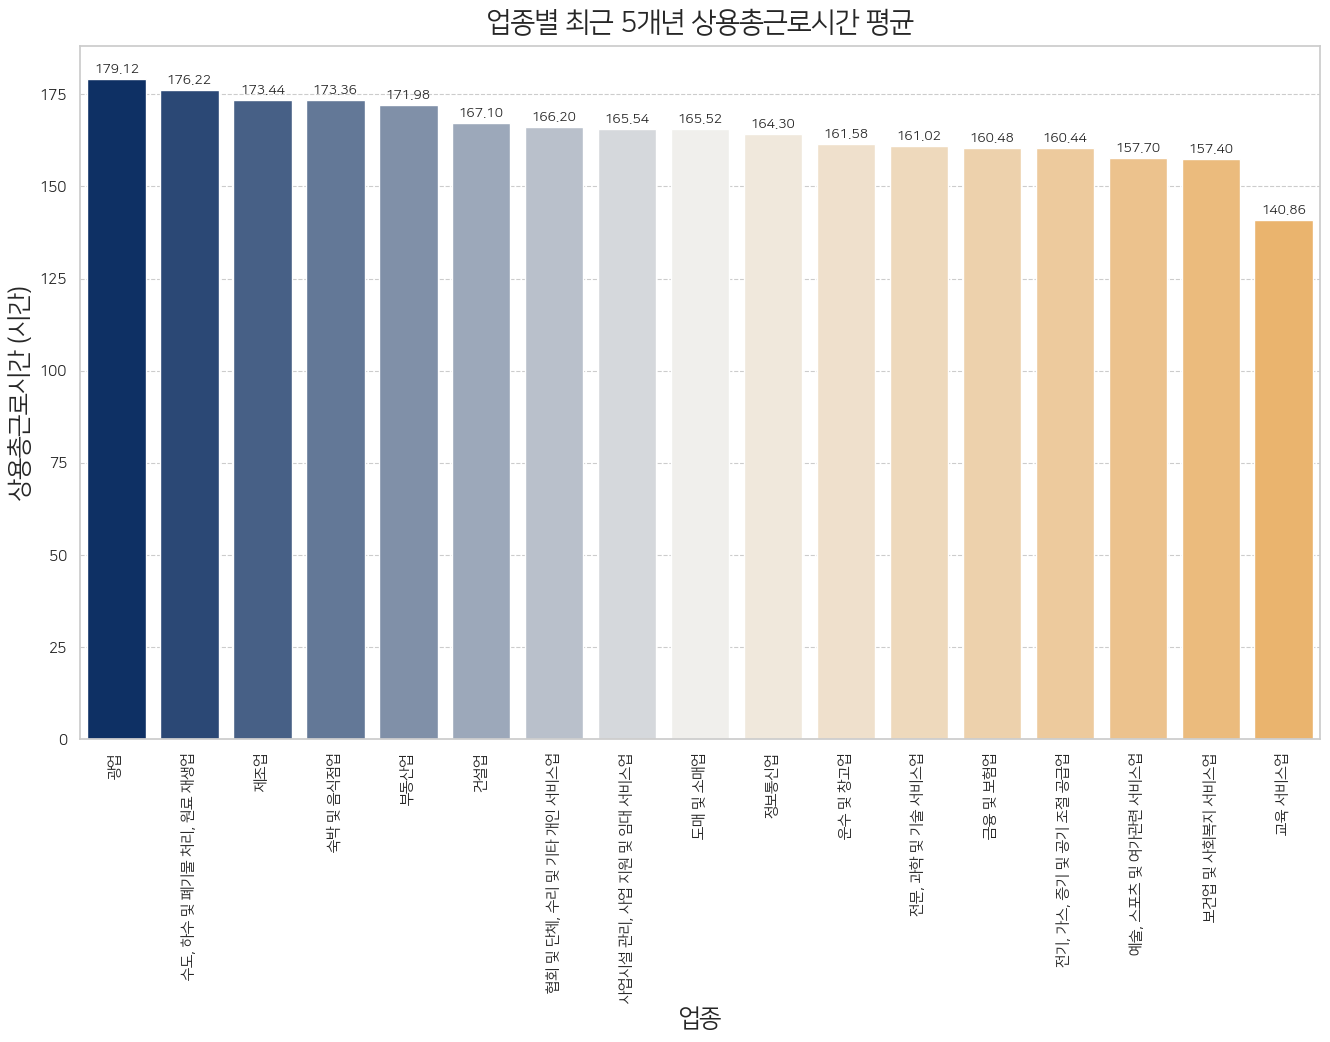

In [50]:
ax = sns.barplot(sangyong_time_mean, x = '산업분류', y = '수치', hue = '산업분류', palette=get_palette(sangyong_time_mean['산업분류'].nunique()))
for container in ax.containers:
    # fmt='%d'는 정수로 표시, label_type='edge'는 막대 끝에 표시
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# plt.axhline(np.median(sangyong_time_mean['수치']), linestyle='dashed', color='#cc0000') # 중앙값
# plt.axhline(np.mean(sangyong_time_mean['수치']), linestyle='dashed', color='#ccaa00') # 평균
plt.title('업종별 최근 5개년 상용총근로시간 평균', y = 1.01)
plt.xlabel('업종')
plt.ylabel('상용총근로시간 (시간)')
plt.ticklabel_format(axis='y', style='plain')
plt.xticks(rotation=90)
plt.show()

- 근로기준법을 위반한 건 아닌 것 같은데... 되게 많이 일하네요.
- 상용총근로시간은 일반적으로 월 209시간입니다. 

## 상용소정실근로시간

In [51]:
sangyong_real_time = payment_date.query('지표 == "상용소정실근로시간"')
sangyong_real_time

,산업분류,연도,지표,수치
91,광업,2020,상용소정실근로시간,164.1
92,제조업,2020,상용소정실근로시간,157.6
93,"전기, 가스, 증기 및 공기 조절 공급업",2020,상용소정실근로시간,154.0
94,"수도, 하수 및 폐기물 처리, 원료 재생업",2020,상용소정실근로시간,167.6
95,건설업,2020,상용소정실근로시간,163.7
...,...,...,...,...
679,"사업시설 관리, 사업 지원 및 임대 서비스업",2024,상용소정실근로시간,158.7
680,교육 서비스업,2024,상용소정실근로시간,136.1
681,보건업 및 사회복지 서비스업,2024,상용소정실근로시간,147.8
682,"예술, 스포츠 및 여가관련 서비스업",2024,상용소정실근로시간,148.1


### 최근 5개년 추이

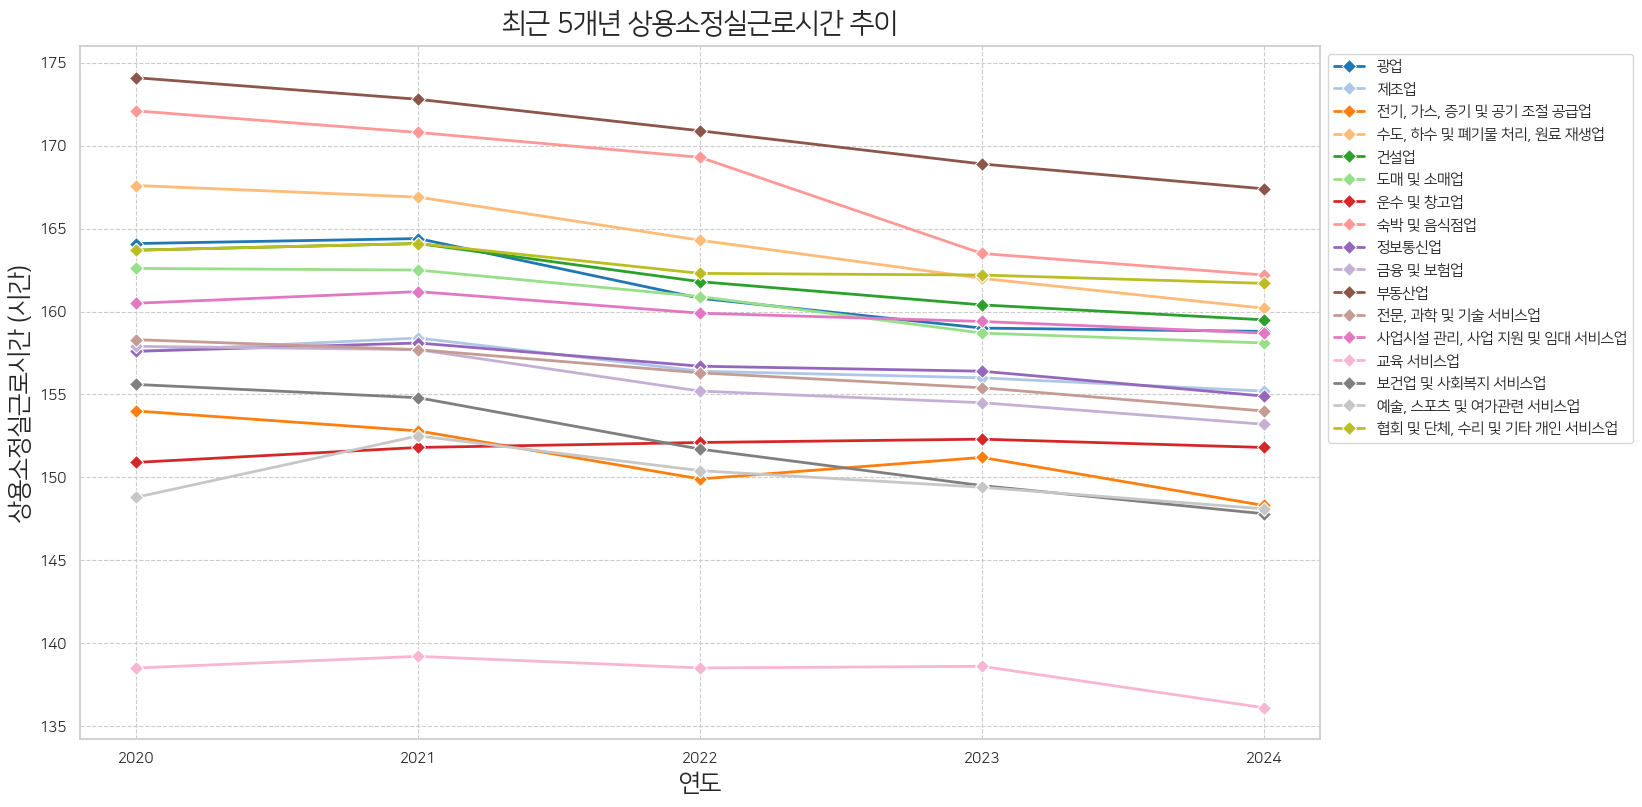

In [52]:
sns.lineplot(sangyong_real_time, x = '연도', y = '수치', hue = '산업분류', palette='tab20')
plt.title('최근 5개년 상용소정실근로시간 추이', y = 1.01)
plt.xlabel('연도')
plt.ylabel('상용소정실근로시간 (시간)')
plt.ticklabel_format(axis='y', style='plain')
plt.legend(bbox_to_anchor=(1, 1))
plt.xticks([2020, 2021, 2022, 2023, 2024]) # 얘는 왜 이걸 해줘야 년도로 나올까...
plt.show()

### 최근 5개년 평균

In [53]:
sangyong_real_mean = sangyong_real_time.groupby(['산업분류', '지표']).agg({'수치':'mean'}).reset_index()
sangyong_real_mean = sangyong_real_mean.sort_values('수치', ascending=False)
sangyong_real_mean

,산업분류,지표,수치
6,부동산업,상용소정실근로시간,170.82
9,숙박 및 음식점업,상용소정실근로시간,167.58
8,"수도, 하수 및 폐기물 처리, 원료 재생업",상용소정실근로시간,164.20
16,"협회 및 단체, 수리 및 기타 개인 서비스업",상용소정실근로시간,162.80
0,건설업,상용소정실근로시간,161.90
1,광업,상용소정실근로시간,161.42
4,도매 및 소매업,상용소정실근로시간,160.56
7,"사업시설 관리, 사업 지원 및 임대 서비스업",상용소정실근로시간,159.94
14,정보통신업,상용소정실근로시간,156.74
15,제조업,상용소정실근로시간,156.72


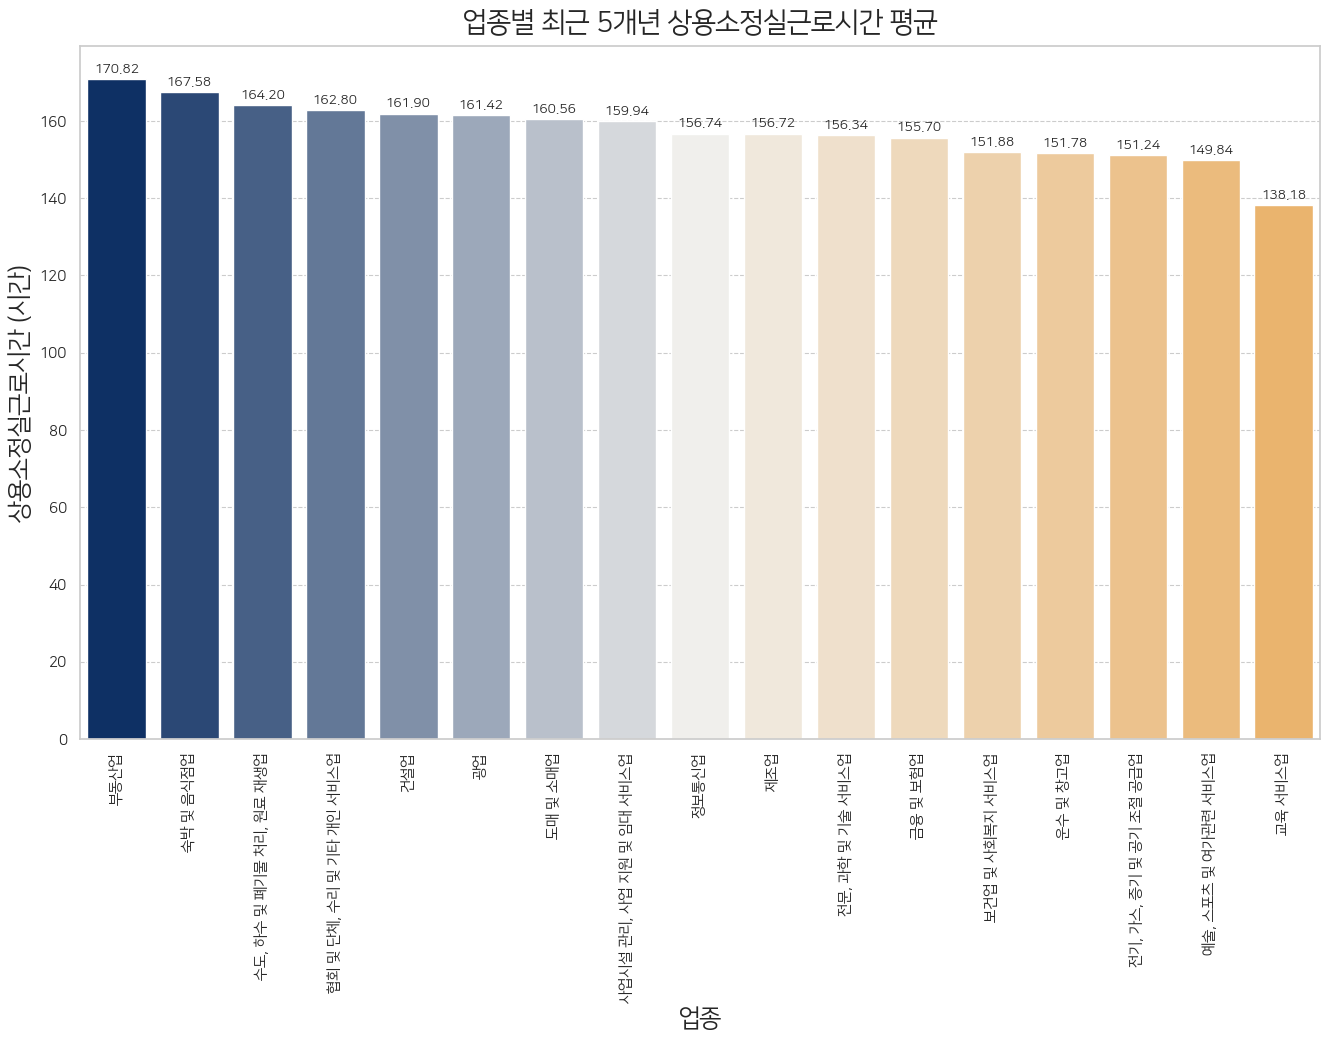

In [54]:
ax = sns.barplot(sangyong_real_mean, x = '산업분류', y = '수치', hue = '산업분류', palette=get_palette(sangyong_time_mean['산업분류'].nunique()))
for container in ax.containers:
    # fmt='%d'는 정수로 표시, label_type='edge'는 막대 끝에 표시
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# plt.axhline(np.median(sangyong_real_mean['수치']), linestyle='dashed', color='#cc0000') # 중앙값
# plt.axhline(np.mean(sangyong_real_mean['수치']), linestyle='dashed', color='#ccaa00') # 평균
plt.title('업종별 최근 5개년 상용소정실근로시간 평균', y = 1.01)
plt.xlabel('업종')
plt.ylabel('상용소정실근로시간 (시간)')
plt.ticklabel_format(axis='y', style='plain')
plt.xticks(rotation=90)
plt.show()

## 상용초과근무시간

In [55]:
sangyong_overtime = payment_date.query('지표 == "상용초과근로시간"')
sangyong_overtime

,산업분류,연도,지표,수치
109,광업,2020,상용초과근로시간,19.6
110,제조업,2020,상용초과근로시간,16.9
111,"전기, 가스, 증기 및 공기 조절 공급업",2020,상용초과근로시간,10.0
112,"수도, 하수 및 폐기물 처리, 원료 재생업",2020,상용초과근로시간,11.8
113,건설업,2020,상용초과근로시간,5.7
...,...,...,...,...
697,"사업시설 관리, 사업 지원 및 임대 서비스업",2024,상용초과근로시간,5.3
698,교육 서비스업,2024,상용초과근로시간,2.8
699,보건업 및 사회복지 서비스업,2024,상용초과근로시간,5.2
700,"예술, 스포츠 및 여가관련 서비스업",2024,상용초과근로시간,7.1


### 최근 5개년 추이

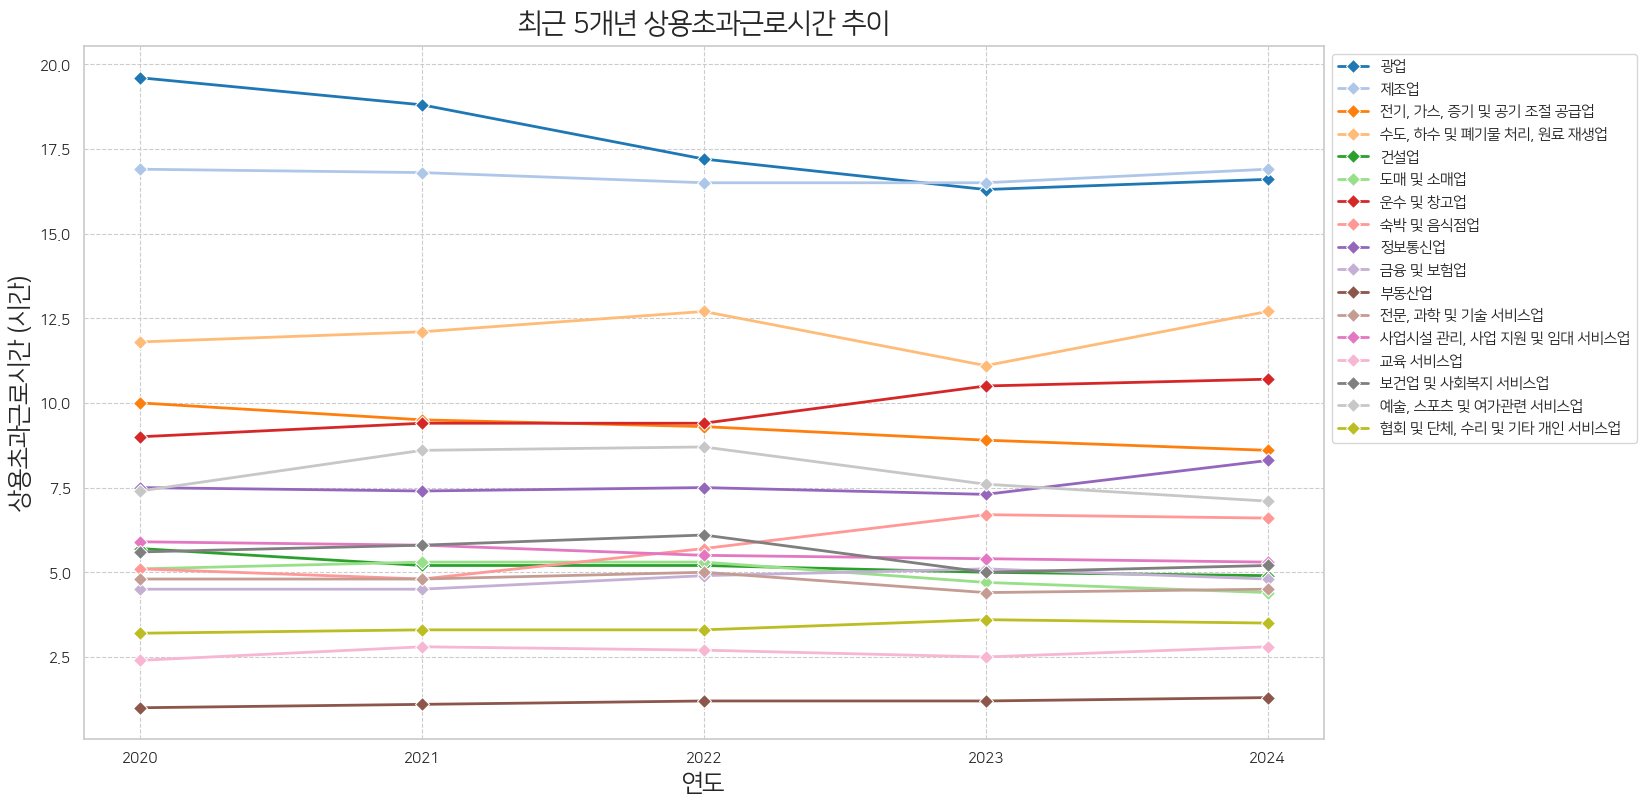

In [56]:
sns.lineplot(sangyong_overtime, x = '연도', y = '수치', hue = '산업분류', palette='tab20')
plt.title('최근 5개년 상용초과근로시간 추이', y = 1.01)
plt.xlabel('연도')
plt.ylabel('상용초과근로시간 (시간)')
plt.ticklabel_format(axis='y', style='plain')
plt.legend(bbox_to_anchor=(1, 1))
plt.xticks([2020, 2021, 2022, 2023, 2024]) # 얘는 왜 이걸 해줘야 년도로 나올까...
plt.show()

- 양상이 업계바이 업계인데, 우상향하는 업종들이 조금씩 보입니다. 

### 최근 5개년 평균

In [57]:
sangyong_overtime_mean = sangyong_overtime.groupby(['산업분류', '지표']).agg({'수치':'mean'}).reset_index()
sangyong_overtime_mean = sangyong_overtime_mean.sort_values('수치', ascending=False)
sangyong_overtime_mean

,산업분류,지표,수치
1,광업,상용초과근로시간,17.70
15,제조업,상용초과근로시간,16.72
8,"수도, 하수 및 폐기물 처리, 원료 재생업",상용초과근로시간,12.08
11,운수 및 창고업,상용초과근로시간,9.80
12,"전기, 가스, 증기 및 공기 조절 공급업",상용초과근로시간,9.26
10,"예술, 스포츠 및 여가관련 서비스업",상용초과근로시간,7.88
14,정보통신업,상용초과근로시간,7.60
9,숙박 및 음식점업,상용초과근로시간,5.78
7,"사업시설 관리, 사업 지원 및 임대 서비스업",상용초과근로시간,5.58
5,보건업 및 사회복지 서비스업,상용초과근로시간,5.54


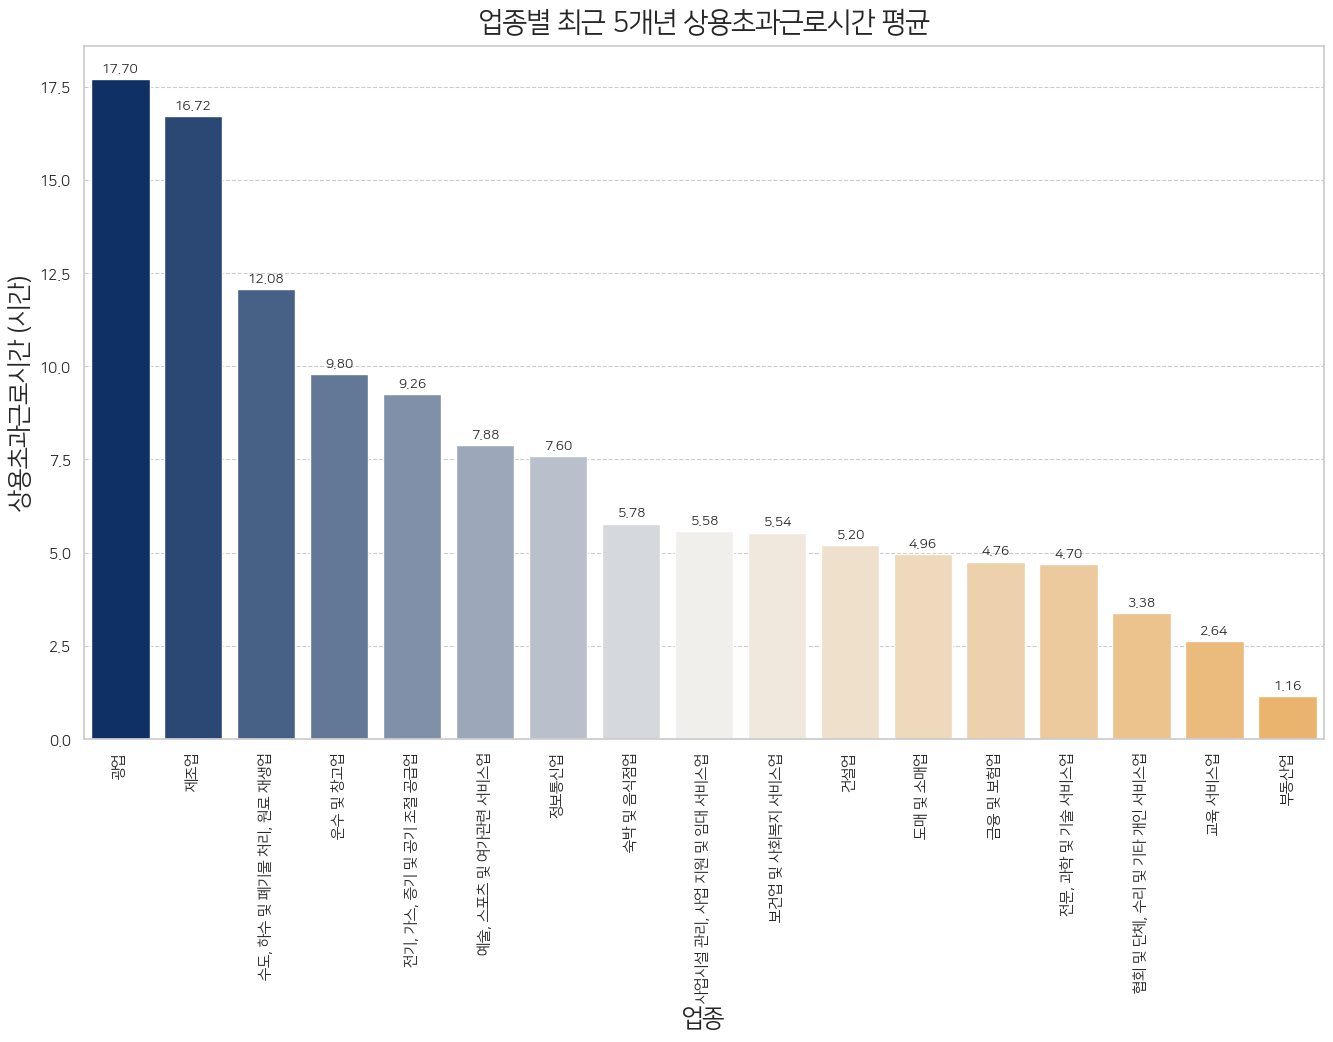

In [58]:
ax = sns.barplot(sangyong_overtime_mean, x = '산업분류', y = '수치', hue = '산업분류', palette=get_palette(sangyong_overtime_mean['산업분류'].nunique()))
for container in ax.containers:
    # fmt='%d'는 정수로 표시, label_type='edge'는 막대 끝에 표시
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# plt.axhline(np.median(sangyong_overtime_mean['수치']), linestyle='dashed', color='#cc0000') # 중앙값
# plt.axhline(np.mean(sangyong_overtime_mean['수치']), linestyle='dashed', color='#ccaa00') # 평균
plt.title('업종별 최근 5개년 상용초과근로시간 평균', y = 1.01)
plt.xlabel('업종')
plt.ylabel('상용초과근로시간 (시간)')
plt.ticklabel_format(axis='y', style='plain')
plt.xticks(rotation=90)
plt.show()

- 이 업계는 초과근로가 없으면 돌아가지 아니하는것인가...

### 멘-켄달 검정 (mann-kendall test)
- 찾아보니 웬 꼬부랑글씨가 저를 반기는게 아... 이거 공부하기 빡시겠습니다그려... 그래도 해야죠. 내가 뭘 분석하는지는 알고 해야 하니까요.
- 일단 이 검정으로 뭘 볼거냐... 제조업의 초과근로시간이 우상향인지를 볼 겁니다. 왜냐고요? 이걸 하는 목적이 시간에 따라 이 데이터가 감소하는지, 증가하는지 여부거든요. n수가 얼마 안 돼서 비모수로 빠져야되는데 마침 이것도 비모수검정입니다.
- 그럼 어떻게 하는건지, 결과를 어떻게 해석하는건지 직접 한번 보시죠. 

In [59]:
# 제조업 근로시간만 따로 빼보겠습니다
# ot: overtime(초과근무)
manufacture_ot = sangyong_overtime.query('산업분류 == "제조업"')
manufacture_ot

,산업분류,연도,지표,수치
110,제조업,2020,상용초과근로시간,16.9
254,제조업,2021,상용초과근로시간,16.8
398,제조업,2022,상용초과근로시간,16.5
542,제조업,2023,상용초과근로시간,16.5
686,제조업,2024,상용초과근로시간,16.9


In [60]:
# Mann-Kendall 검정
result = mk.original_test(manufacture_ot['수치'])

print(f"추세 방향: {result.trend}")        # increasing / decreasing / no trend
print(f"p-value : {result.p:.4f}")         # 0.05 미만이면 유의미
print(f"Kendall τ: {result.Tau:.4f}")      # 양수=우상향, 음수=우하향
print(f"Sen's Slope: {result.slope:.4f}") # 연간 평균 변화량

추세 방향: no trend
p-value : 0.7940
Kendall τ: -0.2000
Sen's Slope: -0.0500


- 뭐야, 이건? 맨-켄달 검정의 결과지요. 일단 하나씩 봅시다...
#### 가설
1. 귀무가설(H0): 제조업의 상용초과근로시간 추이에는 추세가 없다 (랜덤)
2. 대립가설(H1): 제조업의 상용초과근로시간 추이에는 단조 증가 또는 감소 추세가 있다

#### 근데 피밸류가 아
1. P-value: 많이 보셨을 유의수준입니다.
2. 켄달타우: 양수면 우상향, 음수면 우하향입니다. 어? 이거 상관계수? 그죠, 상관분석 중에도 켄달타우라고 있긴 합니다.
3. 센의 기울기: 그래서 방향은 알겠는데 얼마나 변화함?

인데 아... 피밸류 아... 

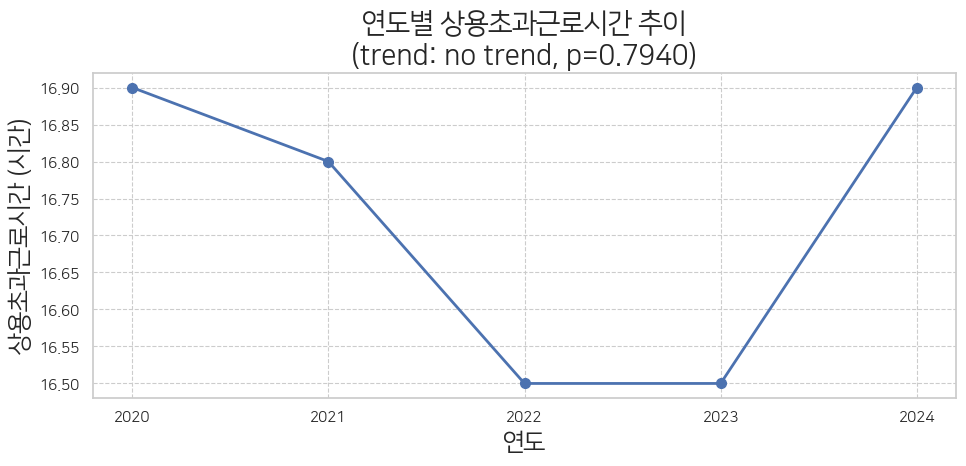

In [61]:
# 시각화
plt.figure(figsize=(10, 5))
plt.plot(manufacture_ot['연도'], manufacture_ot['수치'], marker='o', label='근로시간')
plt.title(f"연도별 상용초과근로시간 추이\n(trend: {result.trend}, p={result.p:.4f})")
plt.xlabel("연도")
plt.ylabel("상용초과근로시간 (시간)")
plt.xticks([2020, 2021, 2022, 2023, 2024])
plt.grid(True)
plt.tight_layout()
plt.show()

- 내가 이걸 먼저 했어야 했는데... 보시면 2020년부터 2022년까지는 떨어지고, 2023년부터 정체됐다가 2024년에 쭉 올라가죠?
- 사실 피밸류가 저렇게 나왔다고 해서 망했다... 수준은 아니고. 표본을 좀 더 확보해야 합니다... 최근 한 10년치는 있어야 좀 할먼해요.

### 리니어 리그레숑(선형회귀) 추세선 기울기 보기

In [62]:
year = manufacture_ot['연도']
hours = manufacture_ot['수치']
slope, intercept, r_value, p_value, std_err = stats.linregress(year, hours)

In [63]:
print(f"기울기(slope)  : {slope:.4f}")      # 양수=우상향, 음수=우하향
print(f"p-value        : {p_value:.4f}")    # 0.05 미만이면 유의미
print(f"R²             : {r_value**2:.4f}") # 1에 가까울수록 선형 설명력 높음

기울기(slope)  : -0.0300
p-value        : 0.7080
R²             : 0.0536


- 씁... 이 정도면 뭘로 분석해도 결론이 제대로 안 나옵니다. 애초에 표본 수가 너무 적어요... 그래서 결론은 뭐냐.
1. 애초에 표본 수가 5개밖에 안 됨(최근 5개년 평균)->표본 수가 제한되어 검정력이 충분하지 않았다
2. 그래서 통계분석을 해도 유의미한 결과가 안 나온다.

이렇게 되겠네요. 얘는 근데 최근 10개년으로 하려면 표 콩캣해야한다는...

## 구성비...가...의미가 있나?
> 상용총근로시간=상용소정실근로시간+상용초과근로시간

In [64]:
# 위 등식에 들어가는 요소들만 추출
jipyo_list = ['상용총근로시간','상용소정실근로시간', '상용초과근로시간']
payment_time_ratio = payment_date.query('지표 in @jipyo_list')

payment_time_ratio

,산업분류,연도,지표,수치
73,광업,2020,상용총근로시간,183.7
74,제조업,2020,상용총근로시간,174.5
75,"전기, 가스, 증기 및 공기 조절 공급업",2020,상용총근로시간,164.0
76,"수도, 하수 및 폐기물 처리, 원료 재생업",2020,상용총근로시간,179.3
77,건설업,2020,상용총근로시간,169.4
...,...,...,...,...
697,"사업시설 관리, 사업 지원 및 임대 서비스업",2024,상용초과근로시간,5.3
698,교육 서비스업,2024,상용초과근로시간,2.8
699,보건업 및 사회복지 서비스업,2024,상용초과근로시간,5.2
700,"예술, 스포츠 및 여가관련 서비스업",2024,상용초과근로시간,7.1


In [65]:
# 이거 최근 5개년이라서 묶고 평균좀 낼게용
payment_time_ratio = payment_time_ratio.groupby(['산업분류','지표']).agg({'수치':'mean'}).reset_index()
payment_time_ratio

,산업분류,지표,수치
0,건설업,상용소정실근로시간,161.90
1,건설업,상용초과근로시간,5.20
2,건설업,상용총근로시간,167.10
3,광업,상용소정실근로시간,161.42
4,광업,상용초과근로시간,17.70
5,광업,상용총근로시간,179.12
6,교육 서비스업,상용소정실근로시간,138.18
7,교육 서비스업,상용초과근로시간,2.64
8,교육 서비스업,상용총근로시간,140.86
9,금융 및 보험업,상용소정실근로시간,155.70


### 펴주기

In [66]:
payment_time_ratio_wide = pd.pivot_table(payment_time_ratio, index=['산업분류'], columns='지표', values='수치').reset_index()

payment_time_ratio_wide['상용소정실근로시간비'] = payment_time_ratio_wide['상용소정실근로시간'] / payment_time_ratio_wide['상용총근로시간'] * 100
payment_time_ratio_wide['상용초과근로시간비'] = payment_time_ratio_wide['상용초과근로시간'] / payment_time_ratio_wide['상용총근로시간'] * 100

# 예 나왔습니다 예
payment_time_ratio_wide

지표,산업분류,상용소정실근로시간,상용초과근로시간,상용총근로시간,상용소정실근로시간비,상용초과근로시간비
0,건설업,161.90,5.20,167.10,96.888091,3.111909
1,광업,161.42,17.70,179.12,90.118356,9.881644
2,교육 서비스업,138.18,2.64,140.86,98.097402,1.874201
3,금융 및 보험업,155.70,4.76,160.48,97.021436,2.966102
4,도매 및 소매업,160.56,4.96,165.52,97.003383,2.996617
5,보건업 및 사회복지 서비스업,151.88,5.54,157.40,96.493011,3.519695
6,부동산업,170.82,1.16,171.98,99.325503,0.674497
7,"사업시설 관리, 사업 지원 및 임대 서비스업",159.94,5.58,165.54,96.617132,3.370787
8,"수도, 하수 및 폐기물 처리, 원료 재생업",164.20,12.08,176.22,93.178981,6.855068
9,숙박 및 음식점업,167.58,5.78,173.36,96.665898,3.334102


In [67]:
# 근데 이걸 왜 또 녹이는건지는 묻지 맙시다
plot_df2 = payment_time_ratio_wide.melt(
    id_vars=['산업분류'],
    value_vars=['상용소정실근로시간비', '상용초과근로시간비'],
    var_name='항목',
    value_name='구성비'
)

plot_df2

,산업분류,항목,구성비
0,건설업,상용소정실근로시간비,96.888091
1,광업,상용소정실근로시간비,90.118356
2,교육 서비스업,상용소정실근로시간비,98.097402
3,금융 및 보험업,상용소정실근로시간비,97.021436
4,도매 및 소매업,상용소정실근로시간비,97.003383
5,보건업 및 사회복지 서비스업,상용소정실근로시간비,96.493011
6,부동산업,상용소정실근로시간비,99.325503
7,"사업시설 관리, 사업 지원 및 임대 서비스업",상용소정실근로시간비,96.617132
8,"수도, 하수 및 폐기물 처리, 원료 재생업",상용소정실근로시간비,93.178981
9,숙박 및 음식점업,상용소정실근로시간비,96.665898


### 시각화 드가즈아!

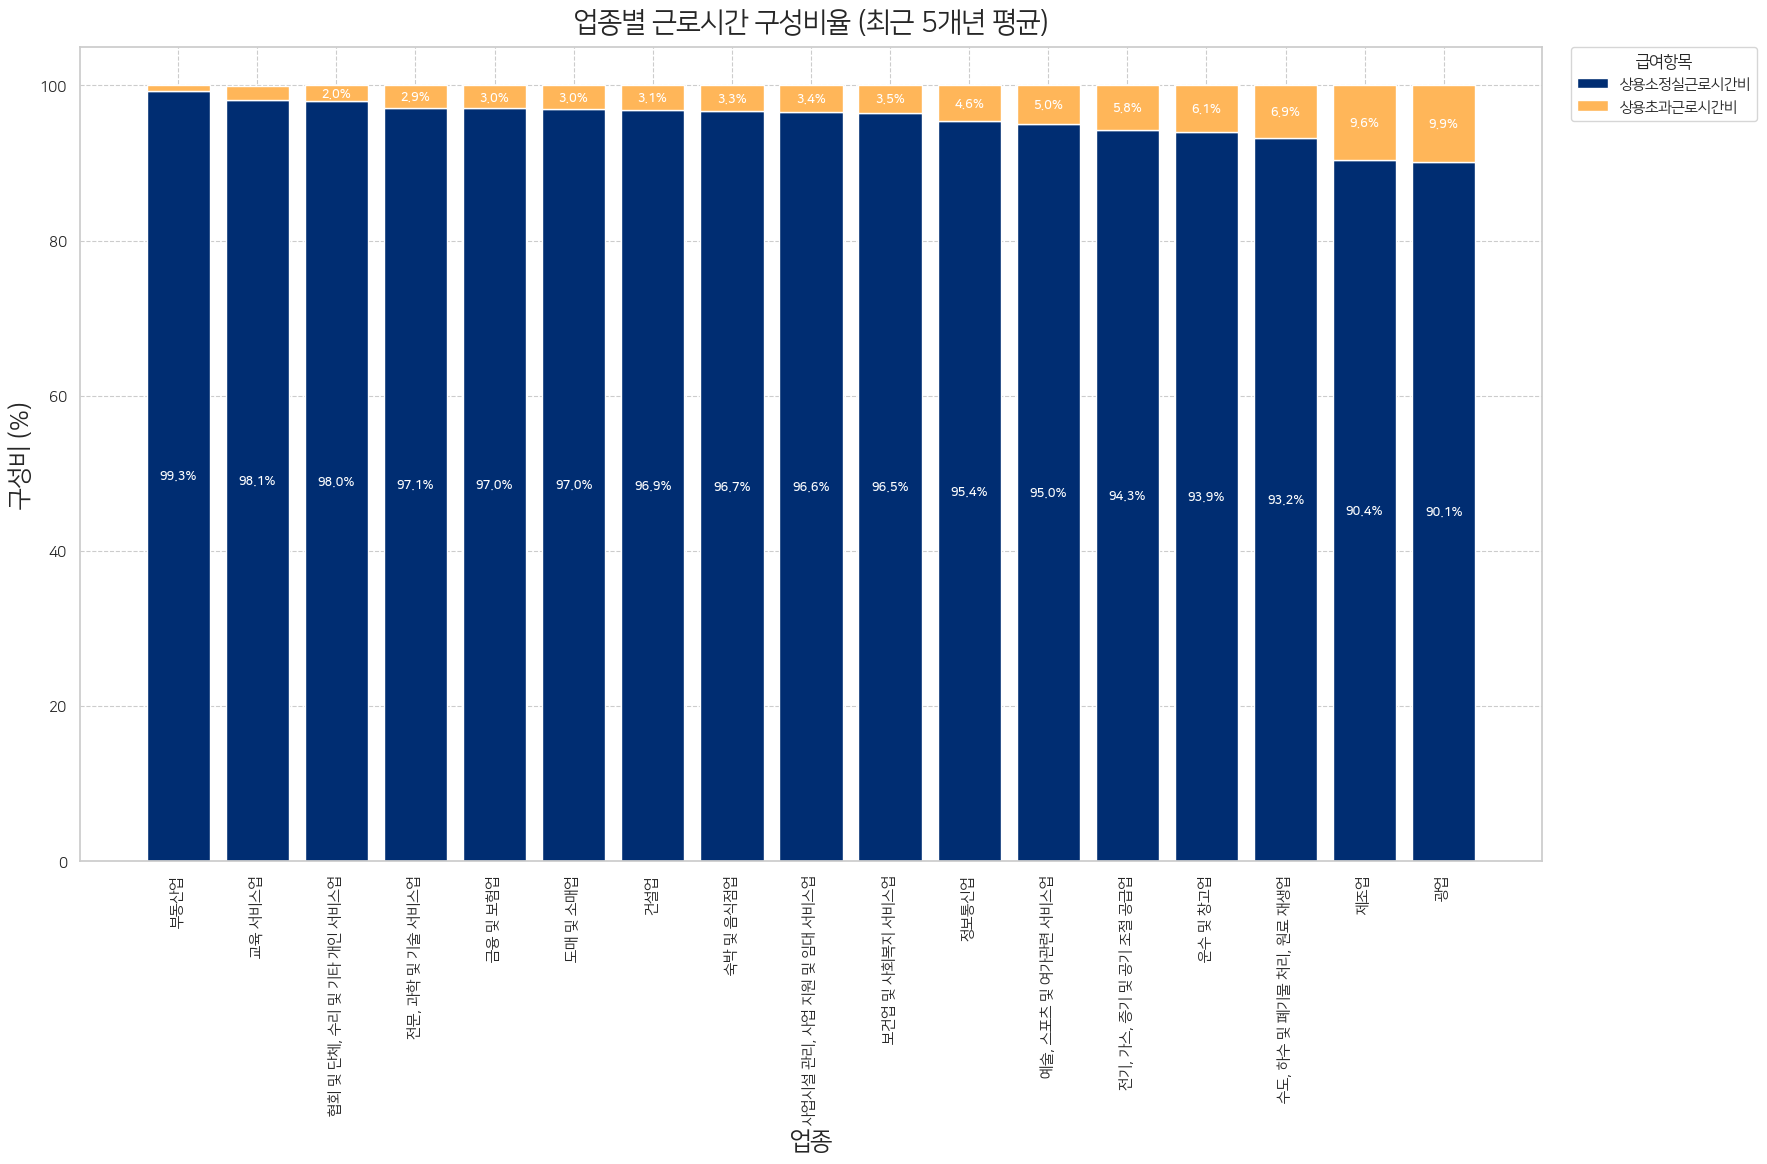

In [68]:
my_order = ['상용소정실근로시간비', '상용초과근로시간비']

order = (plot_df2[plot_df2['항목'] == '상용소정실근로시간비']
         .sort_values('구성비', ascending=False)['산업분류'].tolist())

industries = order  # 업종 목록

colors = [custom_cmap_dark(0.0), custom_cmap_dark(1.0)]

fig, ax = plt.subplots(figsize=(18, 12))

x = np.arange(len(industries))
width = 0.8

bottoms = np.zeros(len(industries))

for i, item in enumerate(my_order):
    values = []
    for ind in industries:
        val = plot_df2[(plot_df2['산업분류'] == ind) & (plot_df2['항목'] == item)]['구성비'].values
        values.append(val[0] if len(val) > 0 else 0)
    values = np.array(values)

    bars = ax.bar(x, values, width=width, bottom=bottoms, color=colors[i], label=item)

    # 텍스트 레이블
    for j, (bar, v) in enumerate(zip(bars, values)):
        if v > 2.0:
            ax.text(bar.get_x() + bar.get_width()/2, bottoms[j] + v/2,
                    f'{v:.1f}%', ha='center', va='center', color='white', fontsize=9, fontweight='bold')

    bottoms += values

ax.set_xticks(x)
ax.set_xticklabels(industries, rotation=90)
ax.set_title('업종별 근로시간 구성비율 (최근 5개년 평균)', y=1.01)
ax.set_xlabel('업종')
ax.set_ylabel('구성비 (%)')
ax.legend(title='급여항목', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

- 아이고... 초과근로시간비가 뒤에서 2등이네...

# 제조업 발골

In [69]:
manu_date = payment_date.query('산업분류 == "제조업"')
manu_money = payment_money.query('산업분류 == "제조업"')
manu_money

,산업분류,연도,지표,비용,비용(만원)
2,제조업,2020,전체임금총액,3990086.0,399.01
20,제조업,2020,상용임금총액,4058423.0,405.84
38,제조업,2020,상용정액급여,3090580.0,309.06
56,제조업,2020,상용초과급여,382741.0,38.27
74,제조업,2020,상용특별급여,585102.0,58.51
92,제조업,2020,임시일용임금총액,1736811.0,173.68
110,제조업,2021,전체임금총액,4238595.0,423.86
128,제조업,2021,상용임금총액,4310740.0,431.07
146,제조업,2021,상용정액급여,3212377.0,321.24
164,제조업,2021,상용초과급여,397766.0,39.78


In [70]:
manu_date

,산업분류,연도,지표,수치
2,제조업,2020,전체근로일수,20.2
20,제조업,2020,상용근로일수,20.4
38,제조업,2020,임시일용근로일수,14.1
56,제조업,2020,전체근로시간,172.7
74,제조업,2020,상용총근로시간,174.5
92,제조업,2020,상용소정실근로시간,157.6
110,제조업,2020,상용초과근로시간,16.9
128,제조업,2020,임시일용근로시간,113.9
146,제조업,2021,전체근로일수,20.4
164,제조업,2021,상용근로일수,20.5


- 이건 어떻게 그릴지 생각을 좀 더 해봐야겠습니다. 일단 추이는 필요한 것만 그려야지 안그러면 y축 박살나서 대참사 터져요.

## 상용임금총액 현황-제조업

In [71]:
pd.pivot_table(manu_money, index = ['산업분류', '연도'], columns = '지표', values='비용(만원)')

지표         상용임금총액  상용정액급여  상용초과급여  상용특별급여  임시일용임금총액  전체임금총액
산업분류 연도                                                    
제조업  2020  405.84  309.06   38.27   58.51    173.68  399.01
     2021  431.07  321.24   39.78   70.06    194.96  423.86
     2022  456.57  336.71   41.63   78.24    209.23  448.39
     2023  471.42  350.93   43.83   76.66    218.59  463.27
     2024  483.91  363.29   46.89   73.72    228.43  475.48

- 상용임금총액: 근로계약서 쓰고 일하는 사람들(항상 사직서를 품고 다니시는...)
- 임시일용임금총액: 일용직으로 일하는 사람들

이 받는 돈입니다.

In [72]:
sangyong_money = manu_money.query('지표 == "상용임금총액"') # 상용임금총액
template_money = manu_money.query('지표 == "임시일용임금총액"')

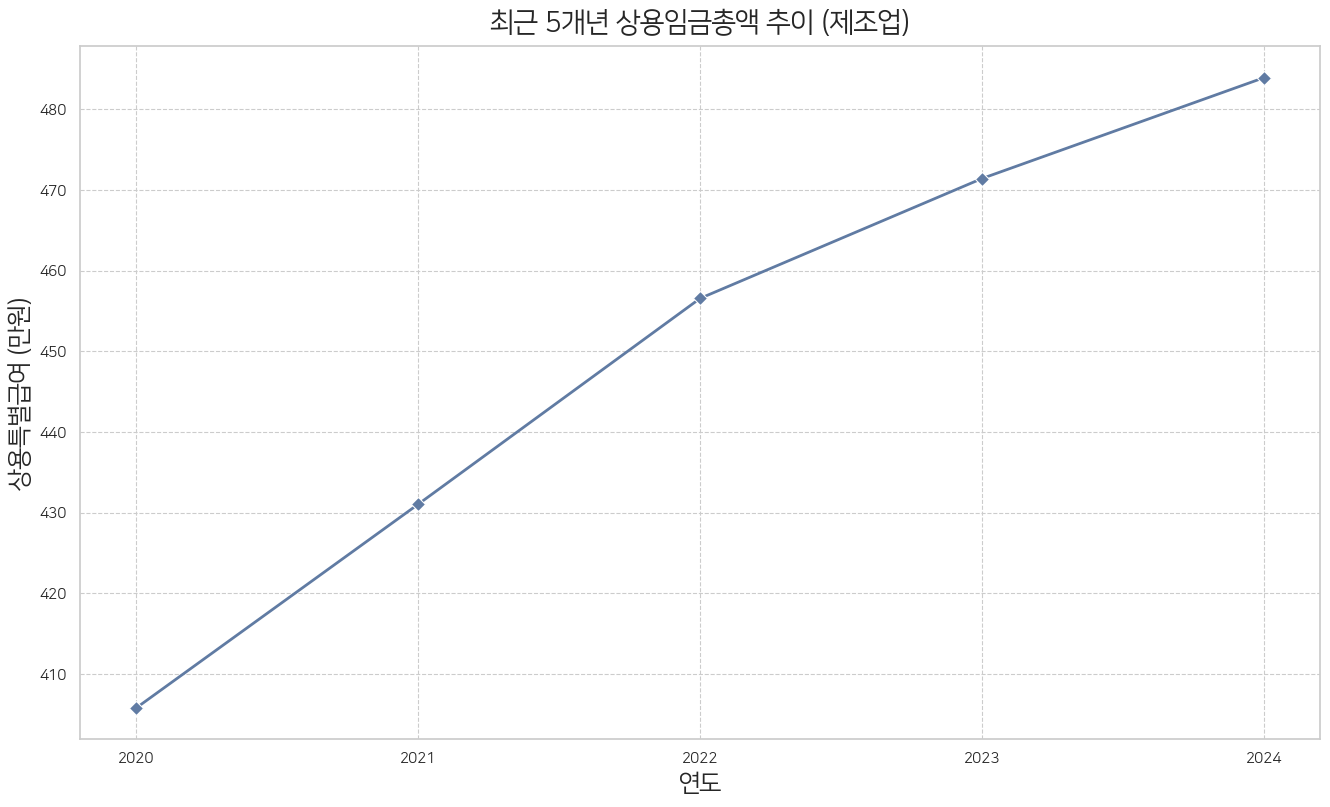

In [73]:
sns.lineplot(sangyong_money, x = '연도', y = '비용(만원)', color=custom_cmap(0.2))
plt.title('최근 5개년 상용임금총액 추이 (제조업)', y = 1.01)
plt.xlabel('연도')
plt.ylabel('상용특별급여 (만원)')
plt.ticklabel_format(axis='y', style='plain')
plt.xticks([2020, 2021, 2022, 2023, 2024]) # 얘는 왜 이걸 해줘야 년도로 나올까...
plt.show()

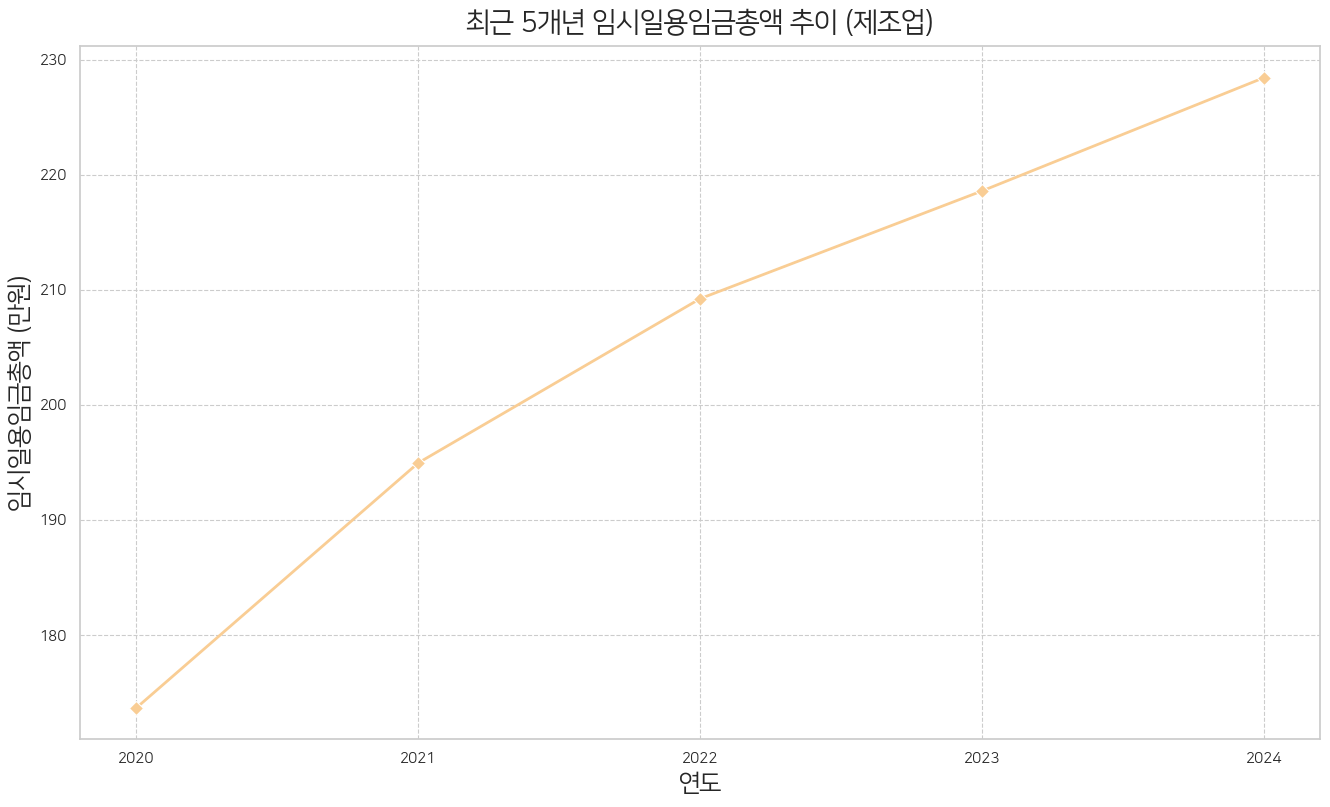

In [74]:
sns.lineplot(template_money, x = '연도', y = '비용(만원)', color=custom_cmap(0.8))
plt.title('최근 5개년 임시일용임금총액 추이 (제조업)', y = 1.01)
plt.xlabel('연도')
plt.ylabel('임시일용임금총액 (만원)')
plt.ticklabel_format(axis='y', style='plain')
plt.xticks([2020, 2021, 2022, 2023, 2024]) # 얘는 왜 이걸 해줘야 년도로 나올까...
plt.show()

- 상용임금총액은 2022년을 기점으로 증가폭이 소폭 감소했습니다.
- 임시일용임금총액은 음... 21년, 22년에 미묘하게 두번 꺾였네요. 

### 씁 이거 통계분석이 될라나

In [75]:
# Mann-Kendall 검정
result = mk.original_test(sangyong_money['비용'])

print(f"추세 방향: {result.trend}")        # increasing / decreasing / no trend
print(f"p-value : {result.p:.4f}")         # 0.05 미만이면 유의미
print(f"Kendall τ: {result.Tau:.4f}")      # 양수=우상향, 음수=우하향
print(f"Sen's Slope: {result.slope:.4f}") # 연간 평균 변화량

추세 방향: increasing
p-value : 0.0275
Kendall τ: 1.0000
Sen's Slope: 198456.0000


In [76]:
# Mann-Kendall 검정
result = mk.original_test(template_money['비용'])

print(f"추세 방향: {result.trend}")        # increasing / decreasing / no trend
print(f"p-value : {result.p:.4f}")         # 0.05 미만이면 유의미
print(f"Kendall τ: {result.Tau:.4f}")      # 양수=우상향, 음수=우하향
print(f"Sen's Slope: {result.slope:.4f}") # 연간 평균 변화량

추세 방향: increasing
p-value : 0.0275
Kendall τ: 1.0000
Sen's Slope: 127506.2500


- 왜 됨?
- 이게 데이터가 다섯개뿐이라 하나만 튀어도 p-value가 훅 올라가버리거든요. 그럼에도 이렇게 나왔다는 건 일정하게 올라갔다는 얘기입니다.
- 물론 표본이 작기떄문에 딱 이렇다! 라고 말하기는 애매~한 사안이긴 합니다...

### 전년도 대비 증감률

In [77]:
sangyong_money = sangyong_money.copy()
sangyong_money

,산업분류,연도,지표,비용,비용(만원)
20,제조업,2020,상용임금총액,4058423.0,405.84
128,제조업,2021,상용임금총액,4310740.0,431.07
236,제조업,2022,상용임금총액,4565743.0,456.57
344,제조업,2023,상용임금총액,4714235.0,471.42
452,제조업,2024,상용임금총액,4839081.0,483.91


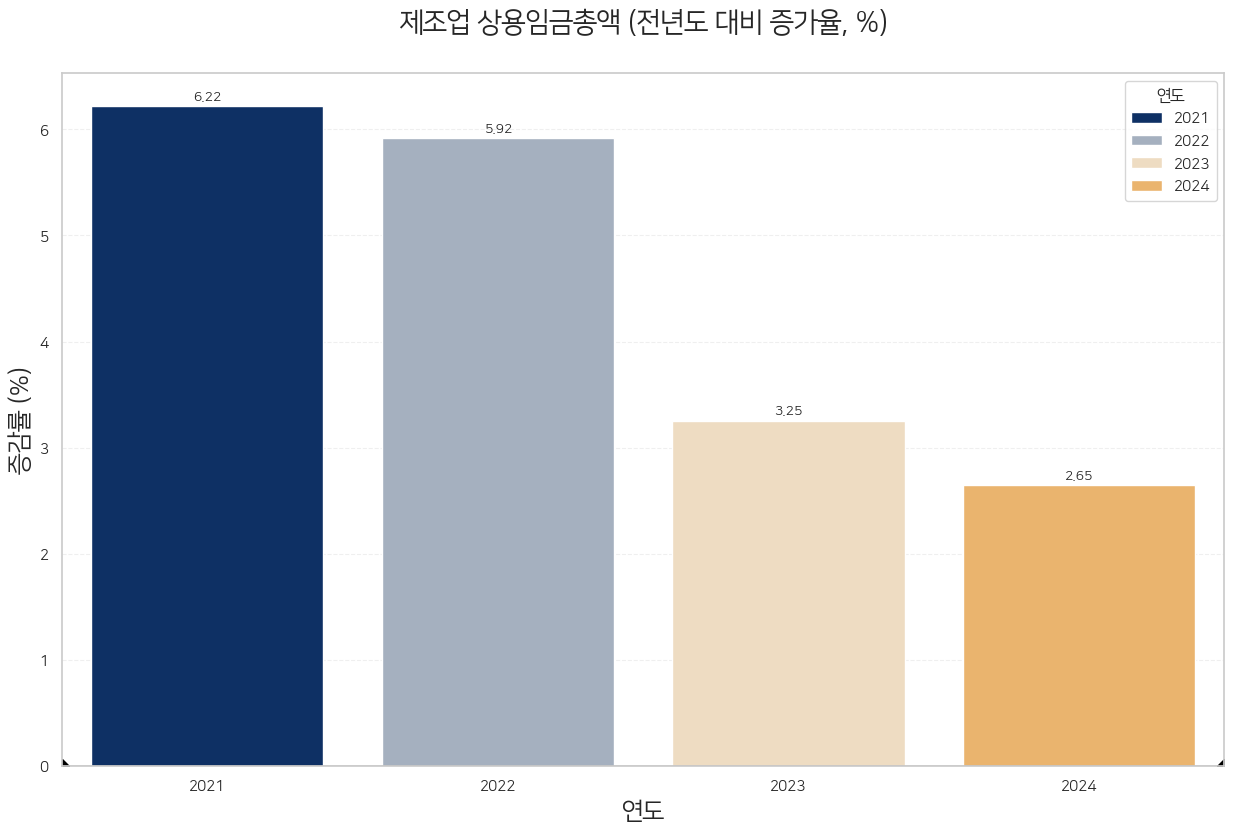

In [78]:
sangyong_money['증감률'] = sangyong_money.groupby('지표')['비용'].pct_change() * 100

# 3. 그래프 시각화 (첫 해인 2020년은 데이터가 NaN이므로 2021년부터 표시됨)
plt.figure(figsize=(15, 9))
ax = sns.barplot(data=sangyong_money.dropna(), x='연도', y='증감률', hue = '연도', palette=custom_cmap)

for container in ax.containers:
    # fmt='%d'는 정수로 표시, label_type='edge'는 막대 끝에 표시
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)
# 0% 기준선 (이보다 위면 상승, 아래면 하락)
# 이게 근데 필요가 있나...?
plt.axhline(0, color='black', linewidth=1)

plt.title('제조업 상용임금총액 (전년도 대비 증가율, %)', y=1.05)
plt.ylabel('증감률 (%)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## 상용정액급여, 상용초과급여, 상용특별급여

In [79]:
# 3개로 필터링
jipyo = ['상용정액급여']
jipyo_list = ['상용초과급여', '상용특별급여']
salary_filter = manu_money.query('지표 in @jipyo').copy()
triple_filter = manu_money.query('지표 in @jipyo_list').copy()

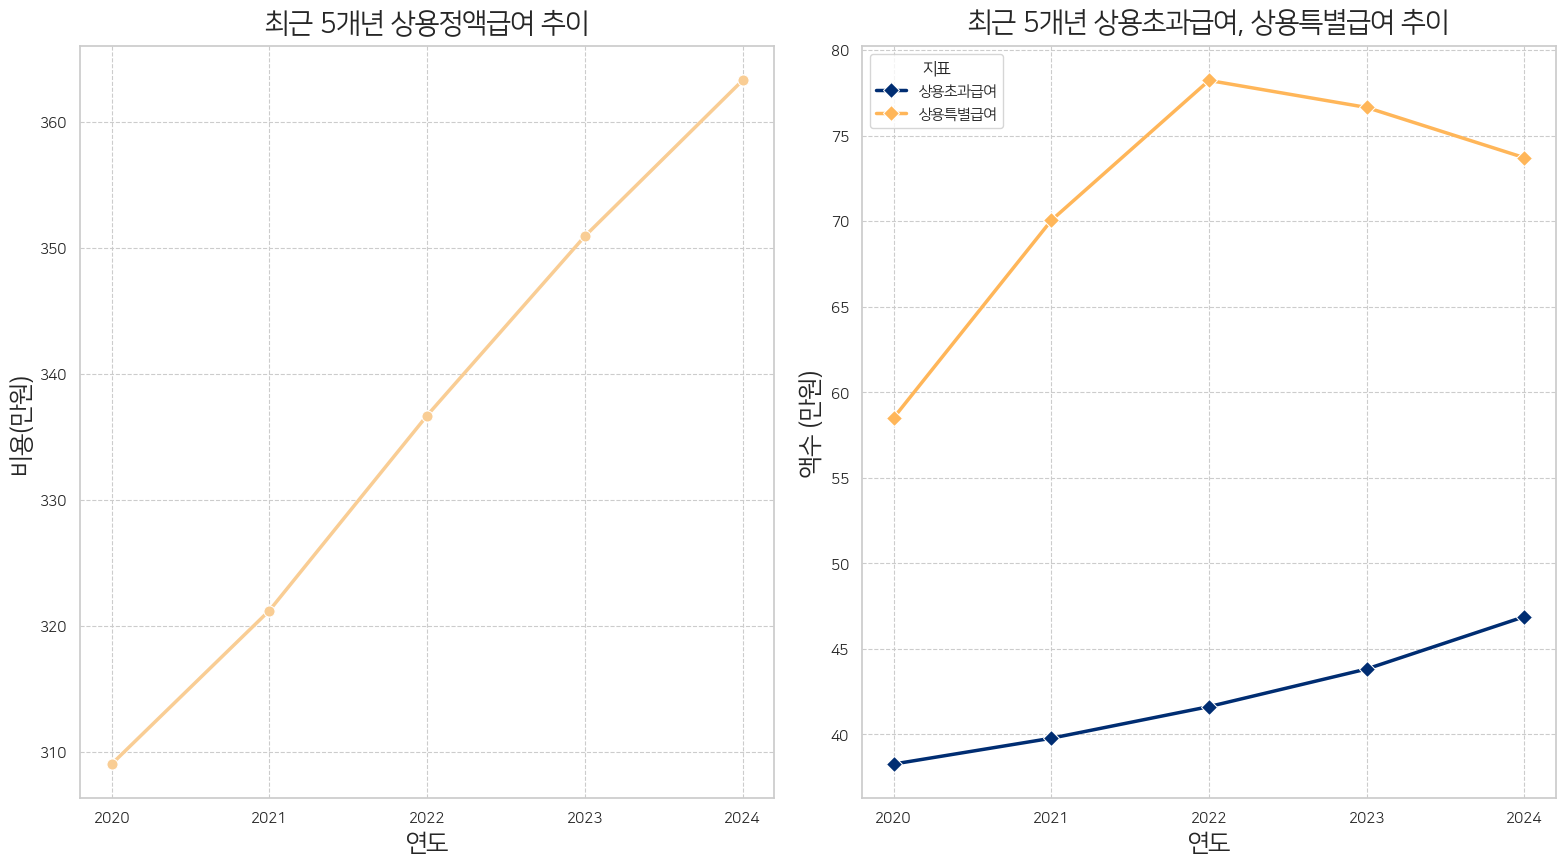

In [80]:
fig, ax = plt.subplots(1, 2)

ax[0] = sns.lineplot(data=salary_filter, x='연도', y='비용(만원)', marker='o', markersize=8, linewidth=2.5, color=custom_cmap(0.8), ax = ax[0])
ax[1] = sns.lineplot(data=triple_filter, x='연도', y='비용(만원)', hue='지표', marker='D', markersize=8, linewidth=2.5, palette=get_palette(len(jipyo_list)), ax = ax[1])

ax[0].set_title('최근 5개년 상용정액급여 추이', y = 1.01)
ax[1].set_title('최근 5개년 상용초과급여, 상용특별급여 추이', y = 1.01)
plt.xlabel('연도')
plt.ylabel('액수 (만원)')

ax[0].ticklabel_format(axis='y', style='plain')
ax[1].ticklabel_format(axis='y', style='plain')
ax[0].set_xticks([2020, 2021, 2022, 2023, 2024]) # 얘는 왜 이걸 해줘야 년도로 나올까...
ax[1].set_xticks([2020, 2021, 2022, 2023, 2024])

plt.tight_layout()
plt.show()

### 2020년도 대비 얼마나 증가했는가

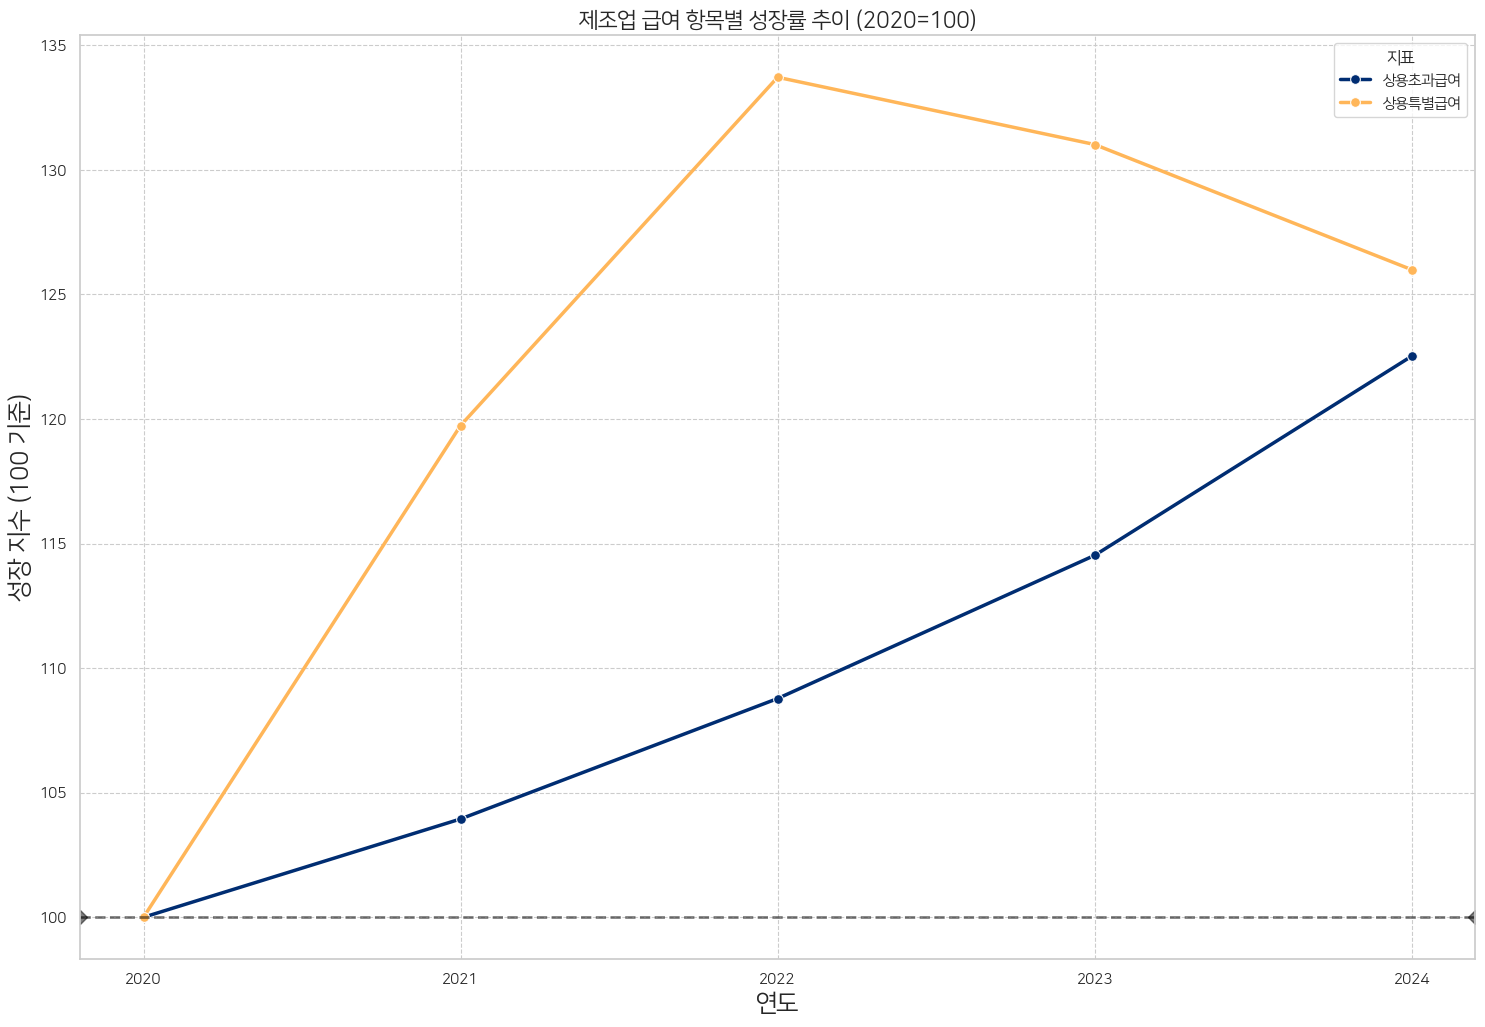

In [81]:
# 1. 2020년 수치를 기준으로 나눈 뒤 100을 곱함
base_2020 = triple_filter[triple_filter['연도'] == 2020].set_index('지표')['비용(만원)']
triple_filter['지수'] = triple_filter.apply(lambda x: (x['비용(만원)'] / base_2020[x['지표']]) * 100, axis=1)

# 2. 지수화된 데이터로 다시 그리기
plt.figure(figsize=(18, 12))
sns.lineplot(data=triple_filter, x='연도', y='지수', hue='지표', marker='o', linewidth=2.5, palette=get_palette(len(jipyo_list)))
plt.axhline(100, color='black', linestyle='--', alpha=0.5) # 기준선
plt.title('제조업 급여 항목별 성장률 추이 (2020=100)', fontsize=16)
plt.xticks([2020, 2021, 2022, 2023, 2024])
plt.ylabel('성장 지수 (100 기준)')
plt.show()

### 전년도 대비 얼마나 증가했는가

In [82]:
jipyo_list = ['상용정액급여', '상용초과급여', '상용특별급여']
triple_filter = manu_money.query('지표 in @jipyo_list').copy()

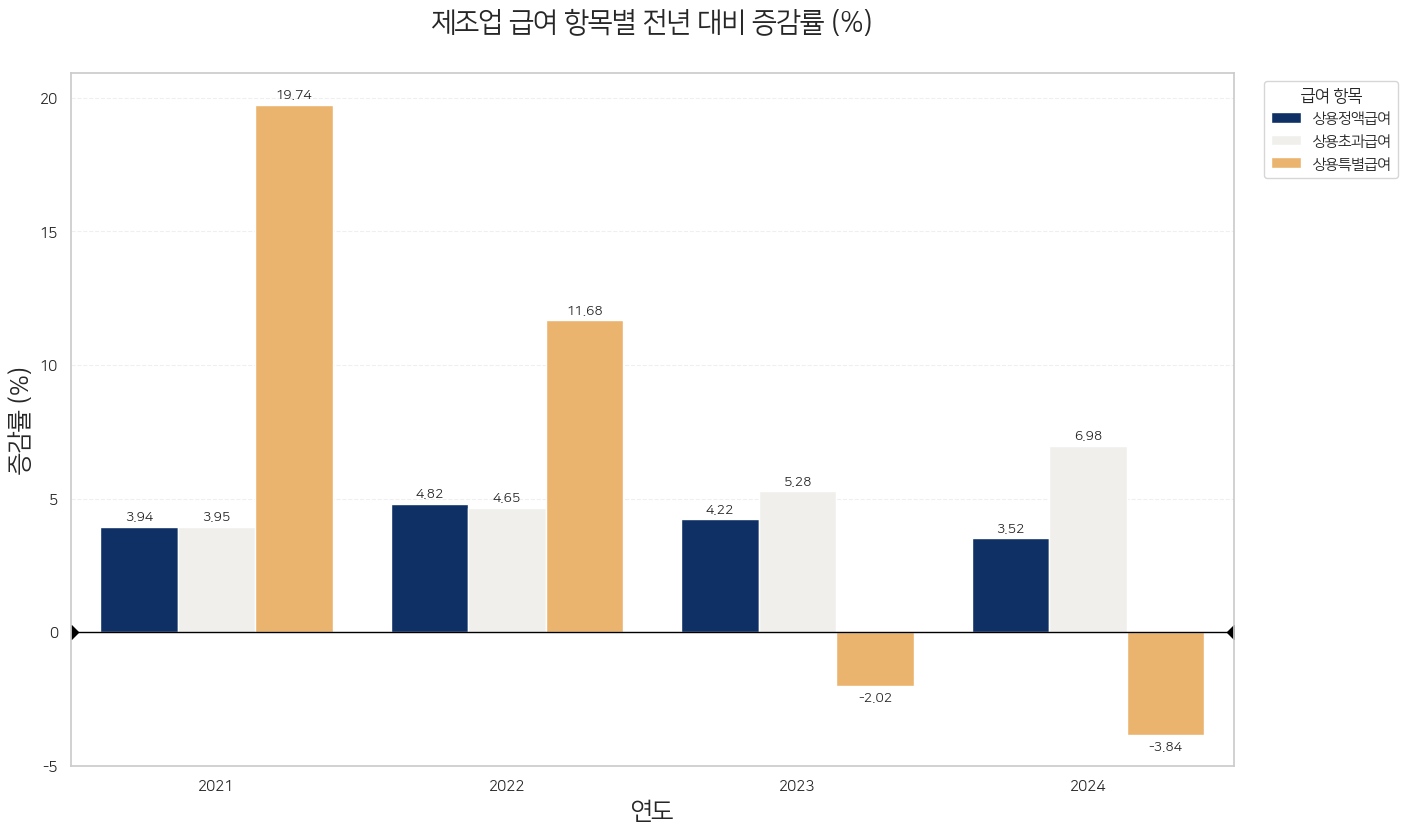

In [83]:
triple_filter['증감률'] = triple_filter.groupby('지표')['비용(만원)'].pct_change() * 100

# 3. 그래프 시각화 (첫 해인 2020년은 데이터가 NaN이므로 2021년부터 표시됨)
plt.figure(figsize=(15, 9))
ax = sns.barplot(data=triple_filter.dropna(), x='연도', y='증감률', hue='지표', palette=get_palette(len(jipyo_list)))

for container in ax.containers:
    # fmt='%d'는 정수로 표시, label_type='edge'는 막대 끝에 표시
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)
# 0% 기준선 (이보다 위면 상승, 아래면 하락)
plt.axhline(0, color='black', linewidth=1)

plt.title('제조업 급여 항목별 전년 대비 증감률 (%)', y=1.05)
plt.ylabel('증감률 (%)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title='급여 항목', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

### 2020년부터 누적 증감률

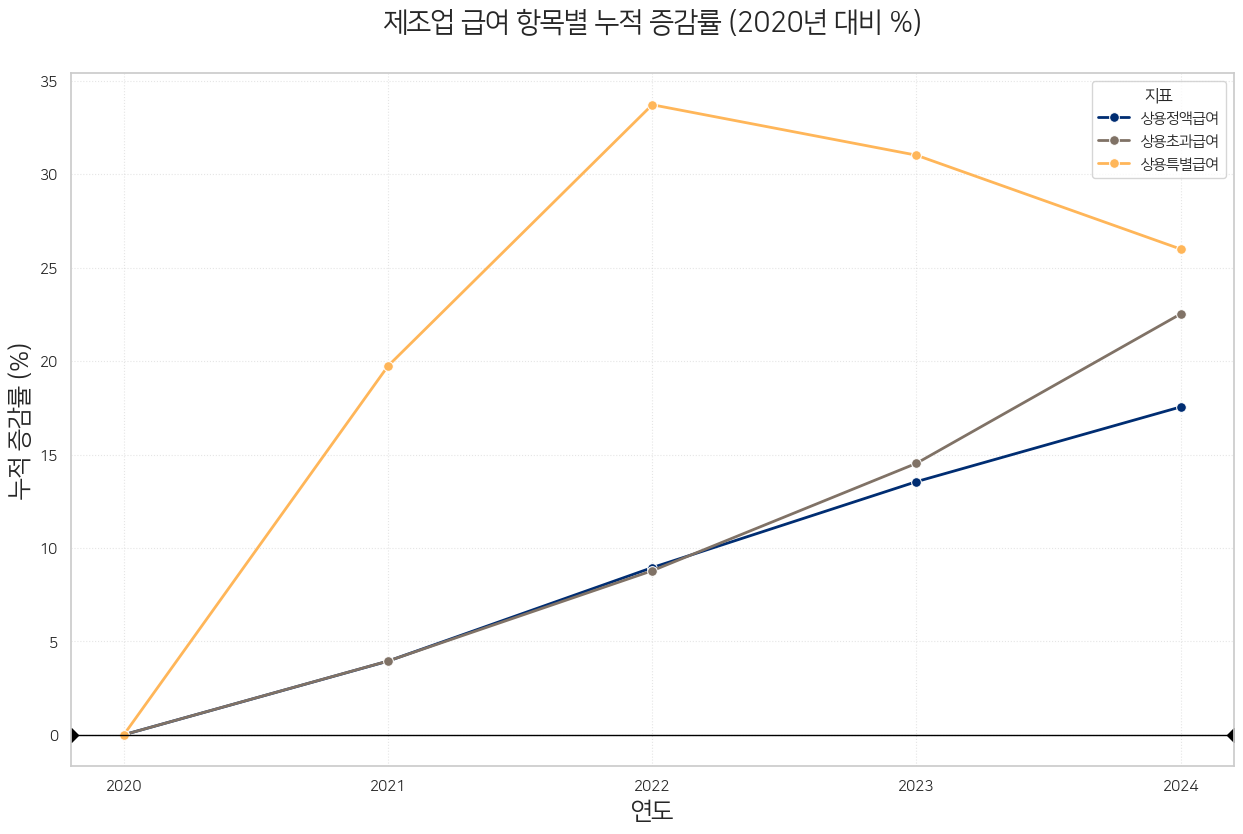

In [84]:
# 2. 2020년 대비 누적 증감률 계산 (%)
base_2020 = triple_filter[triple_filter['연도'] == 2020].set_index('지표')['비용(만원)']
triple_filter['누적증감률'] = triple_filter.apply(lambda x: ((x['비용(만원)'] / base_2020[x['지표']]) - 1) * 100, axis=1)

colors = [custom_cmap_dark(0.0), custom_cmap_dark(0.5), custom_cmap_dark(1.0)]

# 3. 그래프 시각화
plt.figure(figsize=(15, 9))
# 0에서 시작하는 선을 더 잘 보여주기 위해 꺾은선으로 그립니다.
ax = sns.lineplot(data=triple_filter, x='연도', y='누적증감률', hue='지표', marker='o', palette=colors)

# 시작점(2020년 = 0%) 강조
plt.axhline(0, color='black', linewidth=1, linestyle='-')

plt.title('제조업 급여 항목별 누적 증감률 (2020년 대비 %)', y=1.05)
plt.ylabel('누적 증감률 (%)')
plt.xticks([2020, 2021, 2022, 2023, 2024])
plt.grid(axis='both', linestyle=':', alpha=0.5)
plt.show()

# 제조업(허나 최근 10년치)

In [85]:
payment_time_jejo

,산업분류,연도,지표,수치
0,제조업,2015,전체근로일수,21.3
1,제조업,2015,상용근로일수,21.4
2,제조업,2015,임시일용근로일수,17.4
3,제조업,2015,전체근로시간,184.9
4,제조업,2015,상용총근로시간,186.7
...,...,...,...,...
75,제조업,2024,전체근로시간,169.7
76,제조업,2024,상용총근로시간,172.1
77,제조업,2024,상용소정실근로시간,155.2
78,제조업,2024,상용초과근로시간,16.9


In [86]:
payment_money_jejo

,산업분류,연도,지표,비용,비용(만원)
0,제조업,2015,전체임금총액,3462028.0,346.20
1,제조업,2015,상용임금총액,3537204.0,353.72
2,제조업,2015,상용정액급여,2521507.0,252.15
3,제조업,2015,상용초과급여,378569.0,37.86
4,제조업,2015,상용특별급여,637128.0,63.71
5,제조업,2015,임시일용임금총액,1456963.0,145.70
6,제조업,2016,전체임금총액,3602539.0,360.25
7,제조업,2016,상용임금총액,3668846.0,366.88
8,제조업,2016,상용정액급여,2612797.0,261.28
9,제조업,2016,상용초과급여,389325.0,38.93


In [87]:
sangyong_10year = payment_money_jejo.query('지표 == "상용임금총액"')
sangyong_10year

,산업분류,연도,지표,비용,비용(만원)
1,제조업,2015,상용임금총액,3537204.0,353.72
7,제조업,2016,상용임금총액,3668846.0,366.88
13,제조업,2017,상용임금총액,3762582.0,376.26
19,제조업,2018,상용임금총액,4002504.0,400.25
25,제조업,2019,상용임금총액,4094454.0,409.45
31,제조업,2020,상용임금총액,4058423.0,405.84
37,제조업,2021,상용임금총액,4310740.0,431.07
43,제조업,2022,상용임금총액,4565743.0,456.57
49,제조업,2023,상용임금총액,4714235.0,471.42
55,제조업,2024,상용임금총액,4839081.0,483.91


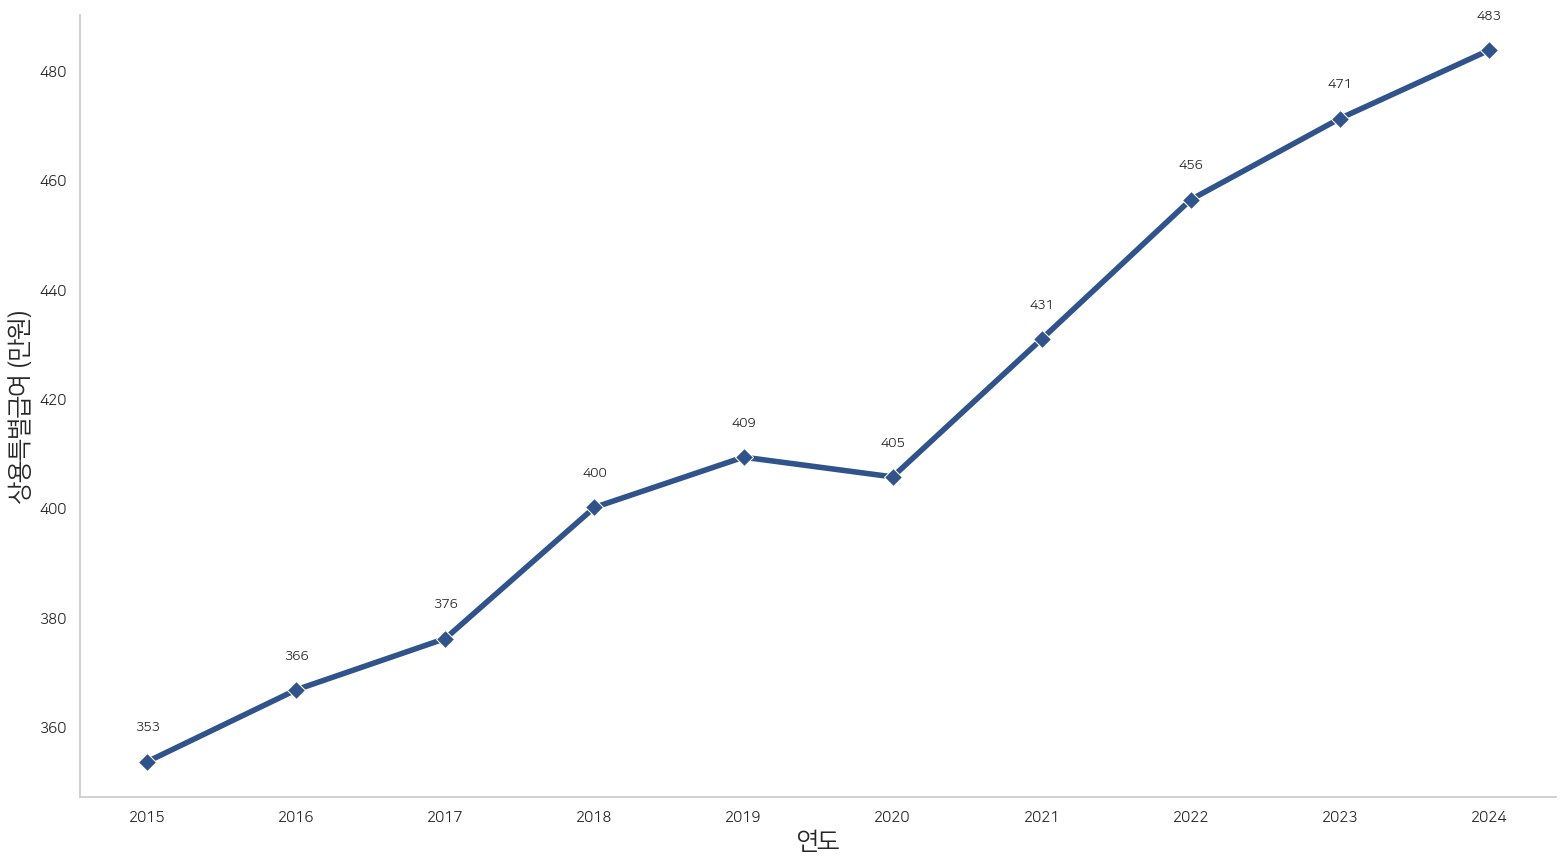

In [96]:
plt.figure(edgecolor='none')
sns.lineplot(sangyong_10year, x = '연도', y = '비용(만원)', color=custom_cmap(0.1), linewidth=4, markersize = 9)
# plt.title('제조업 최근 10개년 상용임금총액 추이', y = 1.01)
plt.xlabel('연도')
plt.ylabel('상용특별급여 (만원)')
plt.grid(False)

for i in range(len(sangyong_10year)):
    # x, y 좌표값 가져오기
    x_val = sangyong_10year['연도'].iloc[i]
    y_val = sangyong_10year['비용(만원)'].iloc[i]

    # plt.text(x좌표, y좌표, 넣을텍스트, 정렬 등)
    plt.text(x_val, y_val + 5, f'{int(y_val):,}',
             ha='center', va='bottom', fontsize=10)

plt.ticklabel_format(axis='y', style='plain')
plt.xticks(list(range(2015, 2025))) # 얘는 왜 이걸 해줘야 년도로 나올까...
sns.despine()
plt.tight_layout()
plt.savefig('제조업 상용임금총액 추이.png', bbox_inches='tight', pad_inches=0)
plt.show()

In [89]:
sangyong_10year = sangyong_10year.reset_index(drop=True)
sangyong_10year['연도'] = sangyong_10year['연도'].astype(int)
print(sangyong_10year['연도'].dtype)  # int 확인

int64


In [90]:
print(sangyong_10year['연도'].unique())
print(len(sangyong_10year))

[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
10


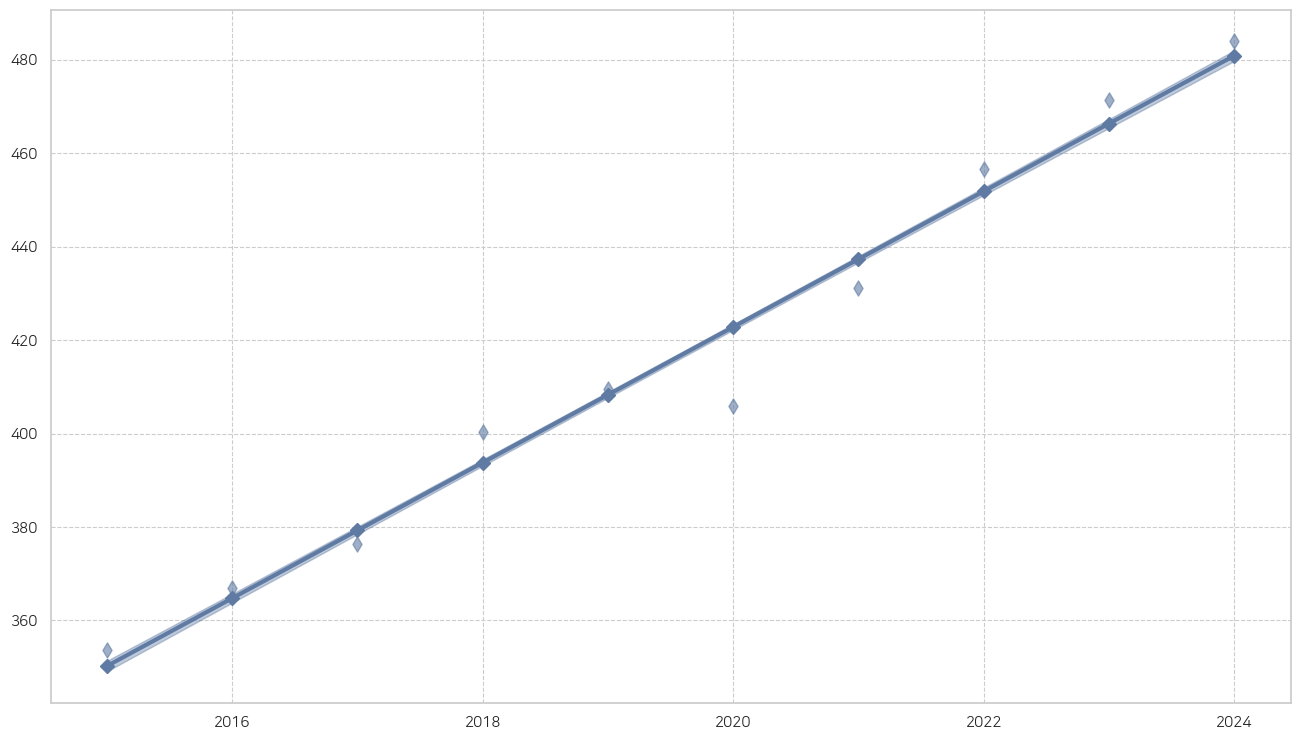

In [91]:
x = sangyong_10year['연도'].values
y = sangyong_10year['비용(만원)'].values

slope, intercept, r, p, se = stats.linregress(x, y)
y_pred = slope * x + intercept

# 신뢰구간
n = len(x)
t = stats.t.ppf(0.975, df=n-2)
ci = t * se * np.sqrt(1/n + (x - x.mean())**2 / np.sum((x - x.mean())**2))

plt.fill_between(x, y_pred - ci, y_pred + ci, alpha=0.4, color=custom_cmap(0.2))
plt.scatter(x, y, marker='d', s=60, alpha=0.6, color=custom_cmap(0.2))
plt.plot(x, y_pred, lw=3, color=custom_cmap(0.2))
plt.show()